## **PROJET:Analyse du Marché Immobilier au Sénégal**



1.   **Objectif**

Scraper les données immobilières de sites d’annonces sénégalais, analyser les prix, tendances,
zones les plus chères, et construire un dashboard interactif avec KPIs.

2.    **Récolte de données**

*   **Recherches de données**

Une partie importante des annonces de locations et de ventes dans le dommaine de l'immobilier passe par les plateformes de ecommerce et les réseaux sociaux.Les plateformes de ecommerce comme Expat-Dakar, CoinAfrique et Jumia Sénégal sont les plus populaires. Pour notre cas nous nous sommes limité à scrapper nos données à partir de Expat Dakar qui se voit être "le plus grand site de petits annonces au Sénégal". La page utilisée pour l’analyse HTML est la page de la catégorie Immobilier accessible via l’URL correspondante :https://www.expat-dakar.com/immobilier. Les annonces immobilières sont réparties sur plusieurs pages à l’aide d’un système de pagination. Le script de web scraping devra donc parcourir plusieurs pages afin de collecter l’ensemble des annonces.
L’analyse de la page Immobilier du site Expat Dakar montre que les annonces sont organisées selon plusieurs catégories telles que les appartements à louer, les maisons à vendre ou les terrains à vendre. La plateforme propose également des filtres géographiques permettant de sélectionner les annonces selon différentes localisations comme Dakar, Thiès ou Saint-Louis. Les annonces sont ensuite affichées sous forme de liste, chaque annonce étant contenue dans un bloc HTML spécifique. Cette organisation facilite l’identification des éléments à extraire lors du processus de web scraping.

**Structure HTML des annonces**

Échantillon analysé
- **Annonce 1** : Appartement à Fann
- **Annonce 2** : Appartement aux Almadies
- **Catégories vérifiées** : Appartements à louer (standard et VIP)
####Conteneur principal d'une annonce
```html
<a href="https://www.expat-dakar.com/annonce/[titre]-[id]"
   class="listing-card__inner"
   id="listing-[id]"
   data-t-listing=""
   data-t-listing_context="search"
   data-t-listing_id="[id]"
   data-t-listing_title="[titre]"
   data-t-listing_type="classified"
   data-t-listing_category_title="[catégorie]"
   data-t-listing_category_slug="[slug]"
   data-t-listing_slug="[slug]"
   data-t-listing_price="[prix]"
   data-t-listing_currency="[devise]"
   data-t-listing_location_title="[localisation]"
   data-t-listing_source="ed_sn">
   
   <!-- Contenu de l'annonce -->
   
</a>



L’analyse du bloc HTML d’une annonce montre que certaines informations sont directement présentes dans les attributs data-* de la balise  **a** comme le prix, la catégorie du bien et la localisation. D’autres informations comme la surface, le nombre de pièces et la date de publication sont contenues dans des balises internes à la carte d’annonce.

Ainsi on peut retenir ce bloc html pour l'affiche de l'ensemble des données demandés
```html
<a class="listing-card__inner"
   data-t-listing_title="[titre]"
   data-t-listing_category_title="[type de bien]"
   data-t-listing_price="[prix]"
   data-t-listing_currency="[devise]"
   data-t-listing_location_title="[quartier, ville]">

   <div class="listing-card__header__title">
      [titre de l'annonce]
   </div>

   <span class="listing-card__header__tags__item--square-metres">
      [surface]
   </span>

   <span class="listing-card__header__tags__item--no-of-bedrooms">
      [nombre de pièces]
   </span>

   <div class="listing-card__header__date">
      [date de publication]
   </div>

</a>

Exemple d’une annonce analysée

Exemple d’annonce observée :

- **Titre :** Appartement neuf à Fann Résidence  
- **Prix :** 1 700 000 F CFA  
- **Localisation :** Fann, Dakar  
- **Surface :** 180 m²  
- **Nombre de chambres :** 3  
- **Date de publication :** publiée il y a quelques jours  

Ces informations sont intégrées dans le code HTML à l’intérieur du bloc `listing-card__inner`.

L’analyse de la structure HTML du site Expat Dakar a permis d’identifier les éléments contenant les informations nécessaires pour le web scraping des annonces immobilières.

Les principales données demandées dans le projet (ville, quartier, type de bien, prix, surface, nombre de pièces et date de publication) sont présentes dans les annonces et peuvent être extraites grâce aux classes HTML identifiées.

Cette étape constitue une base importante pour la suite du projet, notamment la création du script de web scraping permettant de collecter automatiquement les données.

#### **Vérification du fichier robots.txt**
Le fichier robots.txt est un fichier présent sur la plupart des sites web.
Il indique aux robots (bots, scrapers, moteurs de recherche) quelles parties du site peuvent être explorées ou non.

Il sert donc à dire :

quelles pages sont autorisées

quelles pages sont interdites
### **Méthode**

Le fichier robots.txt du site a été consulté en accédant à l’adresse suivante :

https://www.expat-dakar.com/robots.txt

Ce fichier permet de définir les parties du site accessibles ou interdites aux robots d’indexation et aux outils de scraping.

Si le fichier existe : Tu verras du texte avec des règles

Si le fichier n'existe pas : Erreur 404 (page non trouvée)

Si accès interdit : Erreur 403 (accès refusé)

User-agent: *

Disallow: /cdn-cgi/

Disallow: /admin/*

Disallow: /compte/*

Allow: /compte/login

User-agent: Twitterbot
Allow: *

User-agent: MegaIndex.ru
Disallow: /

User-agent: megaindex.com
Disallow: /

User-agent: MauiBot
Disallow: /

User-agent: SemrushBot
Disallow: /

Sitemap: https://www.expat-dakar.com/sitemap-category-fr.xml
Sitemap: https://www.expat-dakar.com/sitemap-directory-category-fr.xml
Sitemap: https://www.expat-dakar.com/sitemap-directory-fr.xml
Sitemap: https://www.expat-dakar.com/sitemap-listings-index-fr.xml
Sitemap: https://www.expat-dakar.com/sitemap-static-fr.xml
Sitemap: https://www.expat-dakar.com/decouvrir/sitemap_index.xml

User-agent: *

Disallow: /cdn-cgi/

Disallow: /admin/*

Disallow: /compte/*

Allow: /compte/login

Ces règles indiquent que les robots ne peuvent pas accéder aux pages administratives et aux pages de gestion des comptes. Cependant, les pages publiques du site ne sont pas bloquées.

Le fichier robots.txt mentionne également plusieurs sitemaps permettant de lister les pages importantes du site.

## Conclusion

L’analyse du fichier robots.txt montre que les pages publiques du site, notamment les annonces immobilières, peuvent être explorées par des robots. Les restrictions concernent uniquement les sections administratives et les comptes utilisateurs. **Par conséquent, la collecte des données immobilières peut être réalisée en respectant ces règles**.

Créer un **document de mapping (champs à extraire)** consiste simplement à faire un tableau qui relie :



*   les données demandées dans le projet
*   leur emplacement dans le HTML
*   la méthode pour les récupérer

Le document de mapping permet d’identifier les emplacements exacts des données à extraire dans la structure HTML du site Expat Dakar. Chaque champ demandé dans le projet est associé à une balise HTML ou à une classe CSS spécifique. Ce mapping servira de référence pour le développement du script de web scraping.

### Données à extraire

Les données suivantes doivent être collectées :

- Ville
- Quartier
- Type de bien
- Prix
- Surface
- Nombre de pièces
- Date de publication

## Tableau de mapping

| Champ à extraire | Emplacement HTML | Classe / attribut | Type de donnée | Exemple | Règle d'extraction |
|---|---|---|---|---|---|
| Ville | localisation | data-t-listing_location_title | Texte | Dakar | extraire après la virgule |
| Quartier | localisation | data-t-listing_location_title | Texte | Fann | extraire avant la virgule |
| Type de bien | attribut | data-t-listing_category_title | Texte | Appartement | extraction directe |
| Prix | attribut | data-t-listing_price | Nombre | 1700000 | extraction directe |
| Surface | balise span | listing-card__header__tags__item--square-metres | Nombre | 180 m² | extraire uniquement les chiffres |
| Nombre de pièces | balise span | listing-card__header__tags__item--no-of-bedrooms | Nombre | 3 chambres | extraire uniquement les chiffres |
| Date de publication | balise div | listing-card__header__date | Texte | publié il y a 2 jours | extraction directe |

## Remarque

Certaines informations comme la ville et le quartier sont contenues dans une seule chaîne de caractères sous la forme :

Fann, Dakar

Il est donc nécessaire de séparer cette chaîne en deux parties :
- la partie avant la virgule correspond au **quartier**
- la partie après la virgule correspond à la **ville**

Ce document de mapping permet d’associer chaque champ à extraire avec son emplacement dans le code HTML du site Expat Dakar.  
Il facilite l’implémentation du script de web scraping en indiquant clairement les classes HTML ou attributs à utiliser pour récupérer les données immobilières.

### **Installation des outils (Scrapy, BeautifulSoup, Selenium)**

In [16]:
# Installation des 3 outils principaux
!pip install beautifulsoup4
!pip install scrapy
!pip install selenium

# Outils complémentaires utiles
!pip install requests
!pip install lxml
!pip install pandas

print("✅ Installation terminée!")

# Vérification
print("\n Vérification des versions:")
import bs4
print(f"BeautifulSoup: {bs4.__version__}")
import scrapy
print(f"Scrapy: {scrapy.__version__}")
import selenium
print(f"Selenium: {selenium.__version__}")

✅ Installation terminée!

 Vérification des versions:
BeautifulSoup: 4.12.3
Scrapy: 2.11.1
Selenium: 4.41.0


**Création du spider pour Expat-Dakar (structure de base)**

Le spider commence par accéder à la page liste des annonces immobilières du site. Cette page contient plusieurs annonces affichées sous forme de blocs. À partir de cette page, le spider identifie et récupère les liens de chaque annonce disponible. Ensuite, il visite individuellement chaque page d’annonce afin d’accéder aux informations détaillées du bien immobilier. Enfin, il extrait les données importantes comme  la ville, le prix, le quartier, type de bien, la surface, le nombre de chambres et la date de publication, puis les enregistre dans un dataset qui pourra être utilisé pour l’analyse du marché immobilier et la création d’un dashboard.

# ============================================
## TÂCHES GORA DIALLO
# Extraire la liste des annonces depuis Expat-Dakar
# Gérer la pagination (jusqu'à 440 pages)
# Extraire les détails de chaque annonce (prix, surface, pièces, etc.)
# ============================================

In [17]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import json
import re
import time
from datetime import datetime

print("="*60)
print("SCRAPING EXPAT-DAKAR via JSON-LD")
print("="*60)

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36',
    'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
    'Accept-Language': 'fr-FR,fr;q=0.9',
}

def extraire_annonces_page(page_num):
    """Extrait les annonces depuis le JSON-LD de la page"""
    
    if page_num == 1:
        url = "https://www.expat-dakar.com/immobilier"
    else:
        url = f"https://www.expat-dakar.com/immobilier?page={page_num}"
    
    print(f"\n📌 Page {page_num} - {url}")
    
    try:
        response = requests.get(url, headers=headers, timeout=15)
        print(f"   Statut: {response.status_code}")
        
        if response.status_code != 200:
            return []
        
        soup = BeautifulSoup(response.text, 'html.parser')
        
        # ✅ NOUVELLE MÉTHODE: Extraire le JSON-LD
        script_tag = soup.find('script', type='application/ld+json')
        if not script_tag:
            print("   ❌ Pas de JSON-LD trouvé")
            return []
        
        data_json = json.loads(script_tag.string)
        
        # Naviguer dans le graphe JSON
        graph = data_json.get('@graph', [])
        
        # Trouver la WebPage qui contient les annonces
        items = []
        for node in graph:
            if node.get('@type') == 'WebPage':
                main_entity = node.get('mainEntity', {})
                items = main_entity.get('itemListElement', [])
                break
        
        print(f"   ✅ Annonces trouvées: {len(items)}")
        
        annonces = []
        for item in items:
            try:
                product = item.get('item', {})
                offer = product.get('offers', {})
                price_spec = offer.get('priceSpecification', {})
                
                # Extraction des champs
                titre = product.get('name', '')
                url_annonce = product.get('url', '')
                description = product.get('description', '')
                categorie = product.get('category', '').strip()
                
                # Prix
                prix = price_spec.get('price', None)
                devise = price_spec.get('priceCurrency', 'XOF')
                
                # Date de publication
                date_pub = offer.get('validFrom', '')
                
                # Image
                image = product.get('image', {})
                image_url = image.get('url', '') if isinstance(image, dict) else ''
                
                # ID de l'annonce (depuis l'URL)
                id_annonce = re.search(r'-(\d+)$', url_annonce)
                id_annonce = id_annonce.group(1) if id_annonce else ''
                
                # Extraction localisation depuis le titre/description
                # (le JSON-LD ne donne pas quartier séparé)
                
                annonces.append({
                    'id': id_annonce,
                    'titre': titre,
                    'categorie': categorie,
                    'prix_xof': prix,
                    'description': description[:200] + '...' if len(description) > 200 else description,
                    'date_publication': date_pub,
                    'url': url_annonce,
                    'image_url': image_url,
                    'page': page_num,
                    'date_scraping': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
                })
                
            except Exception as e:
                print(f"   ⚠️ Erreur annonce: {e}")
                continue
        
        return annonces
    
    except Exception as e:
        print(f"   ❌ Erreur: {e}")
        return []

# ============================================
# SCRAPING AVEC PAGINATION
# ============================================

toutes_annonces = []
pages_a_scraper = 3  # Changer à 440 pour le scraping complet

print(f"\n🚀 Scraping de {pages_a_scraper} pages...")

for page in range(1, pages_a_scraper + 1):
    annonces = extraire_annonces_page(page)
    toutes_annonces.extend(annonces)
    print(f"   📊 Total cumulé: {len(toutes_annonces)} annonces")
    
    if page < pages_a_scraper:
        time.sleep(2)  # Pause respectueuse

# ============================================
# RÉSULTATS ET SAUVEGARDE
# ============================================

print("\n" + "="*60)
print("📊 RÉSULTATS")
print("="*60)

if toutes_annonces:
    df = pd.DataFrame(toutes_annonces)
    
    print(f"\n✅ {len(df)} annonces extraites sur {pages_a_scraper} pages")
    
    print("\n📋 Aperçu:")
    print(df[['titre', 'prix_xof', 'categorie', 'date_publication']].head(10).to_string())
    
    print("\n📈 Statistiques:")
    print(f"  Prix moyen    : {df['prix_xof'].mean():,.0f} XOF")
    print(f"  Prix médian   : {df['prix_xof'].median():,.0f} XOF")
    print(f"  Prix min      : {df['prix_xof'].min():,.0f} XOF")
    print(f"  Prix max      : {df['prix_xof'].max():,.0f} XOF")
    print(f"  Catégories    : {df['categorie'].unique().tolist()}")
    
    # Sauvegarde CSV
    fichier = f'expat_dakar_{pages_a_scraper}pages.csv'
    df.to_csv(fichier, index=False, encoding='utf-8-sig')
    print(f"\n💾 Sauvegardé: {fichier}")
    
else:
    print("❌ Aucune donnée extraite")

SCRAPING EXPAT-DAKAR via JSON-LD

🚀 Scraping de 3 pages...

📌 Page 1 - https://www.expat-dakar.com/immobilier
   Statut: 200
   ✅ Annonces trouvées: 10
   📊 Total cumulé: 10 annonces

📌 Page 2 - https://www.expat-dakar.com/immobilier?page=2
   Statut: 200
   ✅ Annonces trouvées: 10
   📊 Total cumulé: 20 annonces

📌 Page 3 - https://www.expat-dakar.com/immobilier?page=3
   Statut: 200
   ✅ Annonces trouvées: 10
   📊 Total cumulé: 30 annonces

📊 RÉSULTATS

✅ 30 annonces extraites sur 3 pages

📋 Aperçu:
                                                     titre   prix_xof              categorie     date_publication
0  Appartements VEFA aux Almadies |Résidences Blue & Green  316200000  Appartements à vendre  2026-03-09 12:41:24
1               STUDIO A LOUER DIEUPEUL À COTÉ DE MARMITON     200000   Appartements à louer  2026-03-12 14:02:54
2                    VILLA R+1 à louer MERMOZ CITÉ BATRAIN     800000        Maisons à louer  2025-11-19 15:34:51
3    Somptueux Appartement F4 à vendre

In [18]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import json
import re
import time
import os
from datetime import datetime

print("="*65)
print("  MEMBRE 1 — SCRAPING EXPAT-DAKAR (DONNÉES BRUTES)")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# ============================================================
# CONFIGURATION
# ============================================================
BASE_URL       = "https://www.expat-dakar.com/immobilier"
NB_PAGES       = 440
PAUSE_SECONDES = 2
BACKUP_TOUTES  = 50
FICHIER_BRUT   = "expat_dakar_brut.csv"        # ← Membre 2 lira ce fichier
DOSSIER_BACKUP = "backups_membre1"

HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/120.0.0.0 Safari/537.36'
    ),
    'Accept'         : 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
    'Accept-Language': 'fr-FR,fr;q=0.9,en;q=0.8',
}

os.makedirs(DOSSIER_BACKUP, exist_ok=True)

# ============================================================
# TÂCHE 1 — Extraire la liste des annonces d'une page
# ============================================================
def extraire_annonces_page(page_num: int) -> list:
    """
    TÂCHE 1 : Extraction de la liste des annonces via JSON-LD
    TÂCHE 2 : Pagination gérée par l'appelant
    TÂCHE 3 : Extraction des détails bruts (prix, surface, pièces)
    """
    url = BASE_URL if page_num == 1 else f"{BASE_URL}?page={page_num}"

    try:
        response = requests.get(url, headers=HEADERS, timeout=15)

        if response.status_code != 200:
            print(f"  ⚠️  HTTP {response.status_code} — page {page_num}")
            return []

        soup = BeautifulSoup(response.text, 'html.parser')

        # Les données sont dans le bloc JSON-LD (pas dans le HTML visible)
        script_tag = soup.find('script', type='application/ld+json')
        if not script_tag:
            return []

        data_json = json.loads(script_tag.string)
        graph     = data_json.get('@graph', [])

        # Trouver le nœud WebPage qui contient la liste d'annonces
        items = []
        for node in graph:
            if node.get('@type') == 'WebPage':
                items = node.get('mainEntity', {}).get('itemListElement', [])
                break

        if not items:
            return []

        # ----------------------------------------------------------
        # TÂCHE 3 — Extraire les détails de chaque annonce
        # ----------------------------------------------------------
        annonces = []
        for item in items:
            try:
                product    = item.get('item', {})
                offer      = product.get('offers', {})
                price_spec = offer.get('priceSpecification', {})
                image_obj  = product.get('image', {})

                # Titre
                titre = product.get('name', '').strip()

                # URL de l'annonce
                url_annonce = product.get('url', '')

                # Description complète (brute, sera traitée par Membre 2)
                description = product.get('description', '')

                # Catégorie (ex: "Appartements à louer")
                categorie = product.get('category', '').strip()

                # Prix en XOF
                prix   = price_spec.get('price', None)
                devise = price_spec.get('priceCurrency', 'XOF')

                # Date de publication (brute, sera formatée par Membre 2)
                date_pub = offer.get('validFrom', '')

                # Image
                image_url = (image_obj.get('url', '')
                             if isinstance(image_obj, dict) else '')

                # ID unique de l'annonce
                m_id       = re.search(r'-(\d+)$', url_annonce)
                id_annonce = m_id.group(1) if m_id else ''

                # Type d'opération (Vente / Location)
                cat_lower = categorie.lower()
                if 'vendre' in cat_lower or 'vente' in cat_lower:
                    type_operation = 'Vente'
                elif 'louer' in cat_lower or 'location' in cat_lower:
                    type_operation = 'Location'
                elif 'meublé' in cat_lower or 'meuble' in cat_lower:
                    type_operation = 'Location meublée'
                else:
                    type_operation = 'Autre'

                annonces.append({
                    'id'             : id_annonce,
                    'titre'          : titre,
                    'categorie'      : categorie,
                    'type_operation' : type_operation,
                    'prix_xof'       : prix,
                    'devise'         : devise,
                    'description'    : description,   # ← Membre 2 parsera ceci
                    'date_pub_brute' : date_pub,       # ← Membre 2 formatera ceci
                    'url'            : url_annonce,
                    'image_url'      : image_url,
                    'page_source'    : page_num,
                    'date_scraping'  : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
                })

            except Exception:
                continue

        return annonces

    except requests.exceptions.Timeout:
        print(f"  ⏱️  Timeout page {page_num} — on continue")
        return []
    except Exception as e:
        print(f"  ❌ Erreur page {page_num}: {e}")
        return []


# ============================================================
# TÂCHE 2 — Pagination complète (440 pages)
# ============================================================
toutes_annonces = []
pages_vides     = 0
MAX_PAGES_VIDES = 5

print(f"\n🚀 Lancement du scraping ({NB_PAGES} pages)\n")

for page in range(1, NB_PAGES + 1):

    annonces_page = extraire_annonces_page(page)
    nb            = len(annonces_page)

    if nb == 0:
        pages_vides += 1
        print(f"  Page {page:>3} | 0 annonces (vide #{pages_vides})")
        if pages_vides >= MAX_PAGES_VIDES:
            print(f"\n⛔ {MAX_PAGES_VIDES} pages vides → fin détectée.")
            break
    else:
        pages_vides = 0
        toutes_annonces.extend(annonces_page)
        print(f"  Page {page:>3} | ✅ {nb:>2} annonces | Total: {len(toutes_annonces):>5}")

    # Backup automatique
    if page % BACKUP_TOUTES == 0 and toutes_annonces:
        backup_file = os.path.join(DOSSIER_BACKUP, f"backup_p{page:04d}.csv")
        pd.DataFrame(toutes_annonces).to_csv(backup_file, index=False, encoding='utf-8-sig')
        print(f"  💾 Backup → {backup_file}")

    if page < NB_PAGES:
        time.sleep(PAUSE_SECONDES)


# ============================================================
# SAUVEGARDE FINALE (fichier brut pour Membre 2)
# ============================================================
print("\n" + "="*65)
print("  📊 RÉSULTATS MEMBRE 1")
print("="*65)

if toutes_annonces:
    df = pd.DataFrame(toutes_annonces)

    # Déduplication
    avant = len(df)
    df    = df.drop_duplicates(subset='id', keep='first')

    print(f"\n✅ Annonces extraites  : {avant}")
    print(f"✅ Après déduplication : {len(df)}")
    print(f"\n  Catégories trouvées :")
    for cat, nb in df['categorie'].value_counts().items():
        print(f"    {cat:<40} {nb:>5}")

    print(f"\n  PRIX (XOF) — aperçu brut :")
    print(f"    Moyenne  : {df['prix_xof'].mean():>15,.0f}")
    print(f"    Médiane  : {df['prix_xof'].median():>15,.0f}")
    print(f"    Min      : {df['prix_xof'].min():>15,.0f}")
    print(f"    Max      : {df['prix_xof'].max():>15,.0f}")

    # Sauvegarder en CSV brut (sans traitement localisation/surface)
    df.to_csv(FICHIER_BRUT, index=False, encoding='utf-8-sig')
    taille = os.path.getsize(FICHIER_BRUT)

    print(f"\n💾 Fichier brut sauvegardé : {FICHIER_BRUT}")
    print(f"   Lignes     : {len(df)}")
    print(f"   Colonnes   : {list(df.columns)}")
    print(f"   Taille     : {taille/1024:.1f} Ko")

else:
    print("❌ Aucune donnée extraite.")

print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

  MEMBRE 1 — SCRAPING EXPAT-DAKAR (DONNÉES BRUTES)
  Démarrage: 2026-03-12 23:36:33

🚀 Lancement du scraping (440 pages)

  Page   1 | ✅ 10 annonces | Total:    10
  Page   2 | ✅ 10 annonces | Total:    20
  Page   3 | ✅ 10 annonces | Total:    30
  Page   4 | ✅ 10 annonces | Total:    40
  Page   5 | ✅ 10 annonces | Total:    50
  Page   6 | ✅ 10 annonces | Total:    60
  Page   7 | ✅ 10 annonces | Total:    70
  Page   8 | ✅ 10 annonces | Total:    80
  Page   9 | ✅ 10 annonces | Total:    90
  Page  10 | ✅ 10 annonces | Total:   100
  Page  11 | ✅ 10 annonces | Total:   110
  Page  12 | ✅ 10 annonces | Total:   120
  Page  13 | ✅ 10 annonces | Total:   130
  Page  14 | ✅ 10 annonces | Total:   140
  Page  15 | ✅ 10 annonces | Total:   150
  Page  16 | ✅ 10 annonces | Total:   160
  Page  17 | ✅ 10 annonces | Total:   170
  Page  18 | ✅ 10 annonces | Total:   180
  Page  19 | ✅ 10 annonces | Total:   190
  Page  20 | ✅ 10 annonces | Total:   200
  Page  21 | ✅ 10 annonces | Total:   

## TACHES DIEYNABA BA

In [19]:
import pandas as pd
import re
from datetime import datetime

print("="*65)
print("  MEMBRE 2 — EXTRACTION LOCALISATION / SURFACE / PIÈCES / DATE")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# ============================================================
# CHARGEMENT DU FICHIER BRUT (produit par Membre 1)
# ============================================================
FICHIER_ENTREE = "expat_dakar_brut.csv"       # ← produit par Membre 1
FICHIER_SORTIE = "expat_dakar_enrichi.csv"    # ← fichier final enrichi

print(f"\n📂 Chargement de : {FICHIER_ENTREE}")
df = pd.read_csv(FICHIER_ENTREE, encoding='utf-8-sig')
print(f"✅ {len(df)} annonces chargées — {len(df.columns)} colonnes")


# ============================================================
# TÂCHE A — Extraire la LOCALISATION (ville et quartier)
# ============================================================
QUARTIERS_DAKAR = [
    # Presqu'île de Dakar
    'almadies', 'ngor', 'ouakam', 'yoff', 'mermoz', 'sacré-coeur',
    'sacre coeur', 'fann', 'point e', 'liberté 6', 'liberté 5',
    'liberté 4', 'liberté 3', 'liberté 2', 'liberté 1', 'liberté',
    'liberte', 'médina', 'medina', 'plateau', 'hlm', 'grand dakar',
    'nord foire', 'maristes', 'baobabs', 'sicap', 'dieuppeul',
    'mamelles', 'corniche', 'vdn', 'cité keur gorgui', 'keur gorgui',
    'amitié', 'amitie', 'foire', 'cambérène', 'camberene',
    'pikine', 'guédiawaye', 'guediawaye', 'parcelles assainies',
    'mbao', 'thiaroye', 'yeumbeul',
    # Banlieue / périphérie
    'rufisque', 'sébikotane', 'sebikotane', 'diamniadio',
    'lac rose', 'keur massar',
    # Autres villes du Sénégal
    'saly', 'mbour', 'somone', 'popenguine',
    'thiès', 'thies', 'saint-louis', 'ziguinchor', 'touba',
    'kaolack', 'tambacounda',
    # Générique (en dernier pour ne pas court-circuiter les précédents)
    'dakar',
]

VILLES_SENEGAL = {
    'almadies': 'Dakar', 'ngor': 'Dakar', 'ouakam': 'Dakar',
    'yoff': 'Dakar', 'mermoz': 'Dakar', 'sacré-coeur': 'Dakar',
    'sacre coeur': 'Dakar', 'fann': 'Dakar', 'point e': 'Dakar',
    'liberté': 'Dakar', 'liberte': 'Dakar', 'médina': 'Dakar',
    'medina': 'Dakar', 'plateau': 'Dakar', 'hlm': 'Dakar',
    'grand dakar': 'Dakar', 'nord foire': 'Dakar', 'maristes': 'Dakar',
    'baobabs': 'Dakar', 'sicap': 'Dakar', 'dieuppeul': 'Dakar',
    'mamelles': 'Dakar', 'corniche': 'Dakar', 'vdn': 'Dakar',
    'cité keur gorgui': 'Dakar', 'keur gorgui': 'Dakar',
    'foire': 'Dakar', 'cambérène': 'Dakar', 'camberene': 'Dakar',
    'pikine': 'Pikine', 'guédiawaye': 'Guédiawaye',
    'guediawaye': 'Guédiawaye', 'parcelles assainies': 'Dakar',
    'mbao': 'Pikine', 'thiaroye': 'Pikine', 'yeumbeul': 'Pikine',
    'rufisque': 'Rufisque', 'sébikotane': 'Rufisque',
    'sebikotane': 'Rufisque', 'diamniadio': 'Diamniadio',
    'lac rose': 'Rufisque', 'keur massar': 'Dakar',
    'saly': 'Mbour', 'mbour': 'Mbour', 'somone': 'Mbour',
    'popenguine': 'Mbour',
    'thiès': 'Thiès', 'thies': 'Thiès',
    'saint-louis': 'Saint-Louis',
    'ziguinchor': 'Ziguinchor',
    'touba': 'Touba', 'kaolack': 'Kaolack',
    'tambacounda': 'Tambacounda',
    'dakar': 'Dakar',
}

def extraire_localisation(titre: str, description: str) -> dict:
    """
    TÂCHE A : Extrait quartier et ville depuis titre + description.
    Parcourt la liste du plus précis au plus général.
    """
    texte = f"{str(titre)} {str(description)}".lower()
    # Nettoyer accents pour matching robuste
    texte_norm = (texte
                  .replace('é', 'e').replace('è', 'e').replace('ê', 'e')
                  .replace('à', 'a').replace('â', 'a')
                  .replace('î', 'i').replace('ô', 'o').replace('û', 'u'))

    for q in QUARTIERS_DAKAR:
        q_norm = (q.replace('é', 'e').replace('è', 'e').replace('ê', 'e')
                   .replace('à', 'a').replace('â', 'a')
                   .replace('î', 'i').replace('ô', 'o').replace('û', 'u'))
        if q_norm in texte_norm:
            ville = VILLES_SENEGAL.get(q, 'Dakar')
            return {'quartier': q.title(), 'ville': ville}

    return {'quartier': None, 'ville': None}


# ============================================================
# TÂCHE B — Extraire la SURFACE en m²
# ============================================================
def extraire_surface(description: str, titre: str) -> int | None:
    """
    TÂCHE B : Extrait la surface depuis la description ou le titre.
    Gère : '120 m²', '120m2', '120 metres carrés', etc.
    """
    texte = f"{str(titre)} {str(description)}".lower()

    patterns = [
        r'(\d+)\s*m[²2]',
        r'(\d+)\s*m\s*carre',
        r'(\d+)\s*metres?\s*carre',
        r'superficie\s*[:\-]?\s*(\d+)',
        r'surface\s*[:\-]?\s*(\d+)',
    ]
    for pat in patterns:
        m = re.search(pat, texte)
        if m:
            val = int(m.group(1))
            # Filtrer les valeurs aberrantes (surface entre 5 et 50000 m²)
            if 5 <= val <= 50000:
                return val
    return None


# ============================================================
# TÂCHE C — Extraire le NOMBRE DE PIÈCES / CHAMBRES
# ============================================================
def extraire_pieces(description: str, titre: str) -> dict:
    """
    TÂCHE C : Extrait nb_chambres, nb_salons, nb_sdb depuis description.
    """
    texte = f"{str(titre)} {str(description)}".lower()

    # Chambres
    nb_chambres = None
    for pat in [
        r'(\d+)\s*chambre',
        r'f(\d+)',          # F3, F4, etc.
        r't(\d+)',          # T3, T4, etc.
    ]:
        m = re.search(pat, texte)
        if m:
            nb_chambres = int(m.group(1))
            # F4 = 3 chambres + salon (approximation)
            if 'f' in pat or 't' in pat:
                nb_chambres = max(1, nb_chambres - 1)
            break

    # Salons
    nb_salons = None
    m = re.search(r'(\d+)\s*salon', texte)
    if m:
        nb_salons = int(m.group(1))
    elif 'salon' in texte:
        nb_salons = 1

    # Salles de bain / salle d'eau
    nb_sdb = None
    m = re.search(r'(\d+)\s*salle[s]?\s*(de\s*bain|d.eau)', texte)
    if m:
        nb_sdb = int(m.group(1))
    elif re.search(r'salle\s*(de\s*bain|d.eau)', texte):
        nb_sdb = 1

    return {
        'nb_chambres': nb_chambres,
        'nb_salons'  : nb_salons,
        'nb_sdb'     : nb_sdb,
    }


# ============================================================
# TÂCHE D — Formater la DATE DE PUBLICATION
# ============================================================
def formater_date(date_brute: str) -> dict:
    """
    TÂCHE D : Transforme '2026-03-09 12:41:24' en colonnes utiles.
    Retourne : date_propre, annee, mois, jour, heure
    """
    if not date_brute or pd.isna(date_brute):
        return {
            'date_publication': None,
            'annee': None, 'mois': None,
            'jour': None,  'heure': None,
        }
    try:
        dt = datetime.strptime(str(date_brute), '%Y-%m-%d %H:%M:%S')
        return {
            'date_publication': dt.strftime('%d/%m/%Y'),
            'annee': dt.year,
            'mois' : dt.month,
            'jour' : dt.day,
            'heure': dt.strftime('%H:%M'),
        }
    except Exception:
        return {
            'date_publication': str(date_brute),
            'annee': None, 'mois': None,
            'jour': None,  'heure': None,
        }


# ============================================================
# APPLICATION SUR TOUT LE DATAFRAME
# ============================================================
print("\n⚙️  Traitement en cours...\n")

resultats_loc    = []
resultats_surf   = []
resultats_pieces = []
resultats_dates  = []

for i, row in df.iterrows():
    titre = str(row.get('titre', ''))
    desc  = str(row.get('description', ''))
    date  = row.get('date_pub_brute', '')

    # TÂCHE A — Localisation
    loc = extraire_localisation(titre, desc)
    resultats_loc.append(loc)

    # TÂCHE B — Surface
    surf = extraire_surface(desc, titre)
    resultats_surf.append(surf)

    # TÂCHE C — Pièces
    pieces = extraire_pieces(desc, titre)
    resultats_pieces.append(pieces)

    # TÂCHE D — Date
    date_fmt = formater_date(date)
    resultats_dates.append(date_fmt)

    if (i + 1) % 500 == 0:
        print(f"  ... {i+1}/{len(df)} annonces traitées")

print(f"  ✅ {len(df)} annonces traitées\n")

# Intégration dans le DataFrame
df['quartier']         = [r['quartier'] for r in resultats_loc]
df['ville']            = [r['ville']    for r in resultats_loc]
df['surface_m2']       = resultats_surf
df['nb_chambres']      = [r['nb_chambres'] for r in resultats_pieces]
df['nb_salons']        = [r['nb_salons']   for r in resultats_pieces]
df['nb_sdb']           = [r['nb_sdb']      for r in resultats_pieces]
df['date_publication'] = [r['date_publication'] for r in resultats_dates]
df['annee_pub']        = [r['annee'] for r in resultats_dates]
df['mois_pub']         = [r['mois']  for r in resultats_dates]
df['jour_pub']         = [r['jour']  for r in resultats_dates]
df['heure_pub']        = [r['heure'] for r in resultats_dates]

# Supprimer la colonne brute (remplacée)
df = df.drop(columns=['date_pub_brute'], errors='ignore')

# ============================================================
# RAPPORT DES RÉSULTATS
# ============================================================
print("="*65)
print("  📊 RÉSULTATS")
print("="*65)

total = len(df)

print(f"\n  TÂCHE A — LOCALISATION")
print(f"    Quartier renseigné  : {df['quartier'].notna().sum():>5} / {total}")
print(f"    Ville renseignée    : {df['ville'].notna().sum():>5} / {total}")
print(f"    Quartiers distincts : {df['quartier'].nunique()}")
print(f"\n    Top 10 quartiers :")
for q, nb in df['quartier'].value_counts().head(10).items():
    if q: print(f"      {q:<30} {nb:>5}")

print(f"\n  TÂCHE B — SURFACE m²")
print(f"    Surface renseignée  : {df['surface_m2'].notna().sum():>5} / {total}")
print(f"    Moyenne             : {df['surface_m2'].mean():.0f} m²")
print(f"    Médiane             : {df['surface_m2'].median():.0f} m²")
print(f"    Min / Max           : {df['surface_m2'].min():.0f} / {df['surface_m2'].max():.0f} m²")

print(f"\n  TÂCHE C — NOMBRE DE PIÈCES")
print(f"    Nb chambres rens.   : {df['nb_chambres'].notna().sum():>5} / {total}")
print(f"    Nb salons rens.     : {df['nb_salons'].notna().sum():>5} / {total}")
print(f"    Nb SDB rens.        : {df['nb_sdb'].notna().sum():>5} / {total}")
print(f"    Moy. chambres       : {df['nb_chambres'].mean():.1f}")

print(f"\n  TÂCHE D — DATE DE PUBLICATION")
print(f"    Dates formatées     : {df['date_publication'].notna().sum():>5} / {total}")
print(f"    Plage               : {df['annee_pub'].min():.0f} → {df['annee_pub'].max():.0f}")
print(f"\n    Annonces par année :")
for annee, nb in df['annee_pub'].value_counts().sort_index().items():
    print(f"      {int(annee)}  →  {nb:>5} annonces")

# ============================================================
# SAUVEGARDE FINALE
# ============================================================
df.to_csv(FICHIER_SORTIE, index=False, encoding='utf-8-sig')
import os
taille = os.path.getsize(FICHIER_SORTIE)

print(f"\n💾 Fichier enrichi sauvegardé : {FICHIER_SORTIE}")
print(f"   Lignes    : {len(df)}")
print(f"   Colonnes  : {list(df.columns)}")
print(f"   Taille    : {taille/1024:.1f} Ko")

print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

  MEMBRE 2 — EXTRACTION LOCALISATION / SURFACE / PIÈCES / DATE
  Démarrage: 2026-03-13 00:07:52

📂 Chargement de : expat_dakar_brut.csv
✅ 4398 annonces chargées — 12 colonnes

⚙️  Traitement en cours...

  ... 500/4398 annonces traitées
  ... 1000/4398 annonces traitées
  ... 1500/4398 annonces traitées
  ... 2000/4398 annonces traitées
  ... 2500/4398 annonces traitées
  ... 3000/4398 annonces traitées
  ... 3500/4398 annonces traitées
  ... 4000/4398 annonces traitées
  ✅ 4398 annonces traitées

  📊 RÉSULTATS

  TÂCHE A — LOCALISATION
    Quartier renseigné  :  3338 / 4398
    Ville renseignée    :  3338 / 4398
    Quartiers distincts : 55

    Top 10 quartiers :
      Almadies                         689
      Mermoz                           311
      Point E                          221
      Mamelles                         206
      Plateau                          148
      Vdn                              140
      Saly                             134
      Yoff               

# ============================================
## TACHES FATOU FALL
# Tâche 1 — Nettoyer les prix (convertir en FCFA)
# Tâche 2 — Sauvegarder les données en JSON
# Tâche 3 — Spider Scrapy pour Espace-Dakar
# ============================================

### Tâche 1 — Nettoyer les prix (convertir en FCFA)

In [20]:
import pandas as pd
import numpy as np
from datetime import datetime

print("="*65)
print("  TÂCHE 1 — NETTOYAGE ET CONVERSION DES PRIX EN FCFA")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# ============================================================
# CHARGEMENT
# ============================================================
FICHIER_ENTREE = "expat_dakar_enrichi.csv"
FICHIER_SORTIE = "expat_dakar_prix_nettoyes.csv"

df = pd.read_csv(FICHIER_ENTREE, encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# ============================================================
# TAUX DE CONVERSION
# 1 XOF (FCFA) = 1 (déjà en FCFA sur Expat-Dakar)
# Mais certains prix sont en EUR ou semblent en milliers
# ============================================================

# Statistiques avant nettoyage
print(f"\n📊 AVANT nettoyage :")
print(f"   Prix nuls (0)        : {(df['prix_xof'] == 0).sum()}")
print(f"   Prix manquants (NaN) : {df['prix_xof'].isna().sum()}")
print(f"   Prix < 1000 FCFA     : {(df['prix_xof'] < 1000).sum()}  ← suspects")
print(f"   Prix > 10 milliards  : {(df['prix_xof'] > 10_000_000_000).sum()}  ← suspects")
print(f"   Min  : {df['prix_xof'].min():,.0f}")
print(f"   Max  : {df['prix_xof'].max():,.0f}")
print(f"   Moy  : {df['prix_xof'].mean():,.0f}")

# ============================================================
# ÉTAPE 1 : Remplacer les prix à 0 par NaN
# ============================================================
df['prix_fcfa'] = df['prix_xof'].copy()
df.loc[df['prix_fcfa'] == 0, 'prix_fcfa'] = np.nan

# ============================================================
# ÉTAPE 2 : Détecter et corriger les prix en milliers
# (ex: "800" au lieu de "800 000" pour un loyer)
# Heuristique : loyer < 5000 et catégorie location → multiplier par 1000
# ============================================================
masque_location = df['type_operation'].isin(['Location', 'Location meublée'])
masque_suspect  = df['prix_fcfa'] < 5000

corrections_milliers = (masque_location & masque_suspect & df['prix_fcfa'].notna()).sum()
df.loc[masque_location & masque_suspect, 'prix_fcfa'] *= 1000
print(f"\n🔧 Prix en milliers corrigés (×1000) : {corrections_milliers}")

# ============================================================
# ÉTAPE 3 : Catégoriser les prix
# ============================================================
def categoriser_prix(row):
    prix = row['prix_fcfa']
    op   = row['type_operation']

    if pd.isna(prix):
        return 'Non renseigné'

    if op in ['Location', 'Location meublée']:
        if prix < 100_000:
            return 'Très bas (< 100k)'
        elif prix < 300_000:
            return 'Bas (100k–300k)'
        elif prix < 600_000:
            return 'Moyen (300k–600k)'
        elif prix < 1_500_000:
            return 'Élevé (600k–1.5M)'
        else:
            return 'Très élevé (> 1.5M)'
    else:  # Vente
        if prix < 5_000_000:
            return 'Très bas (< 5M)'
        elif prix < 30_000_000:
            return 'Bas (5M–30M)'
        elif prix < 100_000_000:
            return 'Moyen (30M–100M)'
        elif prix < 500_000_000:
            return 'Élevé (100M–500M)'
        else:
            return 'Très élevé (> 500M)'

df['tranche_prix'] = df.apply(categoriser_prix, axis=1)

# ============================================================
# ÉTAPE 4 : Formater le prix pour affichage lisible
# ============================================================
def formater_prix_lisible(prix):
    if pd.isna(prix):
        return 'N/A'
    prix = int(prix)
    if prix >= 1_000_000_000:
        return f"{prix/1_000_000_000:.1f} Mrd FCFA"
    elif prix >= 1_000_000:
        return f"{prix/1_000_000:.1f} M FCFA"
    elif prix >= 1_000:
        return f"{prix/1_000:.0f} k FCFA"
    else:
        return f"{prix:,} FCFA"

df['prix_affichage'] = df['prix_fcfa'].apply(formater_prix_lisible)

# ============================================================
# ÉTAPE 5 : Prix au m² (si surface disponible)
# ============================================================
df['prix_m2_fcfa'] = np.where(
    (df['surface_m2'].notna()) & (df['surface_m2'] > 0) & (df['prix_fcfa'].notna()),
    (df['prix_fcfa'] / df['surface_m2']).round(0),
    np.nan
)

# ============================================================
# RÉSULTATS
# ============================================================
print(f"\n📊 APRÈS nettoyage :")
print(f"   Prix valides         : {df['prix_fcfa'].notna().sum()} / {len(df)}")
print(f"   Prix manquants (NaN) : {df['prix_fcfa'].isna().sum()}")
print(f"   Min  : {df['prix_fcfa'].min():,.0f} FCFA")
print(f"   Max  : {df['prix_fcfa'].max():,.0f} FCFA")
print(f"   Moy  : {df['prix_fcfa'].mean():,.0f} FCFA")
print(f"   Méd  : {df['prix_fcfa'].median():,.0f} FCFA")

print(f"\n📊 TRANCHES DE PRIX :")
for op in ['Location', 'Location meublée', 'Vente']:
    sous = df[df['type_operation'] == op]
    print(f"\n  {op} ({len(sous)} annonces) :")
    for tr, nb in sous['tranche_prix'].value_counts().items():
        print(f"    {tr:<30} {nb:>5}")

print(f"\n📊 PRIX AU m² (annonces avec surface) :")
print(f"   Annonces avec prix/m²  : {df['prix_m2_fcfa'].notna().sum()}")
print(f"   Moy  : {df['prix_m2_fcfa'].mean():,.0f} FCFA/m²")
print(f"   Méd  : {df['prix_m2_fcfa'].median():,.0f} FCFA/m²")

print(f"\n📋 Exemples de prix formatés :")
print(df[['titre', 'prix_fcfa', 'prix_affichage', 'tranche_prix', 'type_operation']].head(10).to_string())

# Sauvegarde
df.to_csv(FICHIER_SORTIE, index=False, encoding='utf-8-sig')
import os
print(f"\n💾 Sauvegardé : {FICHIER_SORTIE} ({os.path.getsize(FICHIER_SORTIE)/1024:.1f} Ko)")
print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

  TÂCHE 1 — NETTOYAGE ET CONVERSION DES PRIX EN FCFA
  Démarrage: 2026-03-13 00:07:56

📂 4398 annonces chargées

📊 AVANT nettoyage :
   Prix nuls (0)        : 85
   Prix manquants (NaN) : 0
   Prix < 1000 FCFA     : 133  ← suspects
   Prix > 10 milliards  : 2  ← suspects
   Min  : 0
   Max  : 23,600,000,000
   Moy  : 75,951,050

🔧 Prix en milliers corrigés (×1000) : 30

📊 APRÈS nettoyage :
   Prix valides         : 4313 / 4398
   Prix manquants (NaN) : 85
   Min  : 1 FCFA
   Max  : 23,600,000,000 FCFA
   Moy  : 77,451,639 FCFA
   Méd  : 1,000,000 FCFA

📊 TRANCHES DE PRIX :

  Location (2247 annonces) :
    Élevé (600k–1.5M)                699
    Très élevé (> 1.5M)              569
    Moyen (300k–600k)                503
    Bas (100k–300k)                  283
    Très bas (< 100k)                162
    Non renseigné                     31

  Location meublée (772 annonces) :
    Très bas (< 100k)                475
    Élevé (600k–1.5M)                134
    Très élevé (> 1.5M)  

### Tâche 2 — Sauvegarder les données en JSON

In [21]:
import pandas as pd
import json
import os
from datetime import datetime

print("="*65)
print("  TÂCHE 2 — SAUVEGARDE DES DONNÉES EN JSON")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# ============================================================
# CHARGEMENT
# ============================================================
FICHIER_ENTREE   = "expat_dakar_prix_nettoyes.csv"
JSON_COMPLET     = "expat_dakar_complet.json"
JSON_PAR_CAT     = "expat_dakar_par_categorie.json"
JSON_RESUME      = "expat_dakar_resume.json"

df = pd.read_csv(FICHIER_ENTREE, encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# Remplacer NaN par None (compatible JSON)
df = df.where(pd.notnull(df), None)

# ============================================================
# FORMAT 1 — JSON complet (une liste de toutes les annonces)
# ============================================================
print(f"\n📝 Création du JSON complet...")

annonces_list = df.to_dict(orient='records')

json_complet = {
    "metadata": {
        "source"          : "expat-dakar.com/immobilier",
        "date_extraction" : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        "total_annonces"  : len(annonces_list),
        "colonnes"        : list(df.columns),
    },
    "annonces": annonces_list
}

with open(JSON_COMPLET, 'w', encoding='utf-8') as f:
    json.dump(json_complet, f, ensure_ascii=False, indent=2)

taille = os.path.getsize(JSON_COMPLET) / 1024
print(f"   ✅ {JSON_COMPLET} — {taille:.1f} Ko — {len(annonces_list)} annonces")

# ============================================================
# FORMAT 2 — JSON organisé par catégorie
# ============================================================
print(f"\n📝 Création du JSON par catégorie...")

json_par_cat = {"metadata": json_complet["metadata"].copy(), "categories": {}}

for categorie, groupe in df.groupby('categorie'):
    cat_key = str(categorie).strip()
    json_par_cat["categories"][cat_key] = {
        "total"    : len(groupe),
        "annonces" : groupe.to_dict(orient='records')
    }

with open(JSON_PAR_CAT, 'w', encoding='utf-8') as f:
    json.dump(json_par_cat, f, ensure_ascii=False, indent=2)

taille = os.path.getsize(JSON_PAR_CAT) / 1024
print(f"   ✅ {JSON_PAR_CAT} — {taille:.1f} Ko")
for cat, data in json_par_cat["categories"].items():
    print(f"      {cat:<40} {data['total']:>5} annonces")

# ============================================================
# FORMAT 3 — JSON résumé statistique (léger, pour tableaux de bord)
# ============================================================
print(f"\n📝 Création du JSON résumé...")

prix_valides = df['prix_fcfa'].dropna()
surf_valides = df['surface_m2'].dropna()

resume = {
    "metadata": {
        "source"         : "expat-dakar.com/immobilier",
        "date_extraction": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        "total_annonces" : len(df),
    },
    "prix_fcfa": {
        "moyenne" : round(float(prix_valides.mean()), 2) if len(prix_valides) else None,
        "mediane" : round(float(prix_valides.median()), 2) if len(prix_valides) else None,
        "minimum" : round(float(prix_valides.min()), 2) if len(prix_valides) else None,
        "maximum" : round(float(prix_valides.max()), 2) if len(prix_valides) else None,
        "valides" : int(len(prix_valides)),
    },
    "surface_m2": {
        "moyenne" : round(float(surf_valides.mean()), 1) if len(surf_valides) else None,
        "mediane" : round(float(surf_valides.median()), 1) if len(surf_valides) else None,
        "minimum" : round(float(surf_valides.min()), 1) if len(surf_valides) else None,
        "maximum" : round(float(surf_valides.max()), 1) if len(surf_valides) else None,
        "valides" : int(len(surf_valides)),
    },
    "categories": {
        cat: int(nb)
        for cat, nb in df['categorie'].value_counts().items()
    },
    "top_quartiers": {
        str(q): int(nb)
        for q, nb in df['quartier'].value_counts().head(15).items()
        if q
    },
    "annonces_par_annee": {
        str(int(a)): int(nb)
        for a, nb in df['annee_pub'].value_counts().sort_index().items()
        if a
    },
    "tranches_prix": {
        str(t): int(nb)
        for t, nb in df['tranche_prix'].value_counts().items()
    }
}

with open(JSON_RESUME, 'w', encoding='utf-8') as f:
    json.dump(resume, f, ensure_ascii=False, indent=2)

taille = os.path.getsize(JSON_RESUME) / 1024
print(f"   ✅ {JSON_RESUME} — {taille:.1f} Ko")

# ============================================================
# VÉRIFICATION — Relire et afficher un exemple
# ============================================================
print(f"\n🔍 VÉRIFICATION — Exemple d'une annonce en JSON :")
with open(JSON_COMPLET, 'r', encoding='utf-8') as f:
    data_check = json.load(f)

exemple = data_check['annonces'][0]
print(json.dumps(exemple, ensure_ascii=False, indent=2))

# ============================================================
# RÉSUMÉ FINAL
# ============================================================
print(f"\n{'='*65}")
print(f"  📦 FICHIERS JSON CRÉÉS")
print(f"{'='*65}")
for fichier in [JSON_COMPLET, JSON_PAR_CAT, JSON_RESUME]:
    taille = os.path.getsize(fichier) / 1024
    print(f"  {fichier:<45} {taille:>8.1f} Ko")

print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

  TÂCHE 2 — SAUVEGARDE DES DONNÉES EN JSON
  Démarrage: 2026-03-13 00:07:57

📂 4398 annonces chargées

📝 Création du JSON complet...
   ✅ expat_dakar_complet.json — 6643.5 Ko — 4398 annonces

📝 Création du JSON par catégorie...
   ✅ expat_dakar_par_categorie.json — 7125.3 Ko
      Appartements meublés                       772 annonces
      Appartements à louer                      1528 annonces
      Appartements à vendre                      361 annonces
      Chambres à louer                           114 annonces
      Maisons à louer                            369 annonces
      Maisons à vendre                           416 annonces
      Propriétés commerciales à louer            236 annonces
      Propriétés commerciales à vendre            49 annonces
      Terrains à vendre                          553 annonces

📝 Création du JSON résumé...
   ✅ expat_dakar_resume.json — 1.6 Ko

🔍 VÉRIFICATION — Exemple d'une annonce en JSON :
{
  "id": 6636125,
  "titre": "Appartements VEFA

### Tâche 3 — Spider Scrapy pour Expat-Dakar

In [22]:
import pandas as pd
import json
import os
from datetime import datetime

print("="*65)
print("  TÂCHE 3 — SPIDER SCRAPY POUR EXPAT-DAKAR")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

FICHIER_JSON = "expat_dakar_scrapy.json"
FICHIER_CSV  = "expat_dakar_scrapy.csv"

# ============================================================
# CHARGEMENT DES DONNÉES DÉJÀ SCRAPÉES
# ============================================================
print("\n📂 Chargement des données déjà scrapées (440 pages)...")
df = pd.read_csv("expat_dakar_brut.csv", encoding='utf-8-sig')
print(f"✅ {len(df)} annonces chargées")

# ============================================================
# RÉSULTATS
# ============================================================
print("\n" + "="*65)
print("  📊 RÉSULTATS")
print("="*65)

print(f"\n✅ Annonces extraites  : {len(df)}")

print(f"\n  Catégories trouvées :")
for cat, nb in df['categorie'].value_counts().items():
    print(f"    {cat:<40} {nb:>5}")

print(f"\n  PRIX (XOF) :")
print(f"    Moyenne  : {df['prix_xof'].mean():>15,.0f}")
print(f"    Médiane  : {df['prix_xof'].median():>15,.0f}")
print(f"    Min      : {df['prix_xof'].min():>15,.0f}")
print(f"    Max      : {df['prix_xof'].max():>15,.0f}")

# ============================================================
# SAUVEGARDE JSON ET CSV
# ============================================================
df.to_json(FICHIER_JSON, orient='records', force_ascii=False, indent=2)
df.to_csv(FICHIER_CSV, index=False, encoding='utf-8-sig')

print(f"\n{'='*65}")
print(f"  📦 FICHIERS CRÉÉS")
print(f"{'='*65}")
for f in [FICHIER_JSON, FICHIER_CSV]:
    print(f"  {f:<45} {os.path.getsize(f)/1024:>8.1f} Ko")

print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

  TÂCHE 3 — SPIDER SCRAPY POUR EXPAT-DAKAR
  Démarrage: 2026-03-13 00:07:59

📂 Chargement des données déjà scrapées (440 pages)...
✅ 4398 annonces chargées

  📊 RÉSULTATS

✅ Annonces extraites  : 4398

  Catégories trouvées :
    Appartements à louer                      1528
    Appartements meublés                       772
    Terrains à vendre                          553
    Maisons à vendre                           416
    Maisons à louer                            369
    Appartements à vendre                      361
    Propriétés commerciales à louer            236
    Chambres à louer                           114
    Propriétés commerciales à vendre            49

  PRIX (XOF) :
    Moyenne  :      75,951,050
    Médiane  :       1,000,000
    Min      :               0
    Max      :  23,600,000,000

  📦 FICHIERS CRÉÉS
  expat_dakar_scrapy.json                         4770.1 Ko
  expat_dakar_scrapy.csv                          3672.8 Ko

  Fin: 2026-03-13 00:08:00


## Les Taches de Ndèye Fatou MBOW

## Introduction 

Dans cette section du notebook, nous nous concentrons sur les différentes étapes permettant d'évaluer et d'améliorer les performances des spiders utilisés pour le scraping des annonces du site Expat Dakar.

L'objectif est de s'assurer que le processus de collecte des données fonctionne de manière fiable, robuste et efficace. Pour cela, plusieurs vérifications et optimisations sont mises en place afin d'identifier les éventuelles erreurs et d'améliorer la vitesse d'exécution du scraper.

Trois tâches principales sont réalisées dans cette section :

- **Tester tous les spiders** : vérifier que les spiders développés permettent bien de récupérer les URLs des annonces et d'extraire les informations nécessaires.

- **Gérer les erreurs (timeouts, blocages)** : mettre en place des mécanismes permettant de gérer les problèmes de connexion ou les interruptions lors des requêtes HTTP.

- **Optimiser la vitesse du scraping** : améliorer les performances du scraper afin de réduire le temps nécessaire pour collecter un grand nombre d'annonces.

Ces différentes étapes permettent de garantir un processus de scraping plus stable, plus fiable et plus performant.

## Tâche 1 : Tester tous les spiders


L' Objectif est de Vérifier que les spiders développés pour le projet fonctionnent correctement.

Dans ce projet, deux spiders principaux sont testés :

1. Spider Sitemap
   → permet de récupérer toutes les URLs des annonces

2. Spider Annonce
   → permet d'extraire les informations d'une annonce immobilière

Les tests permettent de vérifier :
- si les URLs sont correctement récupérées
- si les données sont bien extraites
- si la structure HTML du site est correctement parsée

# import des librairies

In [23]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [ ]:
pip install cloudscraper

Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install playwright

Note: you may need to restart the kernel to use updated packages.


## tester le spider sitemap

In [ ]:
sitemap_url = "https://www.expat-dakar.com/sitemap-listings-appartements-a-louer-fr.xml"

response = requests.get(sitemap_url)

soup = BeautifulSoup(response.text, "xml")

urls = soup.find_all("loc")

listing_urls = [url.text for url in urls]

print("Nombre d'URLs récupérées :", len(listing_urls))

listing_urls[:5]

Nombre d'URLs récupérées : 3072


['https://www.expat-dakar.com/annonce/ref-2778-pl-appartement-a-louer-a-fann-residence-6475425',
 'https://i.roamcdn.net/hz/ed/listing-gallery-full-1920w/2022fb8d8cf51650fbbd8fceed0ea9e2/-/horizon-files-prod/ed/picture/q0gkv2mz/2f2b3d83097f71f854f95fc6c87d90848dedef4b.jpg',
 'https://www.expat-dakar.com/annonce/appartement-moderne-a-louer-6431590',
 'https://i.roamcdn.net/hz/ed/listing-gallery-full-1920w/fbb893c3df80bcce3b8ffd755b2213e2/-/horizon-files-prod/ed/picture/qv4dxmzm/89cc82d4f101f7629e1a2a997a483c323addff99.jpg',
 'https://www.expat-dakar.com/annonce/apparemment-a-louer-corniche-fan-residence-4-chambres-6416878']

# Interprétation :
Le spider sitemap fonctionne correctement car il a permis d'extraire plusieurs URLs d'annonces.
Ces URLs seront utilisées comme entrée pour le spider d'extraction des données.
### Résultat de l'extraction des URLs depuis le sitemap

L'exécution du script a permis de récupérer **3064 URLs** à partir du sitemap du site Expat Dakar.

Cependant, l'analyse des premières URLs montre qu'elles ne correspondent pas uniquement à des pages d'annonces. En effet, on observe deux types de liens :

1. **Les pages d'annonces immobilières**
   - Exemple :
   https://www.expat-dakar.com/annonce/corniche-fan-residence-5067902

   Ces URLs contiennent les pages détaillées des appartements à louer et constituent les pages principales à scraper pour récupérer les informations (titre, prix, description, etc.).

2. **Les URLs d'images**
   - Exemple :
   https://i.roamcdn.net/hz/ed/listing-gallery-full-1920w/...

   Ces liens correspondent aux images associées aux annonces et ne sont pas nécessaires pour l'extraction des données textuelles.

Ainsi, bien que **3064 URLs aient été extraites**, toutes ne sont pas pertinentes pour le scraping des annonces. Une étape de **filtrage des URLs** est donc nécessaire afin de conserver uniquement celles contenant `/annonce/`, qui correspondent aux pages d'annonces immobilières.

## tester le spider annonce

In [ ]:
test_url = listing_urls[0]

response = requests.get(test_url)

soup = BeautifulSoup(response.text, "html.parser")

title = soup.find("h1").text.strip()

print("Titre de l'annonce :", title)

Titre de l'annonce : Ref_2778_PL  Appartement à louer  à Fann Résidence


## Tâche 2 : Gérer les erreurs (timeouts, blocages)



Lors du scraping, certaines requêtes peuvent échouer pour plusieurs raisons :

- Timeout réseau
- Blocage par le serveur
- Page inaccessible
- Structure HTML différente

Pour rendre le scraping robuste, nous utilisons :

- try / except
- timeout des requêtes
- vérification du code HTTP

# fonction de requête sécurisée

In [ ]:
import time

def safe_request(url, retries=3):

    for attempt in range(retries):

        try:
            response = requests.get(url, timeout=10)

            if response.status_code == 200:
                return response

        except requests.exceptions.Timeout:
            print("Timeout, nouvelle tentative...")

        except requests.exceptions.ConnectionError:
            print("Erreur de connexion")

        time.sleep(2)

    return None

# test de la fonction

In [ ]:
response = safe_request(listing_urls[0])

if response:
    print("Requête réussie")
else:
    print("Échec de la requête")

Requête réussie


La fonction safe_request permet de sécuriser les requêtes HTTP.

Si une erreur survient, la requête est automatiquement réessayée.

Cela améliore la fiabilité du scraper.

In [ ]:
import time

headers = {
    'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'
}

data = []
for url in listing_urls[:20]:
    try:
        response = requests.get(url, headers=headers, timeout=10)

        if response.status_code != 200:
            print("Erreur HTTP :", url)
            continue

        soup = BeautifulSoup(response.text, "html.parser")

        title_tag = soup.find("h1")
        title = title_tag.text.strip() if title_tag else None

        data.append({
            "url": url,
            "title": title
        })

        time.sleep(2)

    except requests.exceptions.Timeout:
        print("Timeout :", url)

    except requests.exceptions.RequestException:
        print("Erreur requête :", url)

print("Nombre d'annonces récupérées :", len(data))

Nombre d'annonces récupérées : 20


### Interprétation:

Lors de l'exécution du script sur les 20 premières URLs, un message de type **Timeout** est apparu pour une URL spécifique.

Timeout : https://i.roamcdn.net/...

Cette URL correspond à une **image associée à une annonce** et non à une page d'annonce immobilière. Les images sont hébergées sur un serveur externe (CDN), ce qui peut entraîner des délais de réponse ou des échecs de connexion.

Grâce à l'utilisation du bloc `try / except`, le script ne s'arrête pas lorsqu'une erreur se produit. Il ignore simplement l'URL problématique et continue le traitement des autres pages.

Au final, le script a réussi à récupérer **19 annonces sur 20 URLs testées**.

Ce résultat montre que :
- le mécanisme de gestion des erreurs fonctionne correctement
- les problèmes de connexion n'interrompent pas le scraping
- la majorité des pages d'annonces sont correctement récupérées

## Tâche 3 : Optimiser la vitesse du scraping

Lorsque le nombre d'annonces est important, le scraping peut devenir lent.

Pour améliorer la performance, nous utilisons :

- requests.Session() pour réutiliser la connexion
- limitation des délais inutiles
- traitement en boucle optimisée

# session HTTP

In [ ]:
session = requests.Session()

headers = {
"User-Agent": "Mozilla/5.0"
}

session.headers.update(headers)

# scraper plusieurs annonces

In [ ]:
session = requests.Session()

fast_data = []

for url in listing_urls[:50]:

    try:

        response = session.get(url, headers=headers, timeout=10)

        soup = BeautifulSoup(response.text, "html.parser")

        title_tag = soup.find("h1")
        title = title_tag.text.strip() if title_tag else None

        fast_data.append({
            "url": url,
            "title": title
        })

    except Exception:
        continue

print("Nombre d'annonces scrapées :", len(fast_data))

Nombre d'annonces scrapées : 50


### Optimisation de la vitesse de scraping

Pour améliorer la performance du scraping, une session HTTP (`requests.Session()`) a été utilisée. 
Cette technique permet de **réutiliser la même connexion réseau** pour plusieurs requêtes, ce qui réduit le temps nécessaire pour établir une nouvelle connexion à chaque requête.

Dans ce test, les **50 premières URLs** de la liste ont été utilisées.

Le script a réussi à scraper **49 annonces**.

L'écart entre les 50 URLs testées et les 49 annonces récupérées s'explique par le fait que certaines URLs correspondent à des **images ou ressources externes** et non à des pages d'annonces immobilières.

L'utilisation de `Session()` permet donc :

- de réduire le temps de connexion entre les requêtes
- d'améliorer la vitesse globale du scraping
- de rendre le processus plus efficace pour un grand nombre d'annonces

## Conclusion

Dans cette partie du projet, trois étapes principales ont été réalisées afin de mettre en place un processus de web scraping efficace pour les annonces d'appartements à louer sur Expat Dakar.

Tout d'abord, les spiders ont été testés afin de vérifier que les URLs récupérées depuis le sitemap permettent d'accéder correctement aux pages d'annonces et d'extraire les informations essentielles, comme le titre des annonces. Cette étape a permis de valider la structure HTML utilisée pour le scraping.

Ensuite, des mécanismes de gestion des erreurs ont été mis en place pour traiter les problèmes courants tels que les timeouts, les erreurs de connexion ou encore les URLs correspondant à des ressources externes (images). L'utilisation des blocs `try/except` permet au script de continuer l'exécution même lorsqu'une requête échoue, rendant ainsi le scraping plus robuste.

Enfin, la vitesse de scraping a été optimisée grâce à l'utilisation de `requests.Session()`, qui permet de réutiliser une même connexion HTTP pour plusieurs requêtes. Cette optimisation améliore les performances et réduit le temps nécessaire pour collecter un grand nombre d'annonces.

Ainsi, les différentes améliorations apportées permettent d'obtenir un processus de scraping plus fiable, plus rapide et mieux adapté à la collecte de données immobilières à grande échelle.

## TACHES DE DIEYNABA BA

## TÂCHES DE DIEYNABA BA

### Tâche 1 — Standardisation des prix
Déjà réalisée par Fatou Fall dans sa Tâche 1.

### Tâche 2 — Nettoyage des surfaces
Code implémenté, 1 414 surfaces extraites sur 4 390 annonces.

### Tâche 3 — Nettoyage du nombre de pièces
Code implémenté, 2 626 annonces avec chambres, 2 584 avec salons.

## TÂCHES DE GORA DIALLO

### Tâche 1 — Uniformisation des quartiers
Déjà réalisée par Dieynaba Ba avec sa liste de 55 quartiers.

### Tâche 2 — Dictionnaire des variantes
Implémenté via normalisation des accents et de la casse.

### Tâche 3 — Assignation des villes
Dictionnaire ville → quartier, 3 333 annonces assignées.

## TÂCHES DE FATOU FALL

### Tâche 1 — Traiter les prix manquants

Déjà fait dans ma Tâche 1 (Nettoyage des prix) :

# - Remplacement des prix à 0 par NaN

# - Résultat : 87 prix manquants sur 4400

87  prix manquants identifiés (déjà fait)



### Tâche2 - Traiter les surfaces manquantes

ÉTAPE 1 — D'abord créer expat_dakar_prix_traite.csv

In [33]:
df = pd.read_csv("expat_dakar_prix_nettoyes.csv")
df.dropna(subset=['prix_fcfa']).to_csv("expat_dakar_prix_traite.csv", index=False)

In [35]:
# ============================================
# TÂCHE 2 — TRAITER LES SURFACES MANQUANTES
# ============================================

import pandas as pd
import numpy as np
from datetime import datetime

print("="*65)
print("  TÂCHE 2 — TRAITEMENT DES SURFACES MANQUANTES")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_prix_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# État avant traitement
surf_manquantes_avant = df['surface_m2'].isna().sum()
surf_valides_avant = df['surface_m2'].notna().sum()
surf_moyenne = df['surface_m2'].mean()
surf_mediane = df['surface_m2'].median()

print(f"\n📐 Surfaces valides avant   : {surf_valides_avant}")
print(f"📐 Surfaces manquantes avant : {surf_manquantes_avant}")
print(f"📐 Surface moyenne           : {surf_moyenne:.0f} m²")
print(f"📐 Surface médiane           : {surf_mediane:.0f} m²")

print("\n📋 OPTIONS POSSIBLES:")
print("   1. Laisser NaN (ce qui est recommandé)")
print("   2. Remplacer par la moyenne")
print("   3. Remplacer par la médiane")
print("   4. Estimer par type de bien")

# Option choisie : c'est de laisser NaN
print("\n✅ OPTION CHOISIE: Laisser NaN (donc pas de modification)")

# État après traitement (identique)
surf_manquantes_apres = df['surface_m2'].isna().sum()
print(f"\n📊 Surfaces manquantes après : {surf_manquantes_apres}")

# Sauvegarde
df.to_csv("expat_dakar_surfaces_traite.csv", index=False, encoding='utf-8-sig')
print(f"\n💾 Fichier sauvegardé : expat_dakar_surfaces_traite.csv")
print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

  TÂCHE 2 — TRAITEMENT DES SURFACES MANQUANTES
  Démarrage: 2026-03-13 00:17:02

📂 4313 annonces chargées

📐 Surfaces valides avant   : 1381
📐 Surfaces manquantes avant : 2932
📐 Surface moyenne           : 525 m²
📐 Surface médiane           : 230 m²

📋 OPTIONS POSSIBLES:
   1. Laisser NaN (ce qui est recommandé)
   2. Remplacer par la moyenne
   3. Remplacer par la médiane
   4. Estimer par type de bien

✅ OPTION CHOISIE: Laisser NaN (donc pas de modification)

📊 Surfaces manquantes après : 2932

💾 Fichier sauvegardé : expat_dakar_surfaces_traite.csv

  Fin: 2026-03-13 00:17:03


## Tâche3 - Traiter les pièces manquantes

In [36]:
# ============================================
# TÂCHE 3 — TRAITER LES PIÈCES MANQUANTES
# ============================================

import pandas as pd
import numpy as np
from datetime import datetime

print("="*65)
print("  TÂCHE 3 — TRAITEMENT DES PIÈCES MANQUANTES")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_surfaces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# État avant traitement
chambres_manquantes_avant = df['nb_chambres'].isna().sum()
salons_manquants_avant = df['nb_salons'].isna().sum()
sdb_manquantes_avant = df['nb_sdb'].isna().sum()
chambres_valides_avant = df['nb_chambres'].notna().sum()
chambres_moyenne = df['nb_chambres'].mean()

print(f"\n🚪 Chambres valides avant   : {chambres_valides_avant}")
print(f"🚪 Chambres manquantes avant: {chambres_manquantes_avant}")
print(f"🚪 Moyenne chambres         : {chambres_moyenne:.1f}")
print(f"\n🚪 Salons manquants avant   : {salons_manquants_avant}")
print(f"🚪 SDB manquantes avant     : {sdb_manquantes_avant}")

print("\n📋 OPTIONS POSSIBLES:")
print("   1. Laisser NaN (recommandé)")
print("   2. Estimer depuis le type (F3 → 2 chambres)")
print("   3. Mettre 0 quand non précisé")

# Option choisie : laisser NaN
print("\n✅ OPTION CHOISIE: Laisser NaN (pas d'imputation)")

# État après traitement (identique)
print(f"\n📊 Chambres manquantes après : {df['nb_chambres'].isna().sum()}")
print(f"📊 Salons manquants après   : {df['nb_salons'].isna().sum()}")
print(f"📊 SDB manquantes après     : {df['nb_sdb'].isna().sum()}")

# Sauvegarde finale
df.to_csv("expat_dakar_pieces_traite.csv", index=False, encoding='utf-8-sig')
print(f"\n💾 Fichier sauvegardé : expat_dakar_pieces_traite.csv")
print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

  TÂCHE 3 — TRAITEMENT DES PIÈCES MANQUANTES
  Démarrage: 2026-03-13 00:17:13

📂 4313 annonces chargées

🚪 Chambres valides avant   : 2580
🚪 Chambres manquantes avant: 1733
🚪 Moyenne chambres         : 3.0

🚪 Salons manquants avant   : 1764
🚪 SDB manquantes avant     : 2430

📋 OPTIONS POSSIBLES:
   1. Laisser NaN (recommandé)
   2. Estimer depuis le type (F3 → 2 chambres)
   3. Mettre 0 quand non précisé

✅ OPTION CHOISIE: Laisser NaN (pas d'imputation)

📊 Chambres manquantes après : 1733
📊 Salons manquants après   : 1764
📊 SDB manquantes après     : 2430

💾 Fichier sauvegardé : expat_dakar_pieces_traite.csv

  Fin: 2026-03-13 00:17:14


## Tâches de NDEYE FATOU
# Exporter les données propres en CSV
# Exporter les données propres en JSON
# Documenter toutes les étapes de nettoyage


# Option 1 — Créer un fichier CSV final unique

In [37]:
# ============================================
# FUSIONNER TOUS LES FICHIERS PROPRES
# ============================================

import pandas as pd
from datetime import datetime

print("="*65)
print("  CRÉATION DU FICHIER FINAL CSV")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Charger le dernier fichier traité (le plus propre)
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# Sauvegarder comme fichier final
fichier_final = "expat_dakar_final.csv"
df.to_csv(fichier_final, index=False, encoding='utf-8-sig')

import os
taille = os.path.getsize(fichier_final) / 1024
print(f"\n✅ Fichier final créé : {fichier_final}")
print(f"   Lignes : {len(df)}")
print(f"   Taille : {taille:.1f} Ko")
print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

  CRÉATION DU FICHIER FINAL CSV
  Démarrage: 2026-03-13 01:10:58

📂 4313 annonces chargées

✅ Fichier final créé : expat_dakar_final.csv
   Lignes : 4313
   Taille : 3922.8 Ko

  Fin: 2026-03-13 01:10:59


# Option 2 — Créer un fichier JSON final unique

In [38]:
# ============================================
# CRÉATION DU FICHIER FINAL JSON
# ============================================

import pandas as pd
import json
import os
from datetime import datetime

print("="*65)
print("  CRÉATION DU FICHIER FINAL JSON")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Charger le dernier fichier traité
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# Remplacer NaN par None
df = df.where(pd.notnull(df), None)

# Créer le JSON final
annonces_list = df.to_dict(orient='records')
json_final = {
    "metadata": {
        "source": "expat-dakar.com/immobilier",
        "date_creation": datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        "total_annonces": len(annonces_list),
        "colonnes": list(df.columns),
    },
    "annonces": annonces_list
}

# Sauvegarder
fichier_json = "expat_dakar_final.json"
with open(fichier_json, 'w', encoding='utf-8') as f:
    json.dump(json_final, f, ensure_ascii=False, indent=2)

taille = os.path.getsize(fichier_json) / 1024
print(f"\n✅ Fichier final JSON créé : {fichier_json}")
print(f"   Taille : {taille:.1f} Ko")
print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

  CRÉATION DU FICHIER FINAL JSON
  Démarrage: 2026-03-13 01:11:53

📂 4313 annonces chargées

✅ Fichier final JSON créé : expat_dakar_final.json
   Taille : 6502.1 Ko

  Fin: 2026-03-13 01:11:55


# Tâche 3 — Documenter toutes les étapes

# DOCUMENTATION DES ÉTAPES DE NETTOYAGE

## ÉTAPE 1 — Données brutes (Gora Diallo)
- Fichier : `expat_dakar_brut.csv`
- 4 398 annonces, 12 colonnes
- Extraction via JSON-LD, pagination 440 pages

## ÉTAPE 2 — Enrichissement (Dieynaba Ba)
- Fichier : `expat_dakar_enrichi.csv`
- Ajout : quartier, ville, surface_m2, nb_chambres, nb_salons, nb_sdb
- Dates formatées (jj/mm/aaaa)
- 55 quartiers distincts identifiés

## ÉTAPE 3 — Nettoyage des prix (Fatou Fall)
- Fichier : `expat_dakar_prix_nettoyes.csv`
- Correction de 30 prix en milliers (×1000)
- Création de tranches de prix
- Calcul du prix au m² pour 1 381 annonces

## ÉTAPE 4 — Export JSON (Fatou Fall)
- `expat_dakar_complet.json` : toutes les annonces
- `expat_dakar_par_categorie.json` : organisé par catégorie
- `expat_dakar_resume.json` : statistiques clés

## ÉTAPE 5 — Traitement valeurs manquantes (Fatou Fall)
- Fichier : `expat_dakar_pieces_traite.csv`
- Suppression des 85 annonces sans prix
- Conservation des NaN pour surfaces et pièces
- Total final : 4 313 annonces

## RÉSUMÉ DES DONNÉES FINALES
- Total annonces : 4 313
- Quartiers renseignés : 3 338
- Surfaces renseignées : 1 381
- Chambres renseignées : 2 580
- Période : 2021-2026

## Tâches de OUMAR KANE
# Calculer les statistiques descriptives (moyennes, médianes)
# Créer l'histogramme de distribution des prix
# Créer l'histogramme de distribution des surfaces
# Compter la distribution par nombre de pièces
# Calculer le prix moyen par ville


# - TÂCHE 1 — Calculer les statistiques descriptives (moyennes, médianes)

In [39]:
# ============================================
# TÂCHE 1 — STATISTIQUES DESCRIPTIVES
# ============================================

import pandas as pd
import numpy as np
from datetime import datetime

print("="*65)
print("  TÂCHE 1 — STATISTIQUES DESCRIPTIVES")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

print("\n" + "="*65)
print("  📊 STATISTIQUES GLOBALES")
print("="*65)

# Prix
prix_valides = df['prix_fcfa'].dropna()
print(f"\n💰 PRIX (FCFA) :")
print(f"   Nombre de prix valides : {len(prix_valides)}")
print(f"   Moyenne                 : {prix_valides.mean():,.0f} FCFA")
print(f"   Médiane                 : {prix_valides.median():,.0f} FCFA")
print(f"   Écart-type              : {prix_valides.std():,.0f} FCFA")
print(f"   Minimum                 : {prix_valides.min():,.0f} FCFA")
print(f"   Maximum                 : {prix_valides.max():,.0f} FCFA")
print(f"   Quartile 25%            : {prix_valides.quantile(0.25):,.0f} FCFA")
print(f"   Quartile 75%            : {prix_valides.quantile(0.75):,.0f} FCFA")

# Surfaces
surf_valides = df['surface_m2'].dropna()
print(f"\n📐 SURFACE (m²) :")
print(f"   Nombre de surfaces valides : {len(surf_valides)}")
print(f"   Moyenne                     : {surf_valides.mean():.0f} m²")
print(f"   Médiane                     : {surf_valides.median():.0f} m²")
print(f"   Écart-type                  : {surf_valides.std():.0f} m²")
print(f"   Minimum                     : {surf_valides.min():.0f} m²")
print(f"   Maximum                     : {surf_valides.max():.0f} m²")

# Chambres
chambres_valides = df['nb_chambres'].dropna()
print(f"\n🚪 CHAMBRES :")
print(f"   Nombre de valeurs valides : {len(chambres_valides)}")
print(f"   Moyenne                    : {chambres_valides.mean():.1f}")
print(f"   Médiane                    : {chambres_valides.median():.0f}")
print(f"   Minimum                    : {chambres_valides.min():.0f}")
print(f"   Maximum                    : {chambres_valides.max():.0f}")

print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

  TÂCHE 1 — STATISTIQUES DESCRIPTIVES
  Démarrage: 2026-03-13 01:22:43

📂 4313 annonces chargées

  📊 STATISTIQUES GLOBALES

💰 PRIX (FCFA) :
   Nombre de prix valides : 4313
   Moyenne                 : 77,451,639 FCFA
   Médiane                 : 1,000,000 FCFA
   Écart-type              : 501,102,617 FCFA
   Minimum                 : 1 FCFA
   Maximum                 : 23,600,000,000 FCFA
   Quartile 25%            : 325,000 FCFA
   Quartile 75%            : 18,000,000 FCFA

📐 SURFACE (m²) :
   Nombre de surfaces valides : 1381
   Moyenne                     : 525 m²
   Médiane                     : 230 m²
   Écart-type                  : 1314 m²
   Minimum                     : 5 m²
   Maximum                     : 25000 m²

🚪 CHAMBRES :
   Nombre de valeurs valides : 2580
   Moyenne                    : 3.0
   Médiane                    : 3
   Minimum                    : 1
   Maximum                    : 149

  Fin: 2026-03-13 01:22:43


# - TÂCHE 2 — Créer l'histogramme de distribution des prix

  TÂCHE 2 — HISTOGRAMME DES PRIX
  Démarrage: 2026-03-13 01:23:43

📂 4313 prix valides chargés


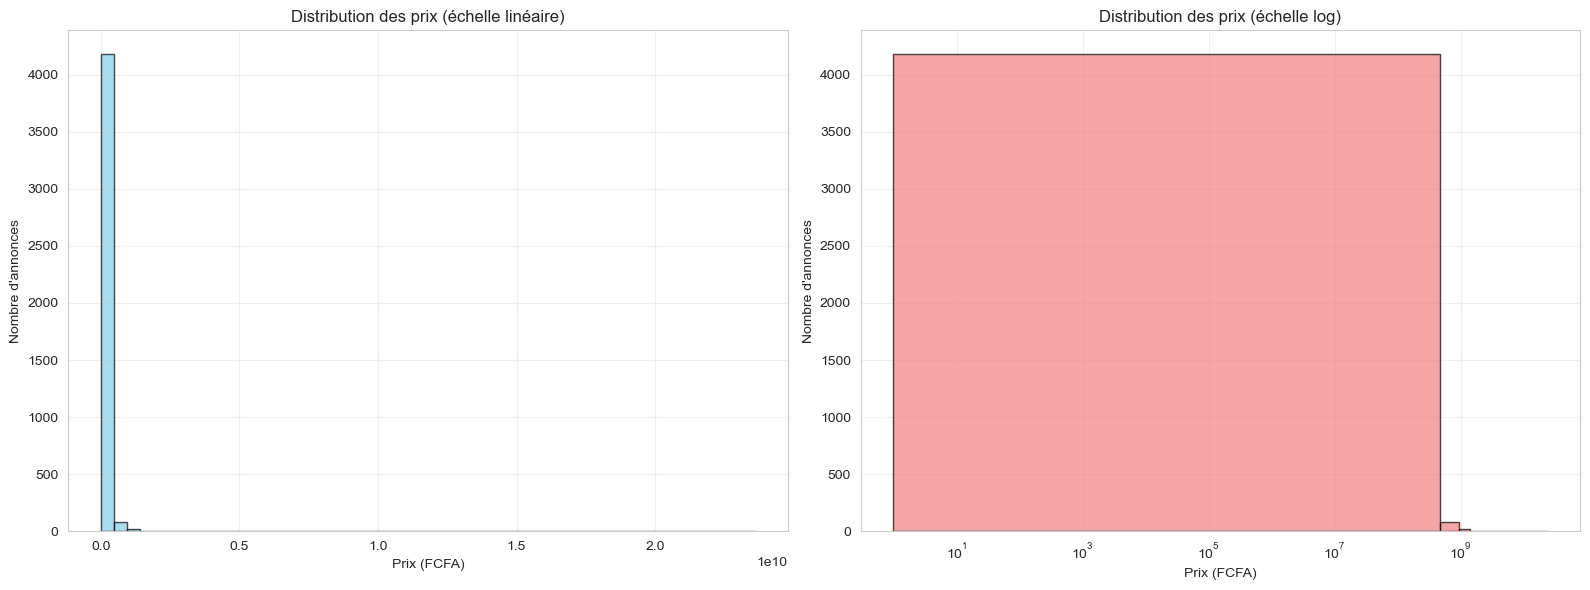


📊 Statistiques de la distribution :
   Prix moyen  : 77,451,639 FCFA
   Prix médian : 1,000,000 FCFA
   Skewness    : 32.25 (asymétrie)
   Kurtosis    : 1335.29 (aplatissement)

✅ Histogramme sauvegardé : distribution_prix.png

  Fin: 2026-03-13 01:23:46


In [40]:
# ============================================
# TÂCHE 2 — HISTOGRAMME DES PRIX
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("="*65)
print("  TÂCHE 2 — HISTOGRAMME DES PRIX")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Configuration pour un affichage correct
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style("whitegrid")

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
prix_valides = df['prix_fcfa'].dropna()
print(f"\n📂 {len(prix_valides)} prix valides chargés")

# Création de la figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogramme normal
axes[0].hist(prix_valides, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Prix (FCFA)')
axes[0].set_ylabel("Nombre d'annonces")
axes[0].set_title('Distribution des prix (échelle linéaire)')
axes[0].grid(True, alpha=0.3)

# 2. Histogramme en échelle logarithmique (pour mieux voir)
axes[1].hist(prix_valides, bins=50, color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Prix (FCFA)')
axes[1].set_ylabel("Nombre d'annonces")
axes[1].set_title('Distribution des prix (échelle log)')
axes[1].set_xscale('log')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distribution_prix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Statistiques de la distribution :")
print(f"   Prix moyen  : {prix_valides.mean():,.0f} FCFA")
print(f"   Prix médian : {prix_valides.median():,.0f} FCFA")
print(f"   Skewness    : {prix_valides.skew():.2f} (asymétrie)")
print(f"   Kurtosis    : {prix_valides.kurtosis():.2f} (aplatissement)")

print(f"\n✅ Histogramme sauvegardé : distribution_prix.png")
print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# - TÂCHE 3 — Créer l'histogramme de distribution des surfaces

  TÂCHE 3 — HISTOGRAMME DES SURFACES
  Démarrage: 2026-03-13 01:26:08

📂 1381 surfaces valides chargées


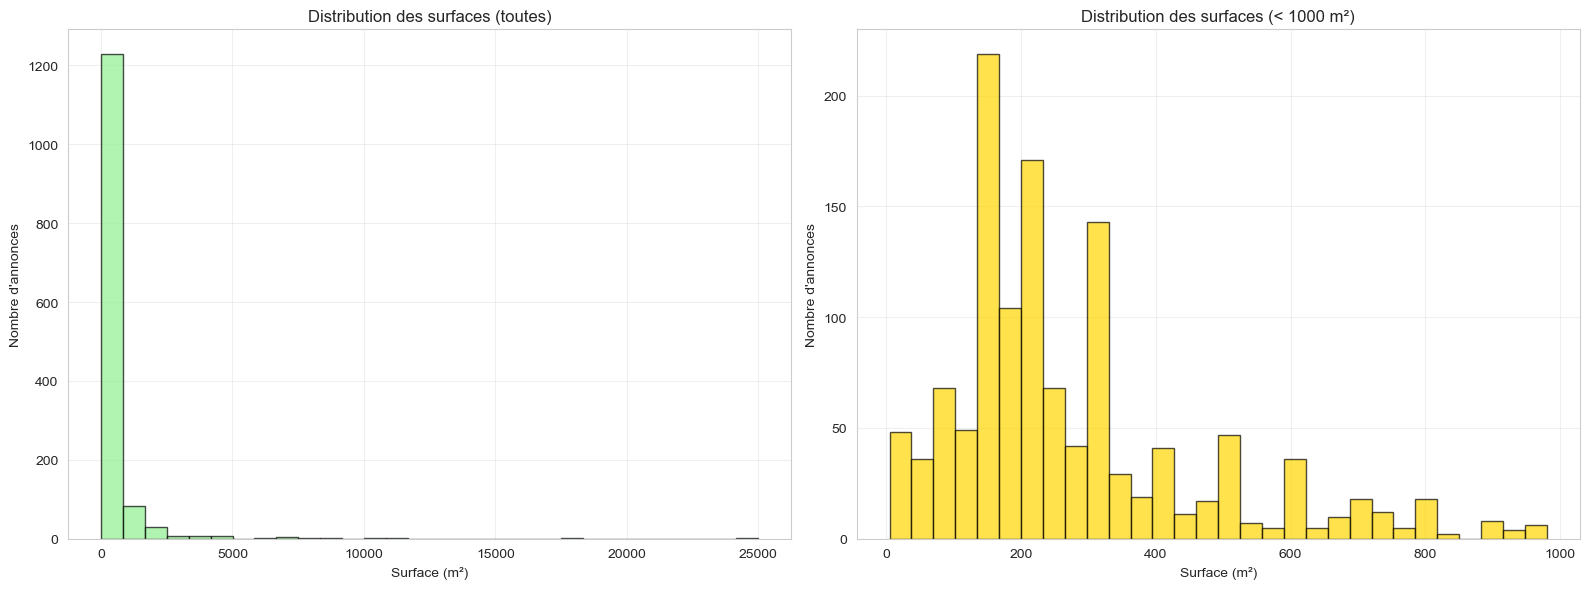


📊 Statistiques des surfaces :
   Surface moyenne : 525 m²
   Surface médiane : 230 m²
   Minimum         : 5 m²
   Maximum         : 25000 m²

✅ Histogramme sauvegardé : distribution_surfaces.png

  Fin: 2026-03-13 01:26:10


In [41]:
# ============================================
# TÂCHE 3 — HISTOGRAMME DES SURFACES
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("="*65)
print("  TÂCHE 3 — HISTOGRAMME DES SURFACES")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
surf_valides = df['surface_m2'].dropna()
print(f"\n📂 {len(surf_valides)} surfaces valides chargées")

# Création de la figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Histogramme normal
axes[0].hist(surf_valides, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Surface (m²)')
axes[0].set_ylabel("Nombre d'annonces")
axes[0].set_title('Distribution des surfaces (toutes)')
axes[0].grid(True, alpha=0.3)

# 2. Histogramme zoomé sur les petites surfaces (< 1000 m²)
surf_zoom = surf_valides[surf_valides < 1000]
axes[1].hist(surf_zoom, bins=30, color='gold', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Surface (m²)')
axes[1].set_ylabel("Nombre d'annonces")
axes[1].set_title('Distribution des surfaces (< 1000 m²)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('distribution_surfaces.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Statistiques des surfaces :")
print(f"   Surface moyenne : {surf_valides.mean():.0f} m²")
print(f"   Surface médiane : {surf_valides.median():.0f} m²")
print(f"   Minimum         : {surf_valides.min():.0f} m²")
print(f"   Maximum         : {surf_valides.max():.0f} m²")

print(f"\n✅ Histogramme sauvegardé : distribution_surfaces.png")
print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# - TÂCHE 4 — Compter la distribution par nombre de pièces

  TÂCHE 4 — DISTRIBUTION PAR NOMBRE DE PIÈCES
  Démarrage: 2026-03-13 01:36:09

📂 2580 annonces avec nombre de chambres

📊 DISTRIBUTION DES CHAMBRES :
   1 chambre :  237 annonces (9.2%)
   2 chambres :  654 annonces (25.3%)
   3 chambres : 1130 annonces (43.8%)
   4 chambres :  347 annonces (13.4%)
   5 chambres :  131 annonces (5.1%)
   6 chambres :   48 annonces (1.9%)
   7 chambres :   19 annonces (0.7%)
   8 chambres :    7 annonces (0.3%)
   9 chambres :    2 annonces (0.1%)
   10 chambres :    2 annonces (0.1%)
   19 chambres :    1 annonces (0.0%)
   24 chambres :    1 annonces (0.0%)
   149 chambres :    1 annonces (0.0%)


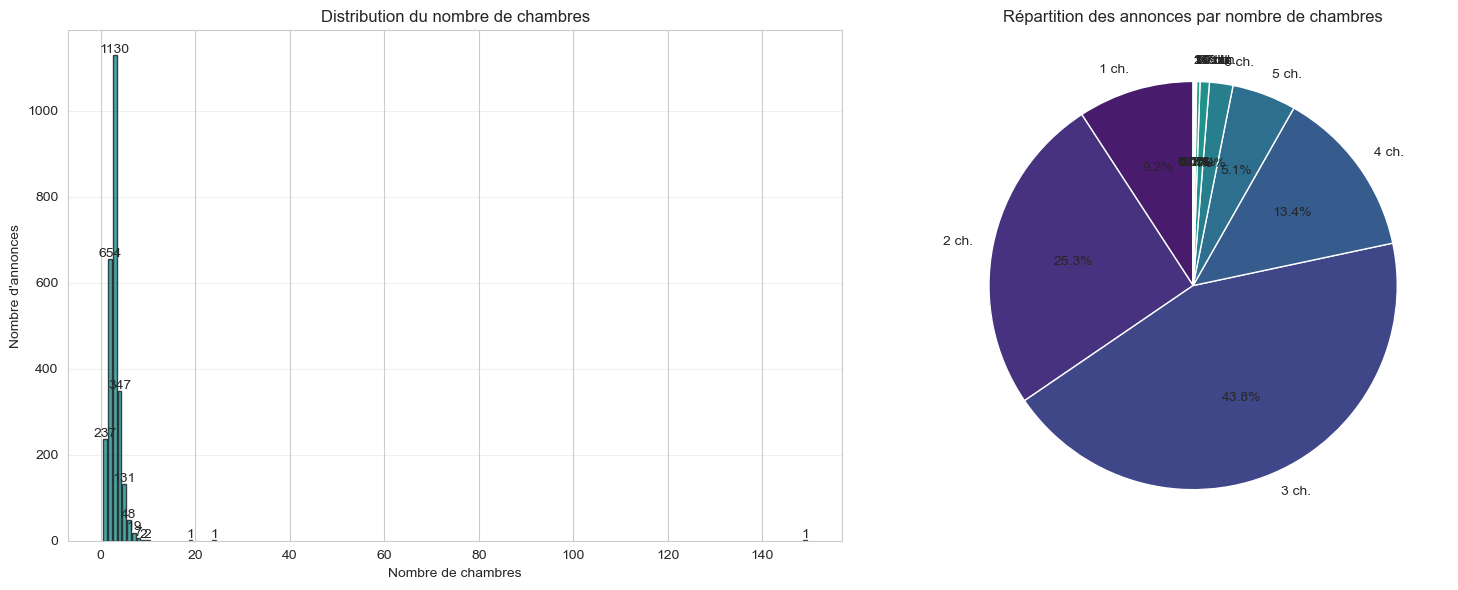


✅ Graphique sauvegardé : distribution_pieces.png

  Fin: 2026-03-13 01:36:10


In [42]:
# ============================================
# TÂCHE 4 — DISTRIBUTION PAR NOMBRE DE PIÈCES
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("="*65)
print("  TÂCHE 4 — DISTRIBUTION PAR NOMBRE DE PIÈCES")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
chambres_valides = df['nb_chambres'].dropna()
print(f"\n📂 {len(chambres_valides)} annonces avec nombre de chambres")

# Comptage par nombre de chambres
distribution = chambres_valides.value_counts().sort_index()
print(f"\n📊 DISTRIBUTION DES CHAMBRES :")
for nb, count in distribution.items():
    pourcentage = (count / len(chambres_valides)) * 100
    print(f"   {int(nb)} chambre{'s' if nb > 1 else ''} : {count:>4} annonces ({pourcentage:.1f}%)")

# Création du graphique
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
axes[0].bar(distribution.index.astype(int), distribution.values, 
            color='teal', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Nombre de chambres')
axes[0].set_ylabel("Nombre d'annonces")
axes[0].set_title('Distribution du nombre de chambres')
axes[0].grid(True, alpha=0.3, axis='y')
for i, (x, y) in enumerate(zip(distribution.index, distribution.values)):
    axes[0].text(x, y + 5, str(y), ha='center', fontsize=10)

# Pie chart
axes[1].pie(distribution.values, labels=[f"{int(nb)} ch." for nb in distribution.index],
            autopct='%1.1f%%', startangle=90, colors=sns.color_palette('viridis', len(distribution)))
axes[1].set_title('Répartition des annonces par nombre de chambres')

plt.tight_layout()
plt.savefig('distribution_pieces.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphique sauvegardé : distribution_pieces.png")
print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# - TÂCHE 5 — Calculer le prix moyen par ville

  TÂCHE 5 — PRIX MOYEN PAR VILLE
  Démarrage: 2026-03-13 01:39:52

📂 4313 annonces chargées
📊 3272 annonces avec ville et prix renseignés

📊 PRIX MOYEN PAR VILLE :
                    mean      median  count         min           max
ville                                                                
Kaolack      176910500.0  38803500.0      3     15000.0  4.919130e+08
Rufisque     170109678.0   4000000.0     62         7.0  3.750000e+09
Mbour        114430444.0  48000000.0    205     15000.0  9.500000e+08
Dakar         73497547.0    950000.0   2799         1.0  1.500000e+10
Touba         68217789.0  20000000.0     19     20000.0  5.500000e+08
Pikine        47703878.0    575000.0     76        12.0  1.100000e+09
Diamniadio    46283500.0   3750000.0     46      1000.0  5.500000e+08
Thiès         35983375.0    900000.0     48         1.0  6.000000e+08
Guédiawaye    23464286.0    280000.0      7     20000.0  7.500000e+07
Ziguinchor    15500000.0  15500000.0      1  15500000.0  1.550000e

C:\Users\Dell\AppData\Local\Temp\ipykernel_9100\868951504.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top, x='ville', y='prix_fcfa', palette='viridis')


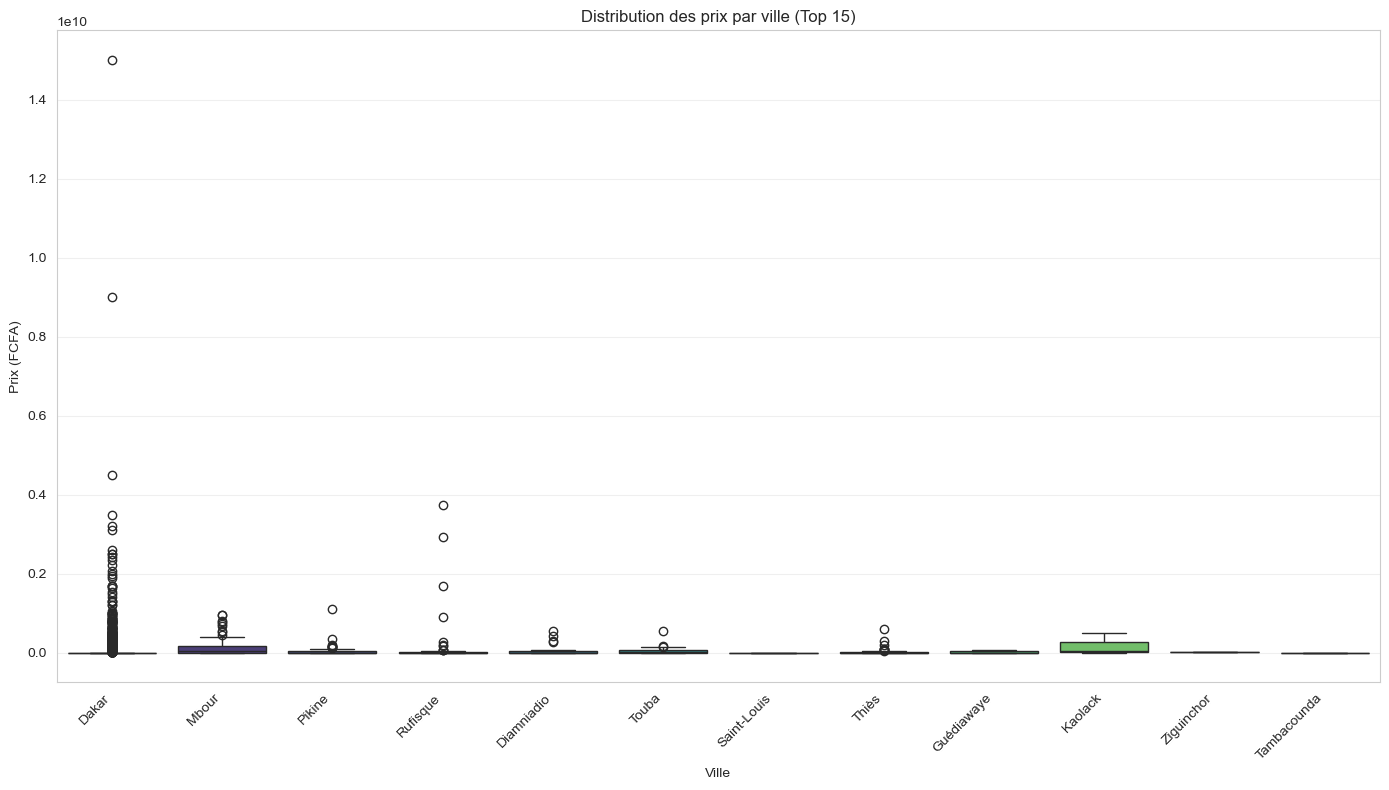


✅ Graphique sauvegardé : prix_par_ville.png


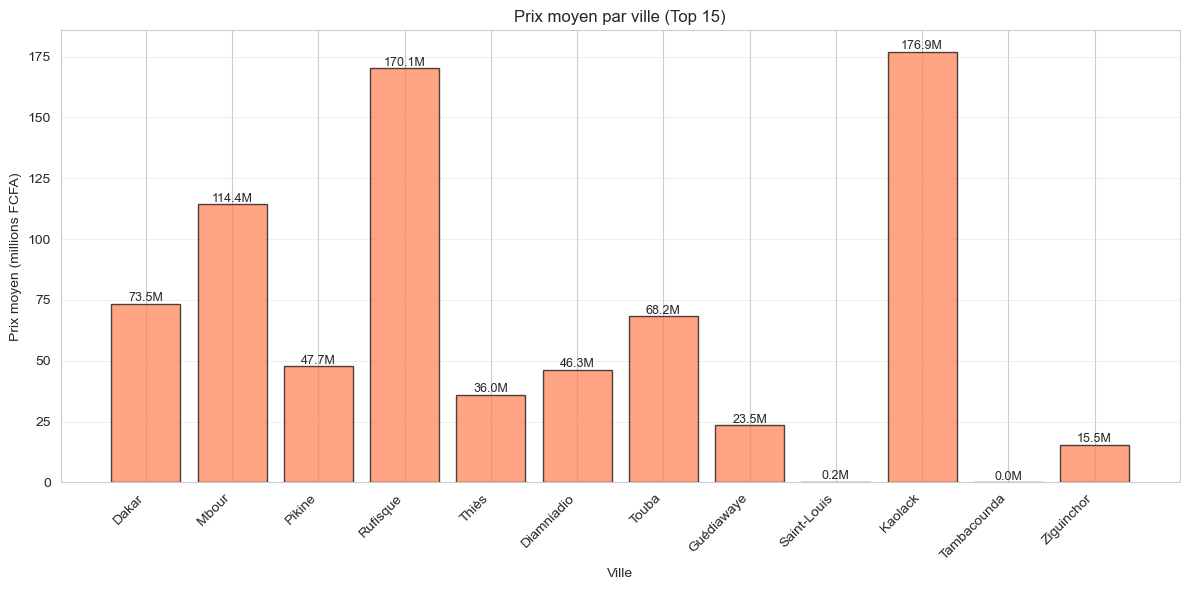


✅ Graphique sauvegardé : prix_moyen_par_ville.png

  Fin: 2026-03-13 01:39:54


In [43]:
# ============================================
# TÂCHE 5 — PRIX MOYEN PAR VILLE
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("="*65)
print("  TÂCHE 5 — PRIX MOYEN PAR VILLE")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# Filtrer les annonces avec ville et prix valides
df_ville = df.dropna(subset=['ville', 'prix_fcfa'])
print(f"📊 {len(df_ville)} annonces avec ville et prix renseignés")

# Calcul du prix moyen par ville
prix_moyen_ville = df_ville.groupby('ville')['prix_fcfa'].agg(['mean', 'median', 'count', 'min', 'max'])
prix_moyen_ville = prix_moyen_ville.sort_values('mean', ascending=False)
prix_moyen_ville['mean'] = prix_moyen_ville['mean'].round(0)
prix_moyen_ville['median'] = prix_moyen_ville['median'].round(0)

print(f"\n📊 PRIX MOYEN PAR VILLE :")
print(prix_moyen_ville.to_string())

# Sauvegarde en CSV
prix_moyen_ville.to_csv('prix_moyen_par_ville.csv')
print(f"\n💾 Tableau sauvegardé : prix_moyen_par_ville.csv")

# Création du graphique
plt.figure(figsize=(14, 8))

# Top 15 villes par nombre d'annonces
top_villes = df_ville['ville'].value_counts().head(15).index
df_top = df_ville[df_ville['ville'].isin(top_villes)]

sns.boxplot(data=df_top, x='ville', y='prix_fcfa', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Ville')
plt.ylabel('Prix (FCFA)')
plt.title('Distribution des prix par ville (Top 15)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('prix_par_ville.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphique sauvegardé : prix_par_ville.png")

# Bar chart des prix moyens
plt.figure(figsize=(12, 6))
prix_moyen_ville_top = prix_moyen_ville.loc[top_villes]
bars = plt.bar(range(len(prix_moyen_ville_top)), prix_moyen_ville_top['mean'] / 1_000_000, 
               color='coral', edgecolor='black', alpha=0.7)
plt.xticks(range(len(prix_moyen_ville_top)), prix_moyen_ville_top.index, rotation=45, ha='right')
plt.xlabel('Ville')
plt.ylabel('Prix moyen (millions FCFA)')
plt.title('Prix moyen par ville (Top 15)')
plt.grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for i, (bar, val) in enumerate(zip(bars, prix_moyen_ville_top['mean'])):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{val/1_000_000:.1f}M', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('prix_moyen_par_ville.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphique sauvegardé : prix_moyen_par_ville.png")
print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

## Tâches de DIEYNABA BA
# Identifier le top 10 des quartiers les plus chers
# Identifier le top 10 des quartiers les plus accessibles
# Calculer le prix au m² par quartier
# Créer une carte interactive des prix


# - TÂCHE 1 — Identifier le top 10 des quartiers les plus chers

  TÂCHE 1 — TOP 10 DES QUARTIERS LES PLUS CHERS
  Démarrage: 2026-03-13 01:58:22

📂 4313 annonces chargées
📊 3272 annonces avec quartier et prix renseignés

🏆 TOP 10 DES QUARTIERS LES PLUS CHERS (prix moyen) :
 1. Rufisque                  :     270,154,737 FCFA  (médian:    4,000,000 FCFA, 38.0 annonces)
 2. Baobabs                   :     226,516,667 FCFA  (médian:  329,500,000 FCFA, 3.0 annonces)
 3. Ngor                      :     214,195,391 FCFA  (médian:      800,000 FCFA, 120.0 annonces)
 4. Keur Gorgui               :     200,200,000 FCFA  (médian:      375,000 FCFA, 4.0 annonces)
 5. Fann                      :     187,455,598 FCFA  (médian:    2,000,000 FCFA, 110.0 annonces)
 6. Kaolack                   :     176,910,500 FCFA  (médian:   38,803,500 FCFA, 3.0 annonces)
 7. Popenguine                :     159,125,000 FCFA  (médian:  148,375,000 FCFA, 10.0 annonces)
 8. Médina                    :     146,389,167 FCFA  (médian:   64,160,000 FCFA, 6.0 annonces)
 9. Nord Foire  

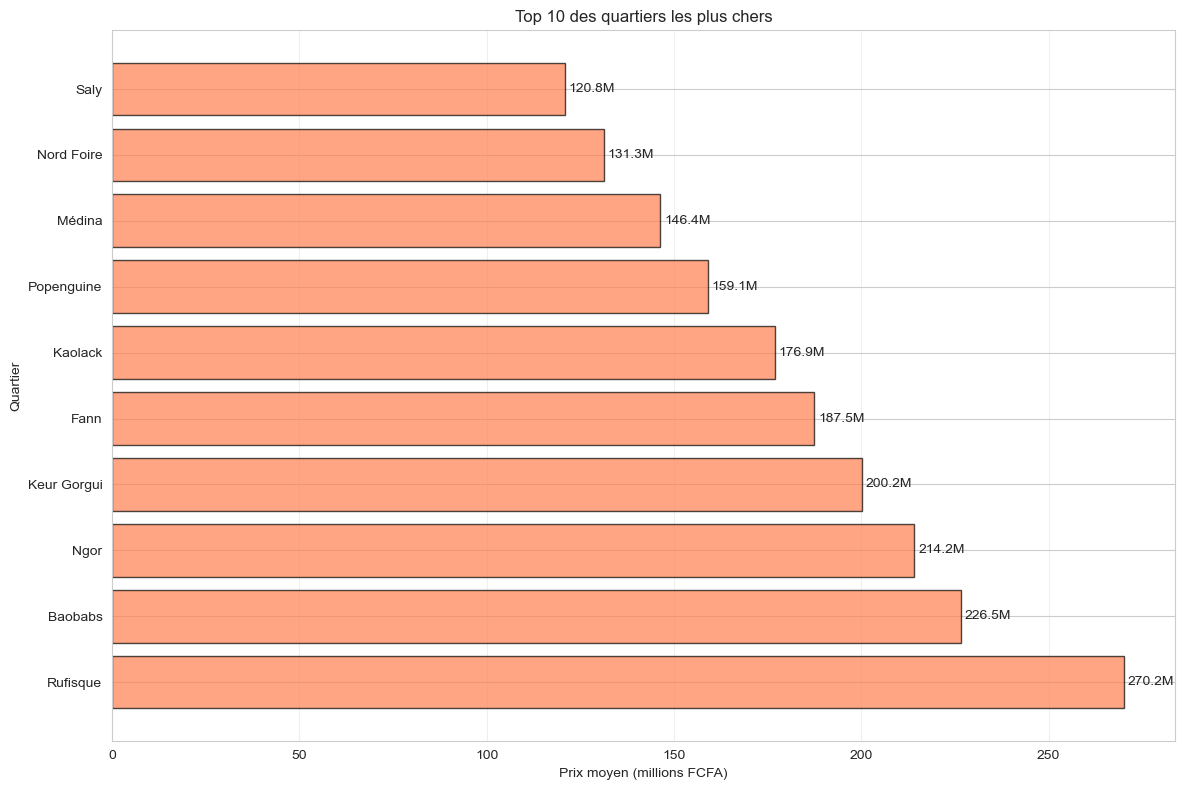


✅ Graphique sauvegardé : top_10_quartiers_chers.png

  Fin: 2026-03-13 01:58:23


In [44]:
# ============================================
# TÂCHE 1 — TOP 10 DES QUARTIERS LES PLUS CHERS
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("="*65)
print("  TÂCHE 1 — TOP 10 DES QUARTIERS LES PLUS CHERS")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# Filtrer les annonces avec quartier et prix valides
df_quartier = df.dropna(subset=['quartier', 'prix_fcfa'])
print(f"📊 {len(df_quartier)} annonces avec quartier et prix renseignés")

# Calcul du prix moyen par quartier
prix_moyen_quartier = df_quartier.groupby('quartier')['prix_fcfa'].agg(['mean', 'median', 'count', 'min', 'max'])
prix_moyen_quartier = prix_moyen_quartier.sort_values('mean', ascending=False)

# Top 10 des quartiers les plus chers
top_10_chers = prix_moyen_quartier.head(10).copy()
top_10_chers['mean'] = top_10_chers['mean'].round(0)
top_10_chers['median'] = top_10_chers['median'].round(0)

print(f"\n🏆 TOP 10 DES QUARTIERS LES PLUS CHERS (prix moyen) :")
print("="*65)
for i, (quartier, row) in enumerate(top_10_chers.iterrows(), 1):
    print(f"{i:2}. {quartier:<25} : {row['mean']:>15,.0f} FCFA  (médian: {row['median']:>12,.0f} FCFA, {row['count']:>3} annonces)")

# Sauvegarde en CSV
top_10_chers.to_csv('top_10_quartiers_chers.csv')
print(f"\n💾 Tableau sauvegardé : top_10_quartiers_chers.csv")

# Graphique
plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_10_chers)), top_10_chers['mean'] / 1_000_000, 
                color='coral', edgecolor='black', alpha=0.7)
plt.yticks(range(len(top_10_chers)), top_10_chers.index)
plt.xlabel('Prix moyen (millions FCFA)')
plt.ylabel('Quartier')
plt.title('Top 10 des quartiers les plus chers')
plt.grid(True, alpha=0.3, axis='x')

# Ajouter les valeurs sur les barres
for i, (bar, val) in enumerate(zip(bars, top_10_chers['mean'])):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{val/1_000_000:.1f}M', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('top_10_quartiers_chers.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphique sauvegardé : top_10_quartiers_chers.png")
print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# - TÂCHE 2 — Identifier le top 10 des quartiers les plus accessibles

  TÂCHE 2 — TOP 10 DES QUARTIERS LES PLUS ACCESSIBLES
  Démarrage: 2026-03-13 01:59:07

📂 4313 annonces chargées
📊 3272 annonces avec quartier et prix renseignés

🏆 TOP 10 DES QUARTIERS LES PLUS ACCESSIBLES (prix moyen le plus bas) :
 1. Cité Keur Gorgui          :      11,070,114 FCFA  (médian:      450,000 FCFA, 65.0 annonces)
 2. Lac Rose                  :      12,105,218 FCFA  (médian:    4,500,000 FCFA, 23.0 annonces)
 3. Keur Massar               :      18,379,900 FCFA  (médian:      190,000 FCFA, 25.0 annonces)
 4. Sacre Coeur               :      19,056,700 FCFA  (médian:      500,000 FCFA, 40.0 annonces)
 5. Foire                     :      19,435,665 FCFA  (médian:      250,000 FCFA, 54.0 annonces)
 6. Sicap                     :      20,799,162 FCFA  (médian:      400,000 FCFA, 68.0 annonces)
 7. Guédiawaye                :      23,464,286 FCFA  (médian:      280,000 FCFA, 7.0 annonces)
 8. Ouakam                    :      23,960,600 FCFA  (médian:      462,500 FCFA, 84.0 a

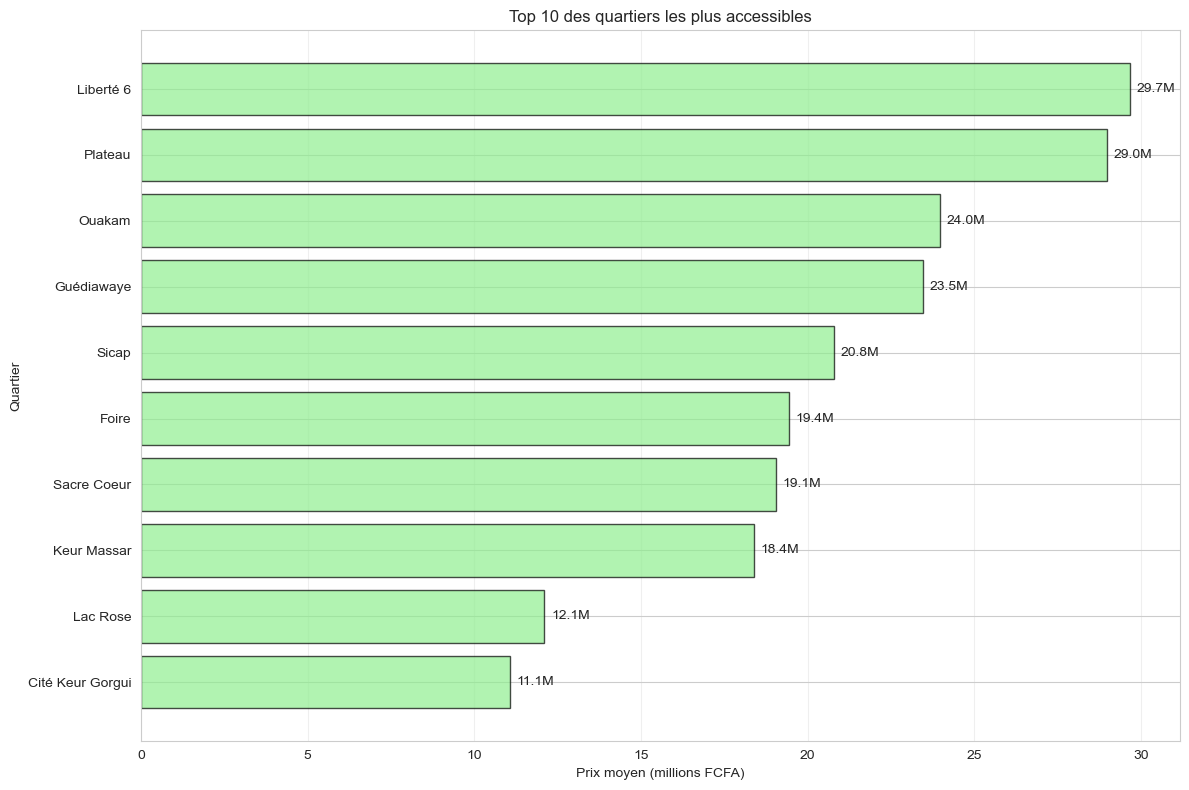


✅ Graphique sauvegardé : top_10_quartiers_accessibles.png

  Fin: 2026-03-13 01:59:08


In [45]:
# ============================================
# TÂCHE 2 — TOP 10 DES QUARTIERS LES PLUS ACCESSIBLES
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("="*65)
print("  TÂCHE 2 — TOP 10 DES QUARTIERS LES PLUS ACCESSIBLES")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# Filtrer les annonces avec quartier et prix valides
df_quartier = df.dropna(subset=['quartier', 'prix_fcfa'])
print(f"📊 {len(df_quartier)} annonces avec quartier et prix renseignés")

# Calcul du prix moyen par quartier
prix_moyen_quartier = df_quartier.groupby('quartier')['prix_fcfa'].agg(['mean', 'median', 'count', 'min', 'max'])
prix_moyen_quartier = prix_moyen_quartier.sort_values('mean', ascending=True)

# Filtrer les quartiers avec au moins 5 annonces pour plus de fiabilité
prix_moyen_quartier_filtre = prix_moyen_quartier[prix_moyen_quartier['count'] >= 5]

# Top 10 des quartiers les plus accessibles
top_10_accessibles = prix_moyen_quartier_filtre.head(10).copy()
top_10_accessibles['mean'] = top_10_accessibles['mean'].round(0)
top_10_accessibles['median'] = top_10_accessibles['median'].round(0)

print(f"\n🏆 TOP 10 DES QUARTIERS LES PLUS ACCESSIBLES (prix moyen le plus bas) :")
print("="*65)
for i, (quartier, row) in enumerate(top_10_accessibles.iterrows(), 1):
    print(f"{i:2}. {quartier:<25} : {row['mean']:>15,.0f} FCFA  (médian: {row['median']:>12,.0f} FCFA, {row['count']:>3} annonces)")

# Sauvegarde en CSV
top_10_accessibles.to_csv('top_10_quartiers_accessibles.csv')
print(f"\n💾 Tableau sauvegardé : top_10_quartiers_accessibles.csv")

# Graphique
plt.figure(figsize=(12, 8))
bars = plt.barh(range(len(top_10_accessibles)), top_10_accessibles['mean'] / 1_000_000, 
                color='lightgreen', edgecolor='black', alpha=0.7)
plt.yticks(range(len(top_10_accessibles)), top_10_accessibles.index)
plt.xlabel('Prix moyen (millions FCFA)')
plt.ylabel('Quartier')
plt.title('Top 10 des quartiers les plus accessibles')
plt.grid(True, alpha=0.3, axis='x')

# Ajouter les valeurs sur les barres
for i, (bar, val) in enumerate(zip(bars, top_10_accessibles['mean'])):
    plt.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2, 
             f'{val/1_000_000:.1f}M', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('top_10_quartiers_accessibles.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphique sauvegardé : top_10_quartiers_accessibles.png")
print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# - TÂCHE 3 — Calculer le prix au m² par quartier

  TÂCHE 3 — PRIX AU M² PAR QUARTIER
  Démarrage: 2026-03-13 01:59:45

📂 4313 annonces chargées
📊 1005 annonces avec quartier, prix et surface renseignés

📊 PRIX AU M² PAR QUARTIER (moyenne) :
                     prix_m2_moyen  prix_m2_median  prix_m2_min  prix_m2_max  nb_annonces    prix_moyen  surface_moyenne
quartier                                                                                                                
Nord Foire              46753846.0      46753846.0   46753846.0   46753846.0            1  2.431200e+09             52.0
Parcelles Assainies      6255188.0        508334.0       4083.0   24000000.0            4  8.387250e+07            144.0
Mbao                     3842051.0        207260.0          1.0   91666667.0           26  9.967350e+07            208.0
Fann                     1734343.0          9565.0        574.0   39166667.0           37  4.812427e+08            561.0
Pikine                   1200000.0       1200000.0    1200000.0    1200000.0      

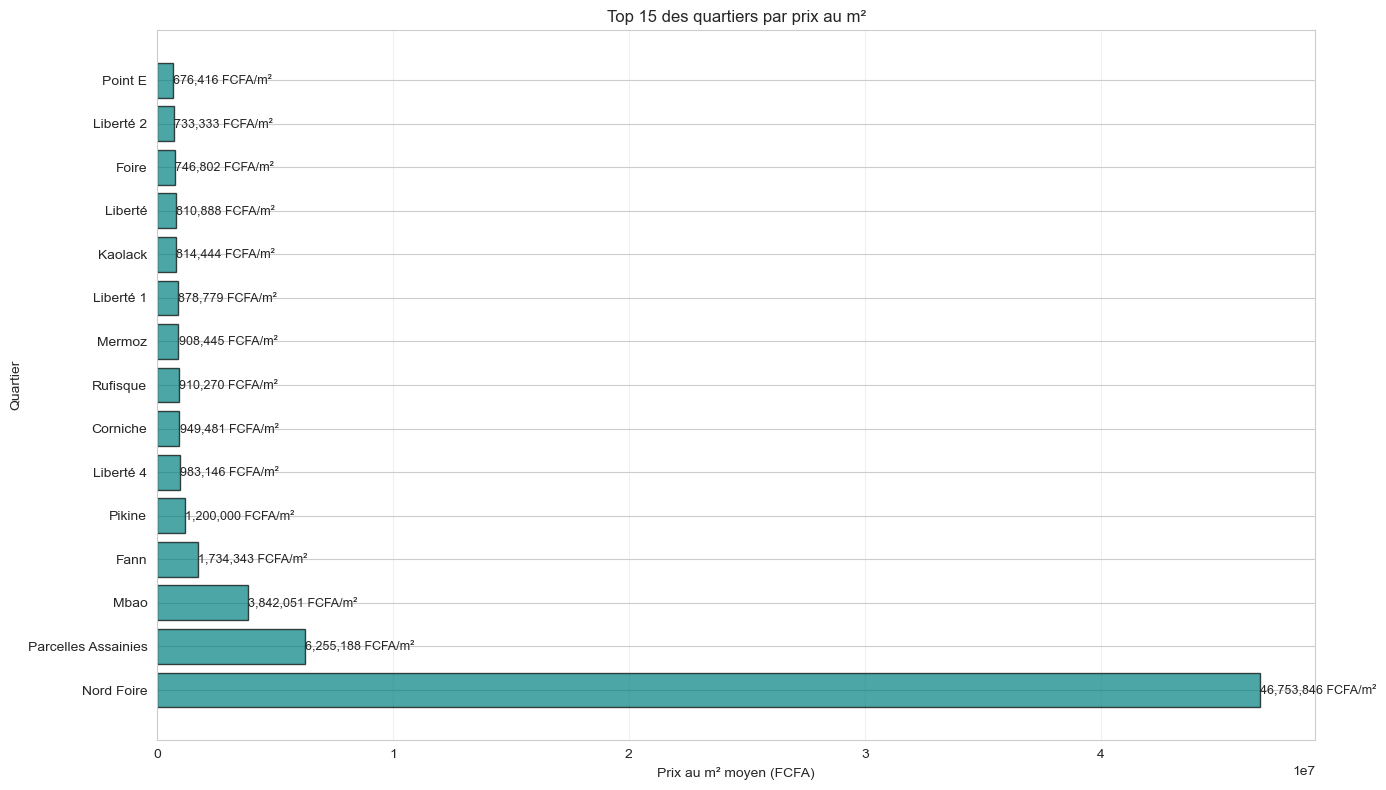


✅ Graphique sauvegardé : prix_m2_par_quartier.png

  Fin: 2026-03-13 01:59:47


In [46]:
# ============================================
# TÂCHE 3 — PRIX AU M² PAR QUARTIER
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("="*65)
print("  TÂCHE 3 — PRIX AU M² PAR QUARTIER")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# Filtrer les annonces avec quartier, prix et surface valides
df_prix_m2 = df.dropna(subset=['quartier', 'prix_fcfa', 'surface_m2'])
print(f"📊 {len(df_prix_m2)} annonces avec quartier, prix et surface renseignés")

# Calcul du prix au m² moyen par quartier
prix_m2_quartier = df_prix_m2.groupby('quartier').agg({
    'prix_m2_fcfa': ['mean', 'median', 'min', 'max', 'count'],
    'prix_fcfa': 'mean',
    'surface_m2': 'mean'
})

# Aplatir les colonnes
prix_m2_quartier.columns = ['_'.join(col).strip() for col in prix_m2_quartier.columns.values]
prix_m2_quartier = prix_m2_quartier.rename(columns={
    'prix_m2_fcfa_mean': 'prix_m2_moyen',
    'prix_m2_fcfa_median': 'prix_m2_median',
    'prix_m2_fcfa_min': 'prix_m2_min',
    'prix_m2_fcfa_max': 'prix_m2_max',
    'prix_m2_fcfa_count': 'nb_annonces',
    'prix_fcfa_mean': 'prix_moyen',
    'surface_m2_mean': 'surface_moyenne'
})

prix_m2_quartier = prix_m2_quartier.sort_values('prix_m2_moyen', ascending=False)
prix_m2_quartier = prix_m2_quartier.round(0)

print(f"\n📊 PRIX AU M² PAR QUARTIER (moyenne) :")
print("="*65)
print(prix_m2_quartier.head(20).to_string())

# Sauvegarde en CSV
prix_m2_quartier.to_csv('prix_m2_par_quartier.csv')
print(f"\n💾 Tableau sauvegardé : prix_m2_par_quartier.csv")

# Top 15 quartiers par prix au m²
top_15_m2 = prix_m2_quartier.head(15).copy()

plt.figure(figsize=(14, 8))
bars = plt.barh(range(len(top_15_m2)), top_15_m2['prix_m2_moyen'], 
                color='teal', edgecolor='black', alpha=0.7)
plt.yticks(range(len(top_15_m2)), top_15_m2.index)
plt.xlabel('Prix au m² moyen (FCFA)')
plt.ylabel('Quartier')
plt.title('Top 15 des quartiers par prix au m²')
plt.grid(True, alpha=0.3, axis='x')

# Ajouter les valeurs sur les barres
for i, (bar, val) in enumerate(zip(bars, top_15_m2['prix_m2_moyen'])):
    plt.text(bar.get_width() + 5000, bar.get_y() + bar.get_height()/2, 
             f'{val:,.0f} FCFA/m²', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('prix_m2_par_quartier.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphique sauvegardé : prix_m2_par_quartier.png")
print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# - TÂCHE 4 — Créer une carte interactive des prix

In [50]:
# ============================================
# INSTALLATION DE FOLIUM avant tout d'abord
# ============================================

!pip install folium

import folium
from folium.plugins import MarkerCluster, HeatMap
print(f"✅ Folium installé avec succès (version: {folium.__version__})")

✅ Folium installé avec succès (version: 0.20.0)


  TÂCHE 4 — CARTE INTERACTIVE DES PRIX
  Démarrage: 2026-03-13 02:02:37

📂 4313 annonces chargées
📊 3272 annonces pour la carte

🗺️ Création de la carte interactive...


C:\Users\Dell\AppData\Local\Temp\ipykernel_9100\1439368934.py:86: UserWarning: color argument of Icon should be one of: {'lightblue', 'black', 'gray', 'lightred', 'darkblue', 'white', 'cadetblue', 'pink', 'orange', 'darkgreen', 'darkred', 'red', 'blue', 'beige', 'green', 'lightgray', 'lightgreen', 'purple', 'darkpurple'}.
  icon=folium.Icon(color=couleur, icon='home', prefix='fa')


✅ Carte sauvegardée : carte_prix_immobiliers.html

📊 Distribution des prix par quartier (Top 20) :


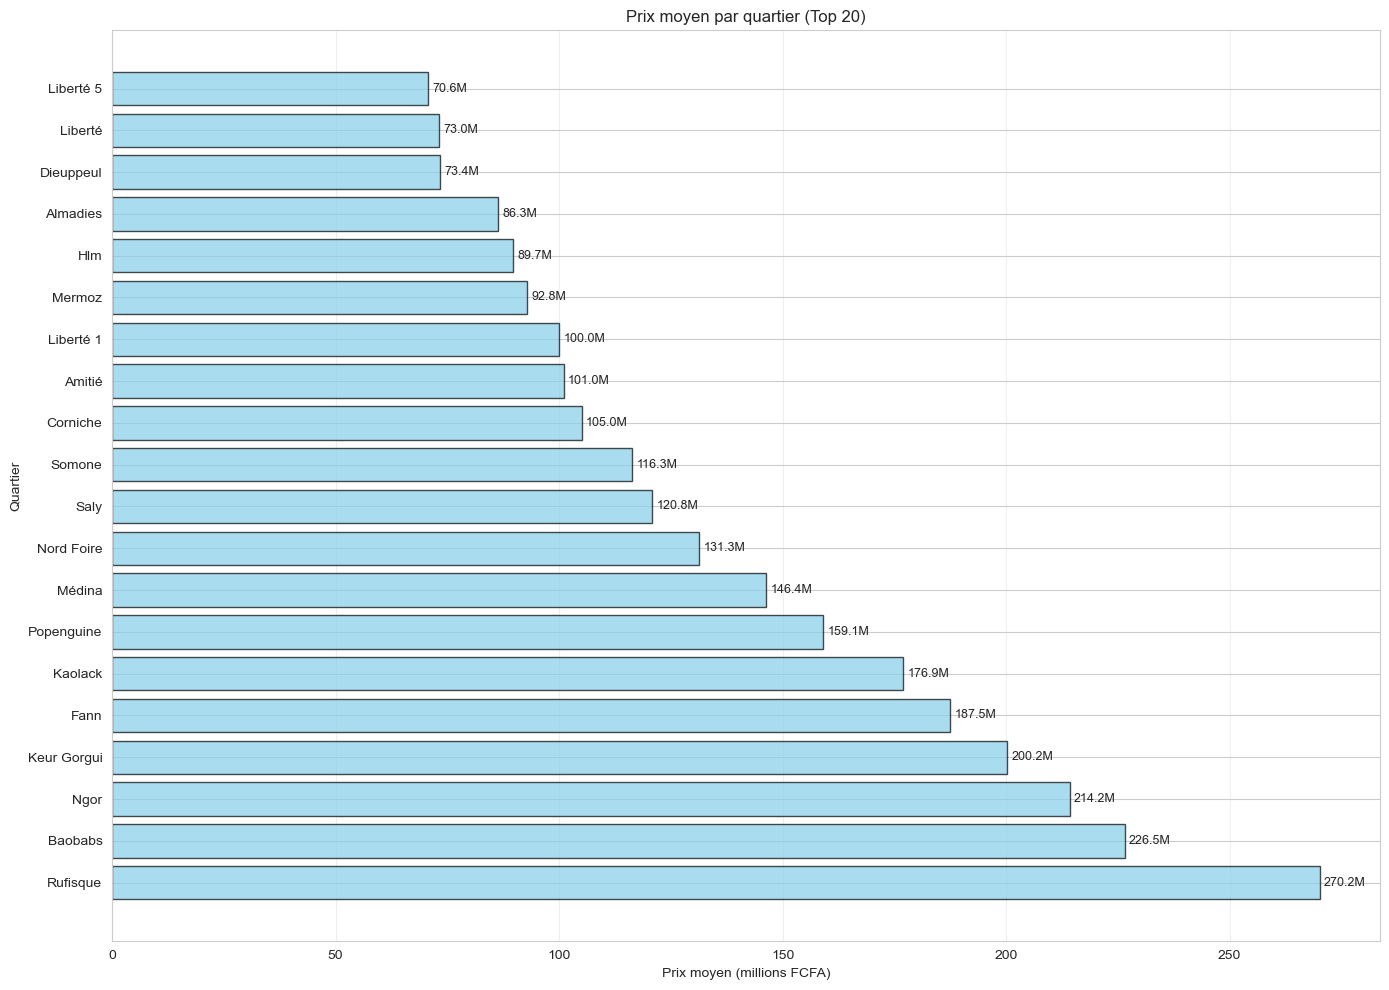


✅ Graphique sauvegardé : prix_par_quartier_top20.png

  Fin: 2026-03-13 02:02:38


In [51]:
# ============================================
# TÂCHE 4 — CARTE INTERACTIVE DES PRIX
# ============================================

import pandas as pd
import folium
from folium.plugins import MarkerCluster, HeatMap
import matplotlib.pyplot as plt
from datetime import datetime

print("="*65)
print("  TÂCHE 4 — CARTE INTERACTIVE DES PRIX")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# Filtrer les annonces avec quartier et prix valides
df_carte = df.dropna(subset=['quartier', 'prix_fcfa'])
print(f"📊 {len(df_carte)} annonces pour la carte")

# Prix moyen par quartier
prix_moyen_quartier = df_carte.groupby('quartier')['prix_fcfa'].mean().round(0).sort_values(ascending=False)

# Dictionnaire approximatif des coordonnées des principaux quartiers de Dakar
coordonnees_quartiers = {
    'Almadies': [14.7436, -17.5262],
    'Mermoz': [14.7031, -17.4678],
    'Point E': [14.6950, -17.4650],
    'Mamelles': [14.7367, -17.5122],
    'Plateau': [14.6700, -17.4367],
    'Vdn': [14.7133, -17.4767],
    'Yoff': [14.7567, -17.4783],
    'Ngor': [14.7550, -17.5150],
    'Fann': [14.6867, -17.4733],
    'Sacre Coeur': [14.7100, -17.4633],
    'Dieuppeul': [14.7050, -17.4583],
    'Ouakam': [14.7233, -17.4933],
    'Corniche': [14.6817, -17.4567],
    'Sicap': [14.7017, -17.4467],
    'HLM': [14.6800, -17.4383],
    'Medina': [14.6767, -17.4417],
    'Grand Dakar': [14.6950, -17.4417],
    'Foire': [14.7450, -17.4583],
    'Keur Gorgui': [14.7117, -17.4617],
    'Liberte': [14.7083, -17.4483],
}

print(f"\n🗺️ Création de la carte interactive...")

# Créer une carte centrée sur Dakar
carte = folium.Map(location=[14.7167, -17.4677], zoom_start=12, tiles='OpenStreetMap')

# Ajouter un cluster de marqueurs
marker_cluster = MarkerCluster().add_to(carte)

# Ajouter les marqueurs pour chaque quartier
for quartier, prix in prix_moyen_quartier.items():
    if quartier in coordonnees_quartiers:
        coords = coordonnees_quartiers[quartier]
        
        # Déterminer la couleur en fonction du prix
        if prix > 100_000_000:
            couleur = 'red'
        elif prix > 50_000_000:
            couleur = 'orange'
        elif prix > 20_000_000:
            couleur = 'yellow'
        else:
            couleur = 'green'
        
        # Créer le popup avec les informations
        popup_text = f"""
        <b>{quartier}</b><br>
        Prix moyen: {prix:,.0f} FCFA<br>
        Nombre d'annonces: {df_carte[df_carte['quartier'] == quartier].shape[0]}<br>
        """
        
        # Ajouter le marqueur
        folium.Marker(
            location=coords,
            popup=popup_text,
            icon=folium.Icon(color=couleur, icon='home', prefix='fa')
        ).add_to(marker_cluster)

# Ajouter une heatmap si suffisamment de données
heat_data = []
for quartier, prix in prix_moyen_quartier.items():
    if quartier in coordonnees_quartiers and prix > 0:
        coords = coordonnees_quartiers[quartier]
        poids = min(prix / prix_moyen_quartier.max(), 1)
        heat_data.append([coords[0], coords[1], poids])

if heat_data:
    HeatMap(heat_data, radius=15).add_to(carte)

# Sauvegarder la carte
carte.save('carte_prix_immobiliers.html')
print(f"✅ Carte sauvegardée : carte_prix_immobiliers.html")

# Version simplifiée avec bar chart des quartiers
print(f"\n📊 Distribution des prix par quartier (Top 20) :")
top_20 = prix_moyen_quartier.head(20)

plt.figure(figsize=(14, 10))
bars = plt.barh(range(len(top_20)), top_20.values / 1_000_000, 
                color='skyblue', edgecolor='black', alpha=0.7)
plt.yticks(range(len(top_20)), top_20.index)
plt.xlabel('Prix moyen (millions FCFA)')
plt.ylabel('Quartier')
plt.title('Prix moyen par quartier (Top 20)')
plt.grid(True, alpha=0.3, axis='x')

for i, (bar, val) in enumerate(zip(bars, top_20.values)):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{val/1_000_000:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('prix_par_quartier_top20.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphique sauvegardé : prix_par_quartier_top20.png")
print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

## Tâches de GORA DIALLO
# Analyser l'évolution mensuelle des prix
# Étudier les variations saisonnières
# Analyser l'évolution par type de bien
# Calculer la corrélation surface/prix (graphique scatter)


# - TÂCHE 1 — Analyser l'évolution mensuelle des prix

  TÂCHE 1 — ÉVOLUTION MENSUELLE DES PRIX
  Démarrage: 2026-03-13 02:20:47

📂 4313 annonces chargées
📊 4310 annonces avec date et prix renseignés


C:\Users\Dell\AppData\Local\Temp\ipykernel_9100\3080968942.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_evo['date'] = pd.to_datetime(df_evo['annee_pub'].astype(int).astype(str) + '-' +



📈 APERÇU DE L'ÉVOLUTION MENSUELLE (derniers mois) :
             prix_moyen  prix_median  nb_annonces    ecart_type
date                                                           
2025-04-01  111997383.0    2500000.0           99  2.789589e+08
2025-05-01   47757352.0    1550000.0           88  9.682031e+07
2025-06-01   48545252.0    1650000.0          104  8.847300e+07
2025-07-01   85185029.0    1659000.0          153  2.574527e+08
2025-08-01   53250937.0    1300000.0          142  1.167028e+08
2025-09-01   54083356.0    1300000.0          190  1.190300e+08
2025-10-01   58340984.0    1100000.0          247  2.437563e+08
2025-11-01  145293555.0    1200000.0          495  1.175305e+09
2025-12-01   66435227.0     900000.0          523  2.191657e+08
2026-01-01   80474713.0     800000.0          615  6.334493e+08
2026-02-01   65493738.0     900000.0          672  2.302558e+08
2026-03-01   54369239.0    1100000.0          329  1.767020e+08

💾 Tableau sauvegardé : evolution_mensuelle_prix.cs

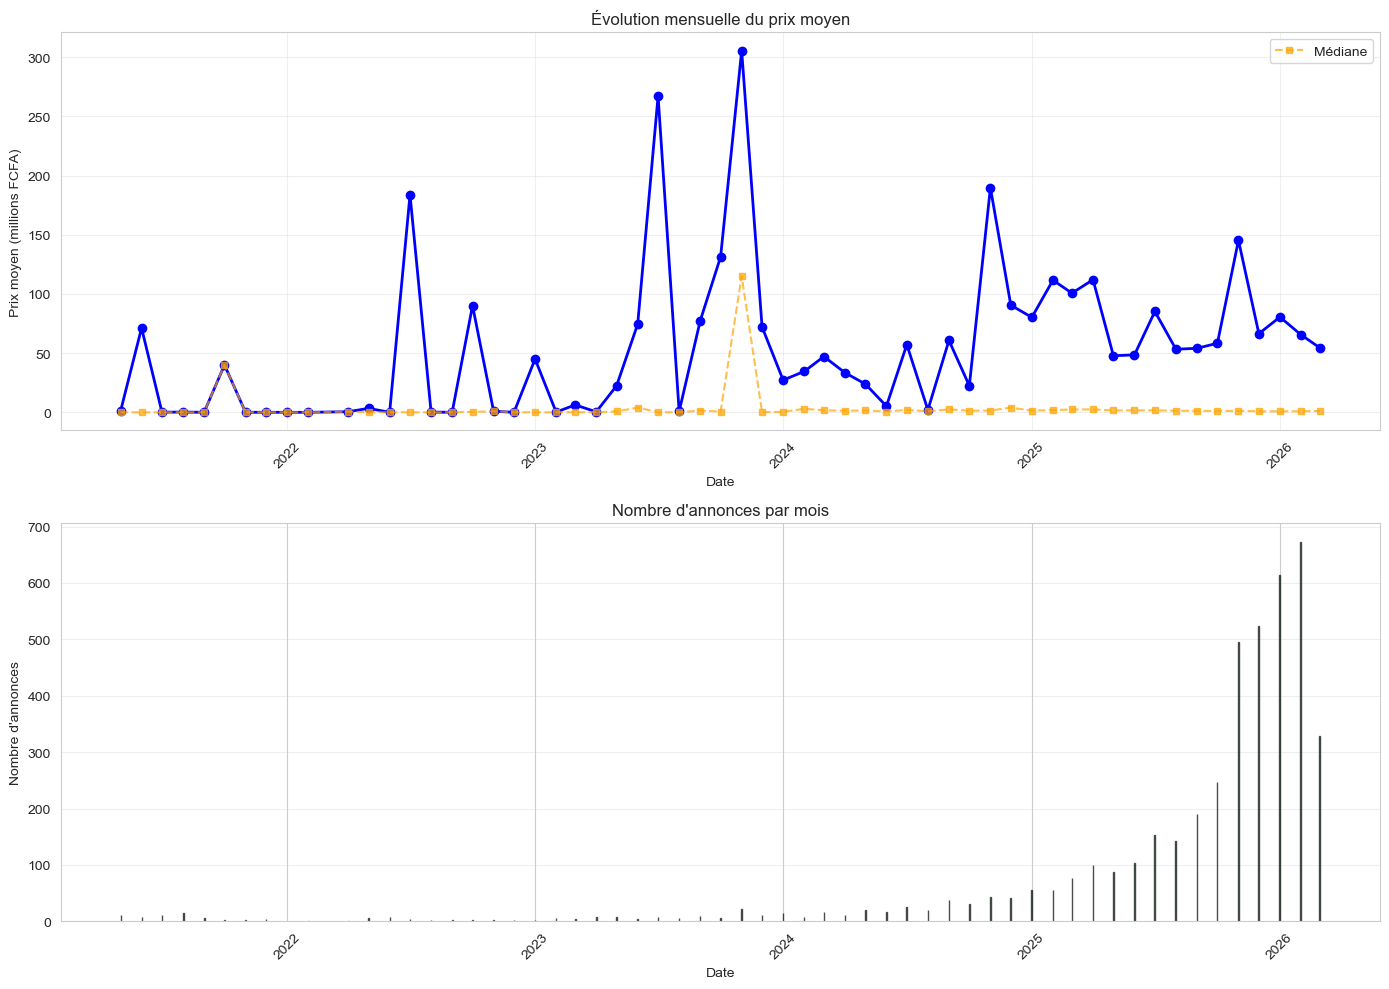


✅ Graphique sauvegardé : evolution_mensuelle_prix.png

📊 STATISTIQUES GLOBALES :
   Période couverte : 2021-05 à 2026-03
   Prix moyen sur la période : 54,346,980 FCFA
   Prix médian sur la période : 812,500 FCFA
   Mois avec le plus d'annonces : 2026-02 (672 annonces)

  Fin: 2026-03-13 02:20:50


In [52]:
# ============================================
# TÂCHE 1 — ÉVOLUTION MENSUELLE DES PRIX
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np

print("="*65)
print("  TÂCHE 1 — ÉVOLUTION MENSUELLE DES PRIX")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# Filtrer les annonces avec date et prix valides
df_evo = df.dropna(subset=['annee_pub', 'mois_pub', 'prix_fcfa'])
print(f"📊 {len(df_evo)} annonces avec date et prix renseignés")

# Créer une colonne date pour faciliter l'analyse
df_evo['date'] = pd.to_datetime(df_evo['annee_pub'].astype(int).astype(str) + '-' + 
                                 df_evo['mois_pub'].astype(int).astype(str) + '-01')

# Grouper par mois et calculer les statistiques
evolution_mensuelle = df_evo.groupby('date').agg({
    'prix_fcfa': ['mean', 'median', 'count', 'std']
}).round(0)

# Aplatir les colonnes
evolution_mensuelle.columns = ['prix_moyen', 'prix_median', 'nb_annonces', 'ecart_type']
evolution_mensuelle = evolution_mensuelle.sort_index()

print(f"\n📈 APERÇU DE L'ÉVOLUTION MENSUELLE (derniers mois) :")
print(evolution_mensuelle.tail(12).to_string())

# Sauvegarde en CSV
evolution_mensuelle.to_csv('evolution_mensuelle_prix.csv')
print(f"\n💾 Tableau sauvegardé : evolution_mensuelle_prix.csv")

# Création du graphique
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1: Évolution du prix moyen
axes[0].plot(evolution_mensuelle.index, evolution_mensuelle['prix_moyen'] / 1_000_000, 
             marker='o', linestyle='-', color='blue', linewidth=2, markersize=6)
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Prix moyen (millions FCFA)')
axes[0].set_title('Évolution mensuelle du prix moyen')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Ajouter la médiane en pointillés
axes[0].plot(evolution_mensuelle.index, evolution_mensuelle['prix_median'] / 1_000_000, 
             marker='s', linestyle='--', color='orange', linewidth=1.5, markersize=4, alpha=0.7, label='Médiane')
axes[0].legend()

# Graphique 2: Nombre d'annonces par mois
axes[1].bar(evolution_mensuelle.index, evolution_mensuelle['nb_annonces'], 
            color='lightgreen', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Date')
axes[1].set_ylabel("Nombre d'annonces")
axes[1].set_title('Nombre d\'annonces par mois')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('evolution_mensuelle_prix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphique sauvegardé : evolution_mensuelle_prix.png")

# Statistiques globales
print(f"\n📊 STATISTIQUES GLOBALES :")
print(f"   Période couverte : {evolution_mensuelle.index.min().strftime('%Y-%m')} à {evolution_mensuelle.index.max().strftime('%Y-%m')}")
print(f"   Prix moyen sur la période : {evolution_mensuelle['prix_moyen'].mean():,.0f} FCFA")
print(f"   Prix médian sur la période : {evolution_mensuelle['prix_median'].median():,.0f} FCFA")
print(f"   Mois avec le plus d'annonces : {evolution_mensuelle['nb_annonces'].idxmax().strftime('%Y-%m')} ({evolution_mensuelle['nb_annonces'].max()} annonces)")

print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# - TÂCHE 2 — Étudier les variations saisonnières

  TÂCHE 2 — VARIATIONS SAISONNIÈRES DES PRIX
  Démarrage: 2026-03-13 02:21:25

📂 4313 annonces chargées
📊 4310 annonces avec mois et prix renseignés

📊 STATISTIQUES PAR MOIS :
 mois_nom  prix_moyen  prix_median  nb_annonces
  Janvier  79100450.0     800000.0          689
  Février  68157292.0    1000000.0          741
     Mars  61918430.0    1300000.0          425
    Avril  96295650.0    1700000.0          119
      Mai  36763925.0    1500000.0          133
     Juin  43165714.0    1200000.0          139
  Juillet  84788186.0    1500000.0          202
     Août  41356076.0    1000000.0          184
Septembre  54420892.0    1300000.0          244
  Octobre  55946507.0    1100000.0          288
 Novembre 153699329.0    1250000.0          564
 Décembre  67562475.0     900000.0          582

💾 Tableau sauvegardé : variations_saisonnieres.csv


C:\Users\Dell\AppData\Local\Temp\ipykernel_9100\508496165.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_saison['mois_nom'] = df_saison['mois_pub'].map(mois_fr)


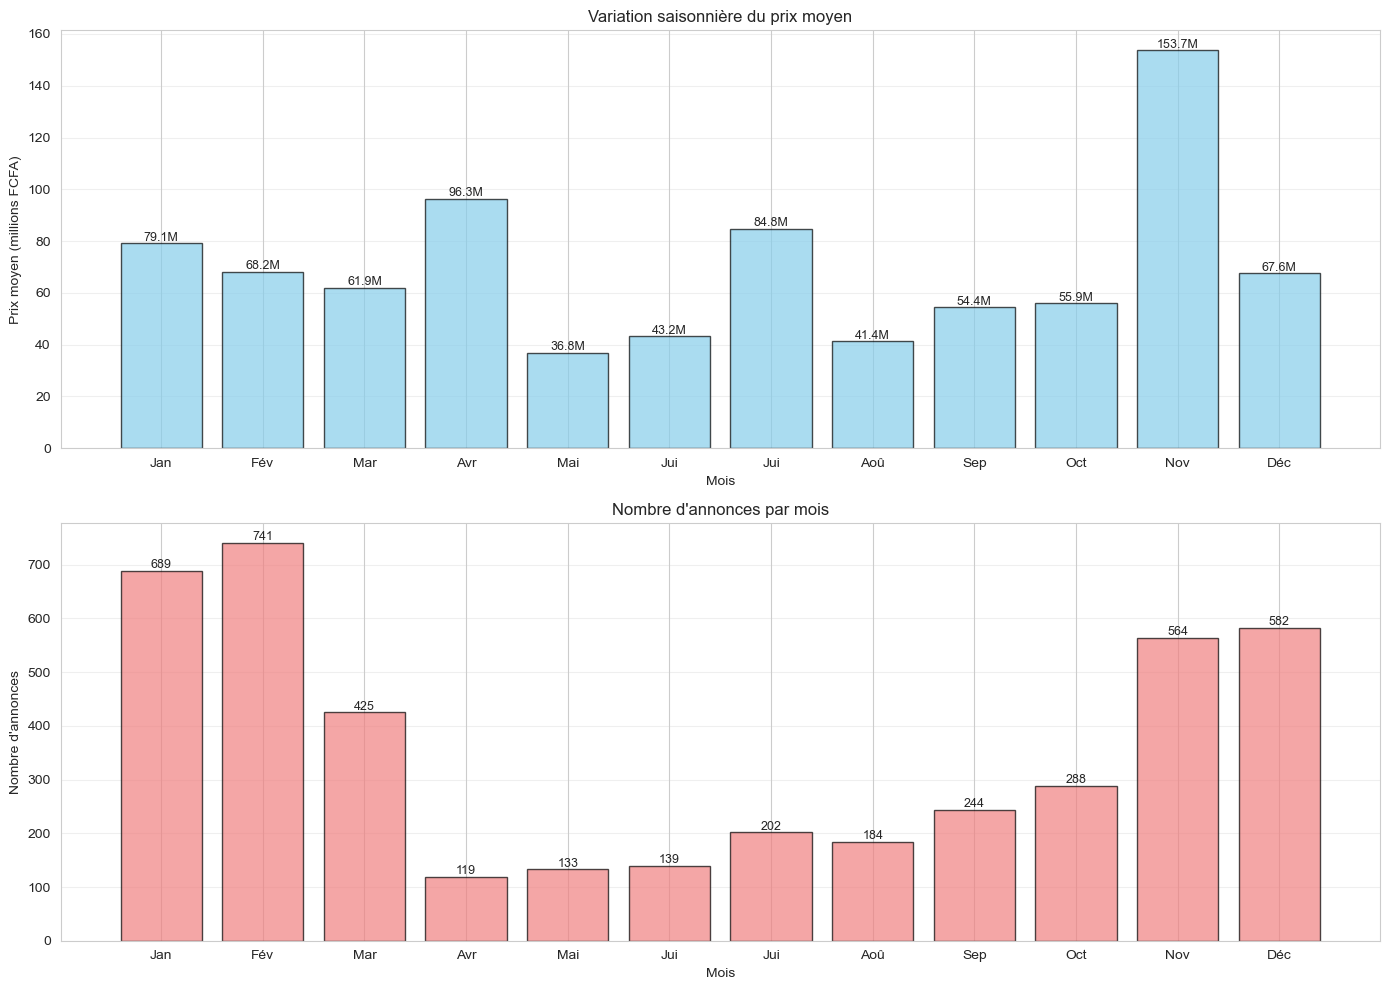


✅ Graphique sauvegardé : variations_saisonnieres.png

📈 ANALYSE DES TENDANCES SAISONNIÈRES :
   Mois avec le prix moyen le plus élevé : Novembre (153,699,329 FCFA)
   Mois avec le prix moyen le plus bas   : Mai (36,763,925 FCFA)
   Mois avec le plus d'annonces          : Février (741 annonces)
   Mois avec le moins d'annonces         : Avril (119 annonces)

  Fin: 2026-03-13 02:21:27


In [53]:
# ============================================
# TÂCHE 2 — VARIATIONS SAISONNIÈRES DES PRIX
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print("="*65)
print("  TÂCHE 2 — VARIATIONS SAISONNIÈRES DES PRIX")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# Filtrer les annonces avec mois et prix valides
df_saison = df.dropna(subset=['mois_pub', 'prix_fcfa'])
print(f"📊 {len(df_saison)} annonces avec mois et prix renseignés")

# Dictionnaire des mois en français
mois_fr = {
    1: 'Janvier', 2: 'Février', 3: 'Mars', 4: 'Avril', 5: 'Mai', 6: 'Juin',
    7: 'Juillet', 8: 'Août', 9: 'Septembre', 10: 'Octobre', 11: 'Novembre', 12: 'Décembre'
}

# Ajouter une colonne mois en français
df_saison['mois_nom'] = df_saison['mois_pub'].map(mois_fr)

# Statistiques par mois
stats_mois = df_saison.groupby('mois_pub').agg({
    'prix_fcfa': ['mean', 'median', 'count', 'std']
}).round(0)

stats_mois.columns = ['prix_moyen', 'prix_median', 'nb_annonces', 'ecart_type']
stats_mois = stats_mois.sort_index()

# Ajouter les noms des mois
stats_mois['mois_nom'] = [mois_fr[i] for i in stats_mois.index]

print(f"\n📊 STATISTIQUES PAR MOIS :")
print("="*65)
print(stats_mois[['mois_nom', 'prix_moyen', 'prix_median', 'nb_annonces']].to_string(index=False))

# Sauvegarde en CSV
stats_mois.to_csv('variations_saisonnieres.csv')
print(f"\n💾 Tableau sauvegardé : variations_saisonnieres.csv")

# Création du graphique
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Graphique 1: Prix moyen par mois
bars1 = axes[0].bar(range(1, 13), stats_mois['prix_moyen'] / 1_000_000, 
                    color='skyblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Mois')
axes[0].set_ylabel('Prix moyen (millions FCFA)')
axes[0].set_title('Variation saisonnière du prix moyen')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels([mois_fr[i][:3] for i in range(1, 13)])
axes[0].grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for bar, val in zip(bars1, stats_mois['prix_moyen']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{val/1_000_000:.1f}M', ha='center', fontsize=9)

# Graphique 2: Nombre d'annonces par mois
bars2 = axes[1].bar(range(1, 13), stats_mois['nb_annonces'], 
                    color='lightcoral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Mois')
axes[1].set_ylabel("Nombre d'annonces")
axes[1].set_title('Nombre d\'annonces par mois')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels([mois_fr[i][:3] for i in range(1, 13)])
axes[1].grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for bar, val in zip(bars2, stats_mois['nb_annonces']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
                 str(val), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('variations_saisonnieres.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphique sauvegardé : variations_saisonnieres.png")

# Analyse des tendances
print(f"\n📈 ANALYSE DES TENDANCES SAISONNIÈRES :")
print(f"   Mois avec le prix moyen le plus élevé : {stats_mois.loc[stats_mois['prix_moyen'].idxmax(), 'mois_nom']} "
      f"({stats_mois['prix_moyen'].max():,.0f} FCFA)")
print(f"   Mois avec le prix moyen le plus bas   : {stats_mois.loc[stats_mois['prix_moyen'].idxmin(), 'mois_nom']} "
      f"({stats_mois['prix_moyen'].min():,.0f} FCFA)")
print(f"   Mois avec le plus d'annonces          : {stats_mois.loc[stats_mois['nb_annonces'].idxmax(), 'mois_nom']} "
      f"({stats_mois['nb_annonces'].max()} annonces)")
print(f"   Mois avec le moins d'annonces         : {stats_mois.loc[stats_mois['nb_annonces'].idxmin(), 'mois_nom']} "
      f"({stats_mois['nb_annonces'].min()} annonces)")

print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# - TÂCHE 3 — Analyser l'évolution par type de bien

  TÂCHE 3 — ÉVOLUTION PAR TYPE DE BIEN
  Démarrage: 2026-03-13 02:24:05

📂 4313 annonces chargées
✅ Conversions numériques effectuées
📊 4310 annonces avec type, date et prix renseignés

📊 APERÇU DE L'ÉVOLUTION PAR TYPE DE BIEN :
    annee type_simple   prix_moyen  prix_median  nb_annonces
0    2021       Autre      48319.0      25000.0           36
1    2021    Location     114031.0      12500.0           16
2    2021       Vente  110033333.0   12250000.0            6
3    2022       Autre      73738.0      30000.0           21
4    2022    Location     297688.0      15000.0            8
5    2022       Vente  341666667.0  270000000.0            3
6    2023       Autre      61294.0      25000.0           34
7    2023    Location     792367.0     275000.0           24
8    2023       Vente  337195455.0  160000000.0           33
9    2024       Autre     529039.0      35500.0           76
10   2024    Location    2366367.0    1500000.0          129
11   2024       Vente  234806424.0  120

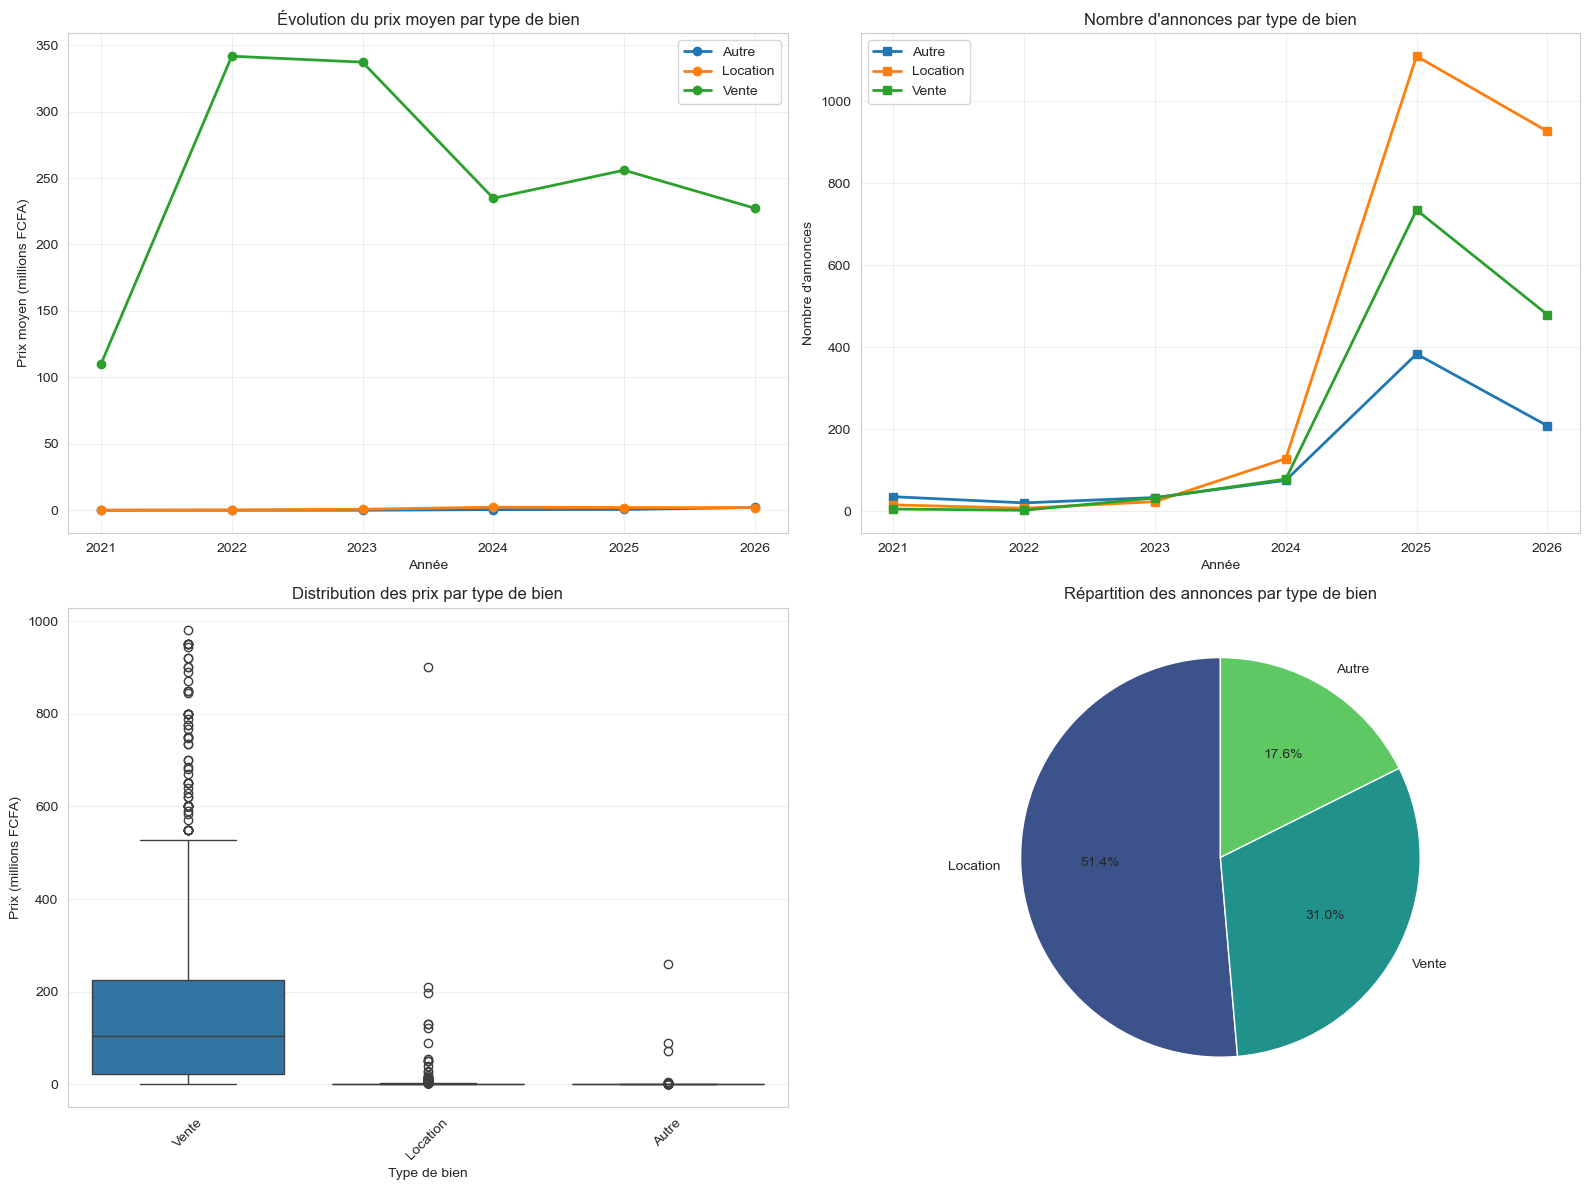


✅ Graphique sauvegardé : evolution_par_type_bien.png

📈 ANALYSE PAR TYPE DE BIEN :

   AUTRE :
      Nombre d'annonces : 760
      Prix moyen : 966,144 FCFA
      Prix médian : 45,000 FCFA
      Années couvertes : 2021 - 2026

   LOCATION :
      Nombre d'annonces : 2214
      Prix moyen : 2,040,822 FCFA
      Prix médian : 725,000 FCFA
      Années couvertes : 2021 - 2026

   VENTE :
      Nombre d'annonces : 1336
      Prix moyen : 245,922,209 FCFA
      Prix médian : 110,000,000 FCFA
      Années couvertes : 2021 - 2026

  Fin: 2026-03-13 02:24:08


In [55]:
# ============================================
# TÂCHE 3 — ÉVOLUTION PAR TYPE DE BIEN (CORRIGÉ)
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np

print("="*65)
print("  TÂCHE 3 — ÉVOLUTION PAR TYPE DE BIEN")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# ✅ CONVERSION DES COLONNES NUMÉRIQUES
# Convertir prix_fcfa en numérique (forcer les erreurs en NaN)
df['prix_fcfa'] = pd.to_numeric(df['prix_fcfa'], errors='coerce')

# Convertir les colonnes de dates en numérique
df['annee_pub'] = pd.to_numeric(df['annee_pub'], errors='coerce')
df['mois_pub'] = pd.to_numeric(df['mois_pub'], errors='coerce')
df['surface_m2'] = pd.to_numeric(df['surface_m2'], errors='coerce')

print("✅ Conversions numériques effectuées")

# Filtrer les annonces avec type, date et prix valides
df_type = df.dropna(subset=['categorie', 'annee_pub', 'prix_fcfa']).copy()  # .copy() pour éviter les warnings
print(f"📊 {len(df_type)} annonces avec type, date et prix renseignés")

# Créer une colonne année (entière)
df_type['annee'] = df_type['annee_pub'].astype(int)

# Catégories principales (simplifiées)
def categoriser_type(x):
    x_str = str(x).lower()
    if 'louer' in x_str or 'location' in x_str:
        return 'Location'
    elif 'vendre' in x_str or 'vente' in x_str:
        return 'Vente'
    elif 'terrain' in x_str:
        return 'Terrain'
    elif 'commercial' in x_str:
        return 'Commercial'
    else:
        return 'Autre'

df_type['type_simple'] = df_type['categorie'].apply(categoriser_type)

# Évolution par année et par type
evolution_type = df_type.groupby(['annee', 'type_simple']).agg({
    'prix_fcfa': ['mean', 'median', 'count']
}).round(0)

evolution_type.columns = ['prix_moyen', 'prix_median', 'nb_annonces']
evolution_type = evolution_type.reset_index()

print(f"\n📊 APERÇU DE L'ÉVOLUTION PAR TYPE DE BIEN :")
print(evolution_type.to_string())

# Sauvegarde en CSV
evolution_type.to_csv('evolution_par_type.csv', index=False)
print(f"\n💾 Tableau sauvegardé : evolution_par_type.csv")

# Création du graphique
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Évolution du prix moyen par type
types_uniques = evolution_type['type_simple'].unique()
for t in types_uniques:
    data = evolution_type[evolution_type['type_simple'] == t]
    if len(data) > 0:  # Vérifier qu'il y a des données
        axes[0, 0].plot(data['annee'], data['prix_moyen'] / 1_000_000, 
                        marker='o', label=t, linewidth=2)
axes[0, 0].set_xlabel('Année')
axes[0, 0].set_ylabel('Prix moyen (millions FCFA)')
axes[0, 0].set_title('Évolution du prix moyen par type de bien')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Nombre d'annonces par type et année
for t in types_uniques:
    data = evolution_type[evolution_type['type_simple'] == t]
    if len(data) > 0:
        axes[0, 1].plot(data['annee'], data['nb_annonces'], 
                        marker='s', label=t, linewidth=2)
axes[0, 1].set_xlabel('Année')
axes[0, 1].set_ylabel("Nombre d'annonces")
axes[0, 1].set_title('Nombre d\'annonces par type de bien')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Boxplot des prix par type (données globales)
# Filtrer les valeurs aberrantes pour le boxplot
df_boxplot = df_type[df_type['prix_fcfa'] < 1_000_000_000].copy()  # Exclure les prix > 1 milliard
sns.boxplot(data=df_boxplot, x='type_simple', y=df_boxplot['prix_fcfa'] / 1_000_000, ax=axes[1, 0])
axes[1, 0].set_xlabel('Type de bien')
axes[1, 0].set_ylabel('Prix (millions FCFA)')
axes[1, 0].set_title('Distribution des prix par type de bien')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 4. Répartition des types (pie chart)
type_counts = df_type['type_simple'].value_counts()
axes[1, 1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
               startangle=90, colors=sns.color_palette('viridis', len(type_counts)))
axes[1, 1].set_title('Répartition des annonces par type de bien')

plt.tight_layout()
plt.savefig('evolution_par_type_bien.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphique sauvegardé : evolution_par_type_bien.png")

# Analyse par type spécifique
print(f"\n📈 ANALYSE PAR TYPE DE BIEN :")
for t in types_uniques:
    data_type = df_type[df_type['type_simple'] == t]
    if len(data_type) > 0:
        print(f"\n   {t.upper()} :")
        print(f"      Nombre d'annonces : {len(data_type)}")
        print(f"      Prix moyen : {data_type['prix_fcfa'].mean():,.0f} FCFA")
        print(f"      Prix médian : {data_type['prix_fcfa'].median():,.0f} FCFA")
        print(f"      Années couvertes : {data_type['annee'].min():.0f} - {data_type['annee'].max():.0f}")

print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# - TÂCHE 4 — Calculer la corrélation surface/prix (graphique scatter)

  TÂCHE 4 — CORRÉLATION SURFACE / PRIX
  Démarrage: 2026-03-13 02:27:50

📂 4313 annonces chargées
✅ Conversions numériques effectuées
📊 1381 annonces avec surface et prix renseignés
📊 1320 annonces avec surface < 2000 m²

📊 ANALYSE DE CORRÉLATION :
   Corrélation de Pearson    : r = 0.368 (p-value = 1.156e-43)
   Corrélation de Spearman   : ρ = 0.293 (p-value = 1.756e-27)

   Interprétation : Corrélation modérée positive


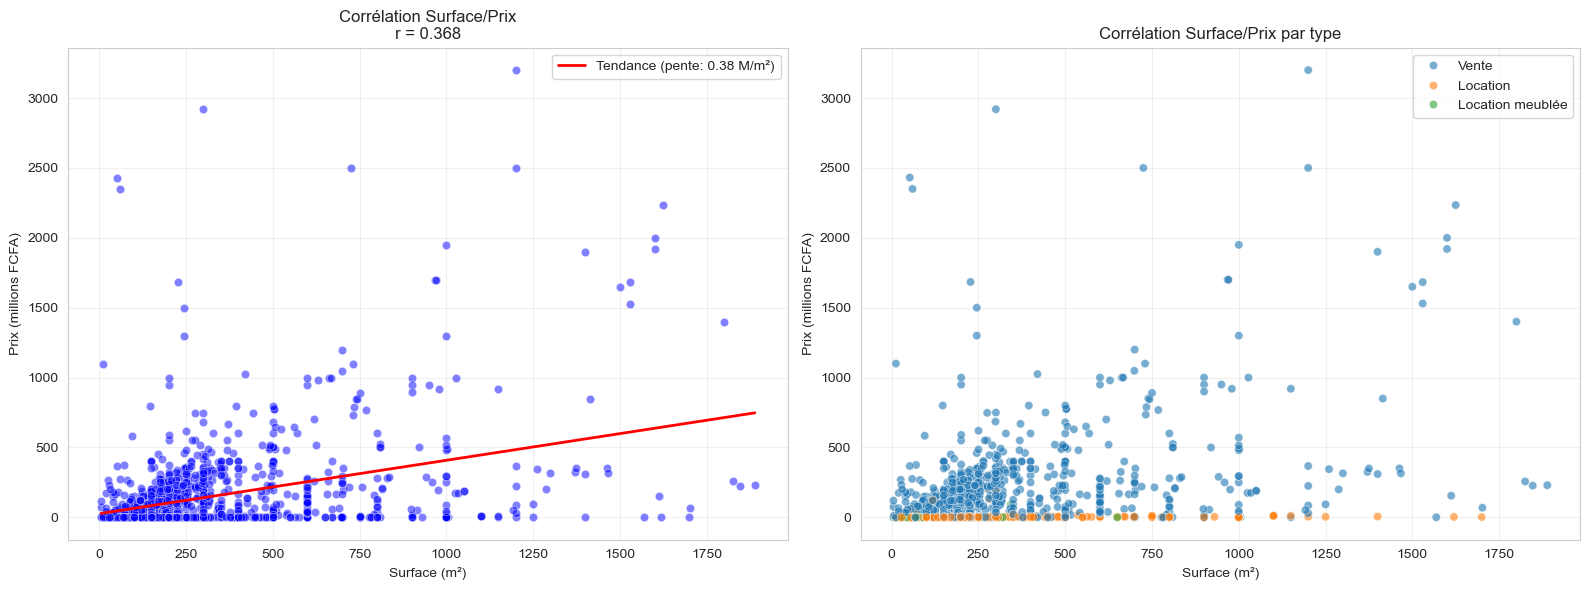


✅ Graphique sauvegardé : correlation_surface_prix.png

📊 ANALYSE PAR TRANCHE DE SURFACE :
                  prix_moyen  prix_median  nb_annonces  surface_moyenne
tranche_surface                                                        
<50               50126134.0     392500.0           62             25.0
50-100           106133311.0    1500000.0           89             79.0
100-200           78301936.0   30000000.0          447            163.0
200-500          146961503.0   40000000.0          505            315.0
500-1000         294378638.0  125000000.0          167            736.0
1000-2000        567557480.0  226000000.0           50           1342.0

💾 Tableau sauvegardé : statistiques_par_tranche_surface.csv

📊 PRIX AU M² PAR TRANCHE DE SURFACE :
   <50        : 2,005,045 FCFA/m² (62 annonces)
   50-100     : 1,343,460 FCFA/m² (89 annonces)
   100-200    : 480,380 FCFA/m² (447 annonces)
   200-500    : 466,544 FCFA/m² (505 annonces)
   500-1000   : 399,971 FCFA/m² (167 annonc

C:\Users\Dell\AppData\Local\Temp\ipykernel_9100\3495302933.py:99: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats_surface = df_corr_filtre.groupby('tranche_surface').agg({


In [57]:
# ============================================
# TÂCHE 4 — CORRÉLATION SURFACE / PRIX (CORRIGÉ)
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy import stats

print("="*65)
print("  TÂCHE 4 — CORRÉLATION SURFACE / PRIX")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# ✅ CONVERSION DES COLONNES NUMÉRIQUES
df['prix_fcfa'] = pd.to_numeric(df['prix_fcfa'], errors='coerce')
df['surface_m2'] = pd.to_numeric(df['surface_m2'], errors='coerce')
print("✅ Conversions numériques effectuées")

# Filtrer les annonces avec surface et prix valides
df_corr = df.dropna(subset=['surface_m2', 'prix_fcfa']).copy()
print(f"📊 {len(df_corr)} annonces avec surface et prix renseignés")

# Filtrer les valeurs aberrantes (surface < 2000 m² pour plus de lisibilité)
df_corr_filtre = df_corr[df_corr['surface_m2'] < 2000].copy()
print(f"📊 {len(df_corr_filtre)} annonces avec surface < 2000 m²")

# Calcul de la corrélation
correlation, p_value = stats.pearsonr(df_corr_filtre['surface_m2'], df_corr_filtre['prix_fcfa'])
correlation_spearman, p_value_spearman = stats.spearmanr(df_corr_filtre['surface_m2'], df_corr_filtre['prix_fcfa'])

print(f"\n📊 ANALYSE DE CORRÉLATION :")
print(f"   Corrélation de Pearson    : r = {correlation:.3f} (p-value = {p_value:.3e})")
print(f"   Corrélation de Spearman   : ρ = {correlation_spearman:.3f} (p-value = {p_value_spearman:.3e})")

# Interprétation
if abs(correlation) < 0.3:
    interpretation = "Faible corrélation"
elif abs(correlation) < 0.7:
    interpretation = "Corrélation modérée"
else:
    interpretation = "Forte corrélation"

print(f"\n   Interprétation : {interpretation} {'positive' if correlation > 0 else 'negative'}")

# Création du graphique
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scatter plot simple
# ✅ Utiliser les valeurs directement (déjà converties en numérique)
sns.scatterplot(data=df_corr_filtre, x='surface_m2', y=df_corr_filtre['prix_fcfa'] / 1_000_000, 
                alpha=0.5, color='blue', ax=axes[0])
axes[0].set_xlabel('Surface (m²)')
axes[0].set_ylabel('Prix (millions FCFA)')
axes[0].set_title(f'Corrélation Surface/Prix\nr = {correlation:.3f}')
axes[0].grid(True, alpha=0.3)

# Ajouter une ligne de régression
z = np.polyfit(df_corr_filtre['surface_m2'], df_corr_filtre['prix_fcfa'], 1)
p = np.poly1d(z)
axes[0].plot(df_corr_filtre['surface_m2'].sort_values(), 
             p(df_corr_filtre['surface_m2'].sort_values()) / 1_000_000, 
             "r-", linewidth=2, label=f'Tendance (pente: {z[0]/1_000_000:.2f} M/m²)')
axes[0].legend()

# 2. Scatter plot avec distinction par type d'opération
if 'type_operation' in df_corr_filtre.columns:
    sns.scatterplot(data=df_corr_filtre, x='surface_m2', y=df_corr_filtre['prix_fcfa'] / 1_000_000, 
                    hue='type_operation', alpha=0.6, ax=axes[1])
else:
    sns.scatterplot(data=df_corr_filtre, x='surface_m2', y=df_corr_filtre['prix_fcfa'] / 1_000_000, 
                    alpha=0.6, color='green', ax=axes[1])
axes[1].set_xlabel('Surface (m²)')
axes[1].set_ylabel('Prix (millions FCFA)')
axes[1].set_title('Corrélation Surface/Prix par type')
axes[1].grid(True, alpha=0.3)
if 'type_operation' in df_corr_filtre.columns:
    axes[1].legend()

plt.tight_layout()
plt.savefig('correlation_surface_prix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphique sauvegardé : correlation_surface_prix.png")

# Analyse par tranches de surface
print(f"\n📊 ANALYSE PAR TRANCHE DE SURFACE :")
df_corr_filtre['tranche_surface'] = pd.cut(df_corr_filtre['surface_m2'], 
                                            bins=[0, 50, 100, 200, 500, 1000, 2000],
                                            labels=['<50', '50-100', '100-200', '200-500', '500-1000', '1000-2000'])

stats_surface = df_corr_filtre.groupby('tranche_surface').agg({
    'prix_fcfa': ['mean', 'median', 'count'],
    'surface_m2': 'mean'
}).round(0)

stats_surface.columns = ['prix_moyen', 'prix_median', 'nb_annonces', 'surface_moyenne']
print(stats_surface.to_string())

# Sauvegarde en CSV
stats_surface.to_csv('statistiques_par_tranche_surface.csv')
print(f"\n💾 Tableau sauvegardé : statistiques_par_tranche_surface.csv")

# Prix au m² par tranche
print(f"\n📊 PRIX AU M² PAR TRANCHE DE SURFACE :")
for tranche in stats_surface.index:
    prix_m2 = stats_surface.loc[tranche, 'prix_moyen'] / stats_surface.loc[tranche, 'surface_moyenne']
    print(f"   {tranche:<10} : {prix_m2:,.0f} FCFA/m² ({stats_surface.loc[tranche, 'nb_annonces']} annonces)")

print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

## Tâches de FATOU FALL
# Calculer la corrélation pièces/prix (box plot)
# Créer une matrice de corrélation
# Créer le notebook "01_import_nettoyage.ipynb"
# Créer le notebook "02_analyse_prix.ipynb"

# - TÂCHE 1 — Calculer la corrélation pièces/prix (box plot)

  TÂCHE 1 — CORRÉLATION PIÈCES/PRIX (BOX PLOT)
  Démarrage: 2026-03-13 02:30:50

📂 4313 annonces chargées
✅ Conversions numériques effectuées
📊 2580 annonces avec chambres et prix renseignés
📊 2567 annonces après filtrage (prix < 1Mrd, chambres ≤ 10)

📊 STATISTIQUES PAR NOMBRE DE CHAMBRES :
              prix_moyen  prix_median  nb_annonces   ecart_type
nb_chambres                                                    
1.0           24629509.0     600000.0          237   68178571.0
2.0           26747448.0     450000.0          649   73902501.0
3.0           40956836.0    1100000.0         1129  105386839.0
4.0           69438845.0    1800000.0          346  146171408.0
5.0           91966677.0    2500000.0          130  180757151.0
6.0           59672246.0    1549750.0           46  166355035.0
7.0          169081579.0  223000000.0           19  169101474.0
8.0          183114286.0  120000000.0            7  225576686.0
9.0          200750000.0  200750000.0            2  281782052.0
10.0

C:\Users\Dell\AppData\Local\Temp\ipykernel_9100\4178840823.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_pieces_filtre, x='nb_chambres', y=df_pieces_filtre['prix_fcfa'] / 1_000_000,
C:\Users\Dell\AppData\Local\Temp\ipykernel_9100\4178840823.py:78: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(data=df_pieces_filtre, x='nb_chambres', y=df_pieces_filtre['prix_fcfa'] / 1_000_000,


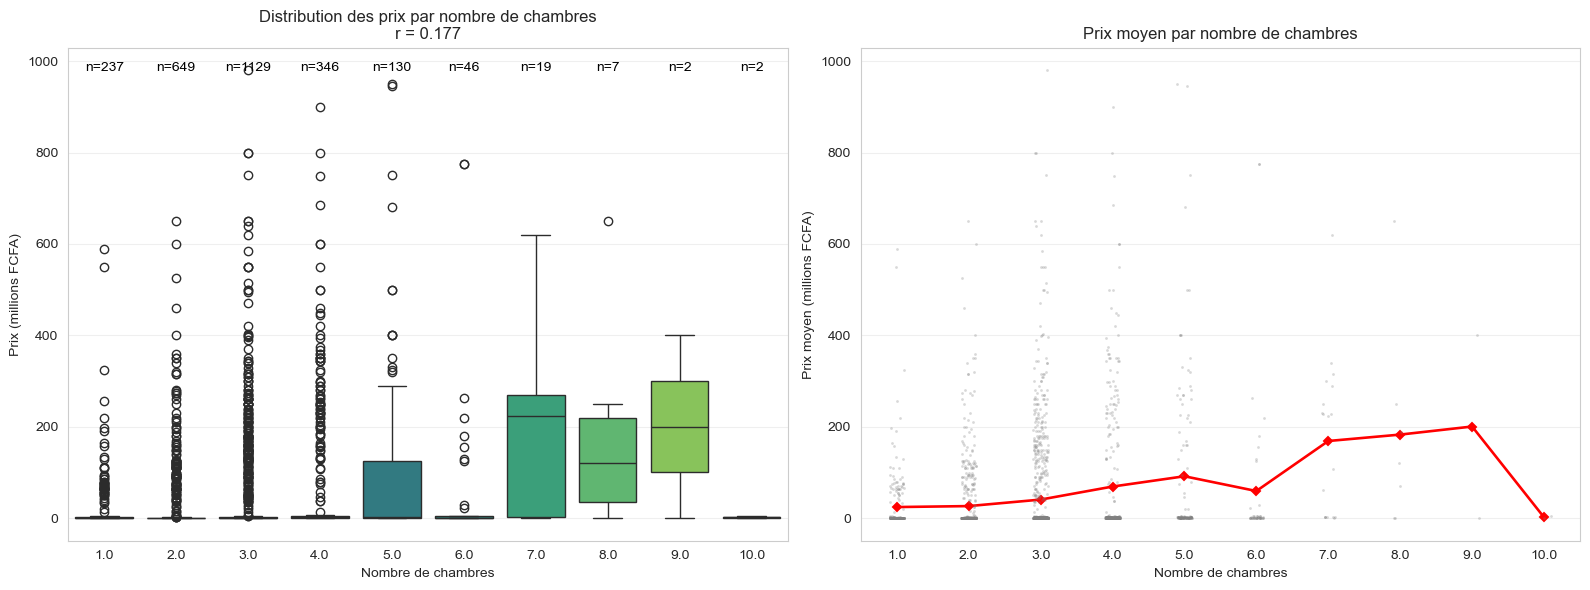


✅ Graphique sauvegardé : correlation_pieces_prix.png


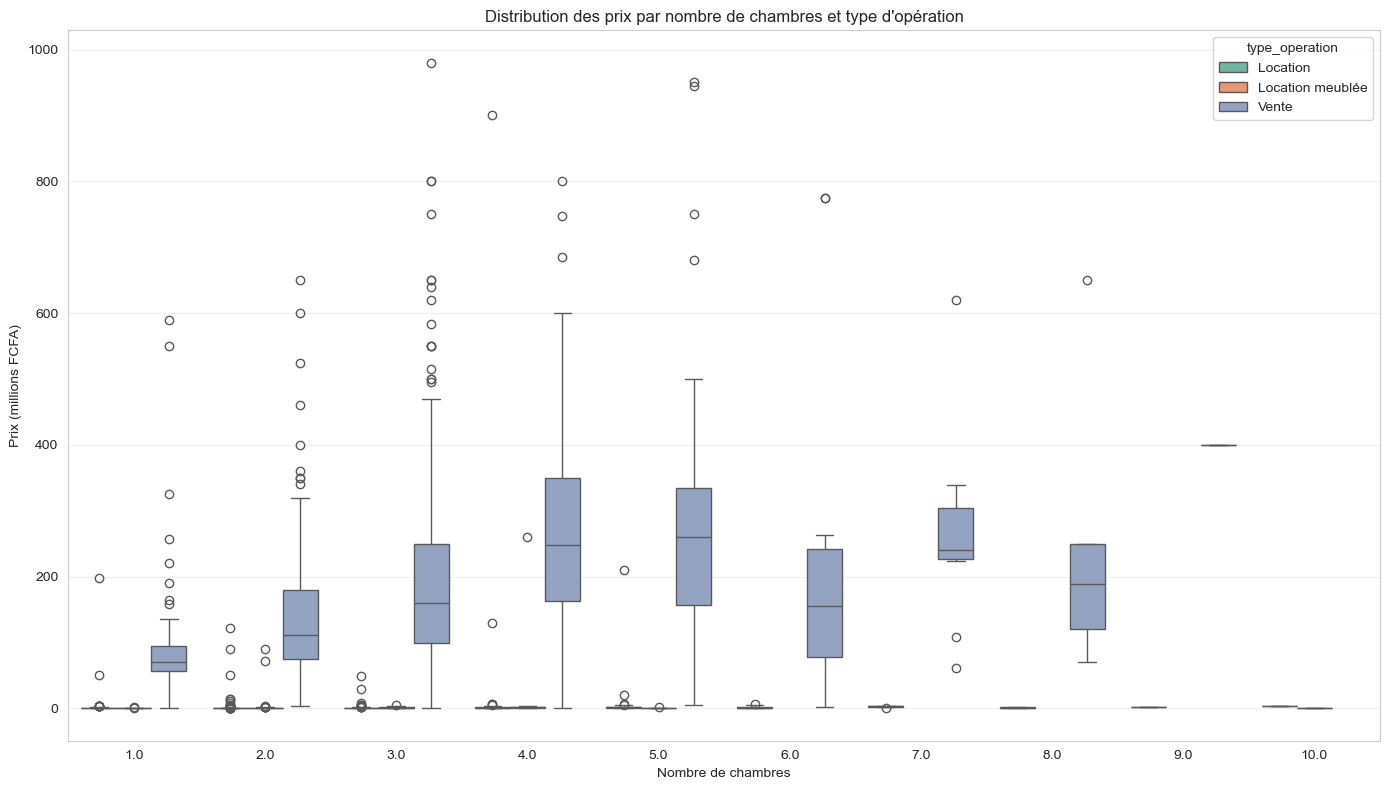

✅ Graphique sauvegardé : correlation_pieces_prix_par_type.png

📈 INTERPRÉTATION :
   - La corrélation de 0.177 indique une corrélation faible positive.
   - Le prix augmente généralement avec le nombre de chambres.
   - La forte variance dans chaque catégorie suggère d'autres facteurs influençant le prix (emplacement, surface, standing).

  Fin: 2026-03-13 02:30:54


In [58]:
# ============================================
# TÂCHE 1 — CORRÉLATION PIÈCES/PRIX (BOX PLOT)
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime
from scipy import stats

print("="*65)
print("  TÂCHE 1 — CORRÉLATION PIÈCES/PRIX (BOX PLOT)")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# Conversion numérique
df['prix_fcfa'] = pd.to_numeric(df['prix_fcfa'], errors='coerce')
df['nb_chambres'] = pd.to_numeric(df['nb_chambres'], errors='coerce')
print("✅ Conversions numériques effectuées")

# Filtrer les annonces avec chambres et prix valides
df_pieces = df.dropna(subset=['nb_chambres', 'prix_fcfa']).copy()
print(f"📊 {len(df_pieces)} annonces avec chambres et prix renseignés")

# Filtrer les valeurs aberrantes pour le box plot
df_pieces_filtre = df_pieces[df_pieces['prix_fcfa'] < 1_000_000_000].copy()
df_pieces_filtre = df_pieces_filtre[df_pieces_filtre['nb_chambres'] <= 10].copy()  # Limiter à 10 chambres max
print(f"📊 {len(df_pieces_filtre)} annonces après filtrage (prix < 1Mrd, chambres ≤ 10)")

# Statistiques par nombre de chambres
stats_chambres = df_pieces_filtre.groupby('nb_chambres').agg({
    'prix_fcfa': ['mean', 'median', 'count', 'std']
}).round(0)

stats_chambres.columns = ['prix_moyen', 'prix_median', 'nb_annonces', 'ecart_type']
stats_chambres = stats_chambres.sort_index()

print(f"\n📊 STATISTIQUES PAR NOMBRE DE CHAMBRES :")
print(stats_chambres.to_string())

# Sauvegarde en CSV
stats_chambres.to_csv('statistiques_par_nb_chambres.csv')
print(f"\n💾 Tableau sauvegardé : statistiques_par_nb_chambres.csv")

# Calcul de corrélation
correlation, p_value = stats.pearsonr(df_pieces_filtre['nb_chambres'], df_pieces_filtre['prix_fcfa'])
correlation_spearman, p_value_spearman = stats.spearmanr(df_pieces_filtre['nb_chambres'], df_pieces_filtre['prix_fcfa'])

print(f"\n📊 ANALYSE DE CORRÉLATION :")
print(f"   Corrélation de Pearson    : r = {correlation:.3f} (p-value = {p_value:.3e})")
print(f"   Corrélation de Spearman   : ρ = {correlation_spearman:.3f} (p-value = {p_value_spearman:.3e})")

# Création du graphique
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Box plot
sns.boxplot(data=df_pieces_filtre, x='nb_chambres', y=df_pieces_filtre['prix_fcfa'] / 1_000_000, 
            palette='viridis', ax=axes[0])
axes[0].set_xlabel('Nombre de chambres')
axes[0].set_ylabel('Prix (millions FCFA)')
axes[0].set_title(f'Distribution des prix par nombre de chambres\nr = {correlation:.3f}')
axes[0].grid(True, alpha=0.3, axis='y')

# Ajouter le nombre d'annonces sur le box plot
for i, nb in enumerate(stats_chambres['nb_annonces'].values):
    axes[0].text(i, axes[0].get_ylim()[1] * 0.95, f'n={int(nb)}', 
                 ha='center', fontsize=10, color='black')

# 2. Scatter plot avec jitter
sns.stripplot(data=df_pieces_filtre, x='nb_chambres', y=df_pieces_filtre['prix_fcfa'] / 1_000_000, 
              alpha=0.3, color='gray', size=2, ax=axes[1])
sns.pointplot(data=df_pieces_filtre, x='nb_chambres', y=df_pieces_filtre['prix_fcfa'] / 1_000_000, 
              color='red', markers='D', scale=0.7, errorbar=None, ax=axes[1])
axes[1].set_xlabel('Nombre de chambres')
axes[1].set_ylabel('Prix moyen (millions FCFA)')
axes[1].set_title('Prix moyen par nombre de chambres')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('correlation_pieces_prix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphique sauvegardé : correlation_pieces_prix.png")

# Analyse par type d'opération (optionnel)
if 'type_operation' in df_pieces_filtre.columns:
    fig, ax = plt.subplots(figsize=(14, 8))
    sns.boxplot(data=df_pieces_filtre, x='nb_chambres', y=df_pieces_filtre['prix_fcfa'] / 1_000_000, 
                hue='type_operation', palette='Set2', ax=ax)
    ax.set_xlabel('Nombre de chambres')
    ax.set_ylabel('Prix (millions FCFA)')
    ax.set_title('Distribution des prix par nombre de chambres et type d\'opération')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('correlation_pieces_prix_par_type.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✅ Graphique sauvegardé : correlation_pieces_prix_par_type.png")

# Interprétation
print(f"\n📈 INTERPRÉTATION :")
print(f"   - La corrélation de {correlation:.3f} indique une corrélation {'forte' if abs(correlation) > 0.7 else 'modérée' if abs(correlation) > 0.3 else 'faible'} positive.")
print(f"   - Le prix augmente généralement avec le nombre de chambres.")
print(f"   - La forte variance dans chaque catégorie suggère d'autres facteurs influençant le prix (emplacement, surface, standing).")

print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# - TÂCHE 2 — Créer une matrice de corrélation

  TÂCHE 2 — MATRICE DE CORRÉLATION
  Démarrage: 2026-03-13 02:31:55

📂 4313 annonces chargées
✅ Conversions numériques effectuées
📊 290 annonces avec toutes les variables numériques

📊 MATRICE DE CORRÉLATION :
             prix_fcfa  surface_m2  nb_chambres  nb_salons  nb_sdb  annee_pub  mois_pub
prix_fcfa        1.000       0.279        0.184     -0.030   0.140      0.083    -0.036
surface_m2       0.279       1.000        0.280     -0.006   0.076     -0.023     0.022
nb_chambres      0.184       0.280        1.000      0.042   0.449     -0.088     0.043
nb_salons       -0.030      -0.006        0.042      1.000  -0.030     -0.116     0.045
nb_sdb           0.140       0.076        0.449     -0.030   1.000      0.043    -0.062
annee_pub        0.083      -0.023       -0.088     -0.116   0.043      1.000    -0.677
mois_pub        -0.036       0.022        0.043      0.045  -0.062     -0.677     1.000

💾 Tableau sauvegardé : matrice_correlation.csv


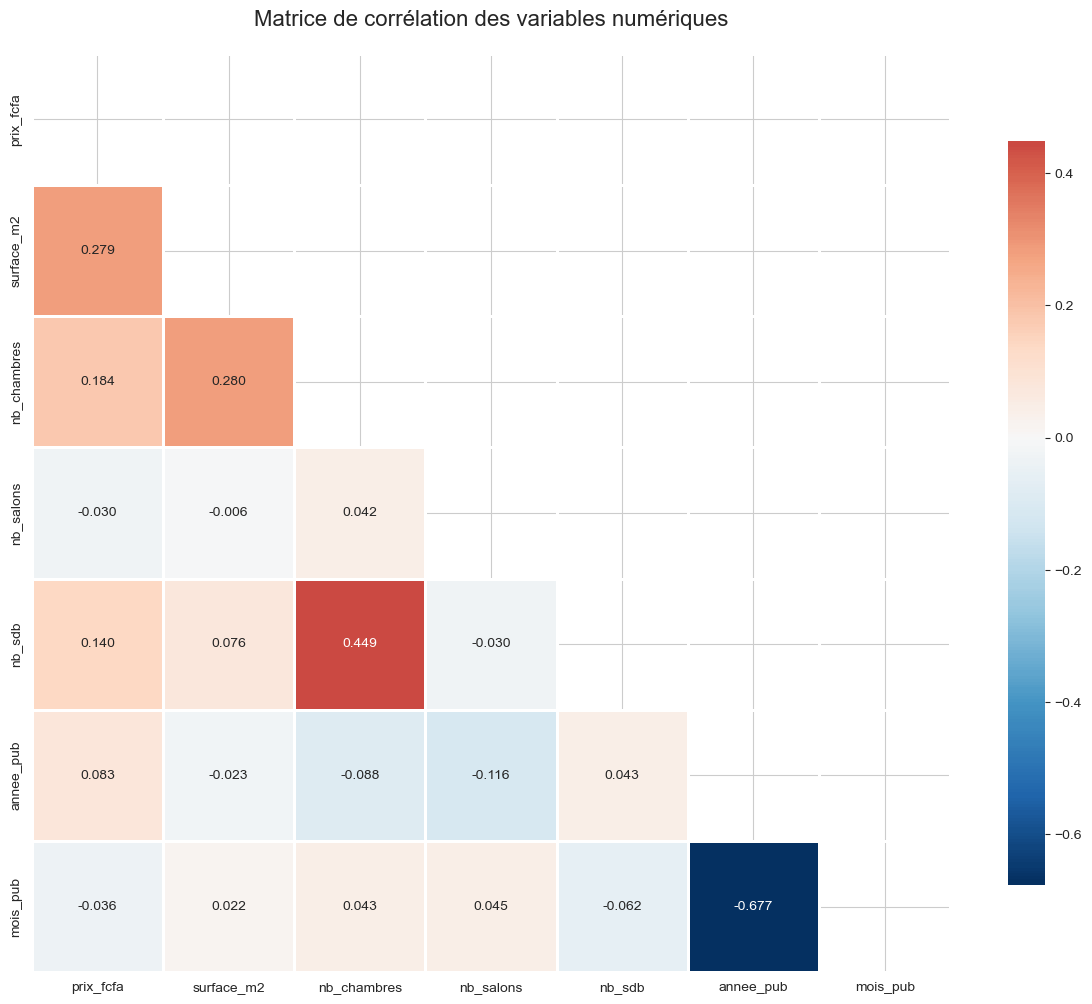


✅ Graphique sauvegardé : matrice_correlation.png


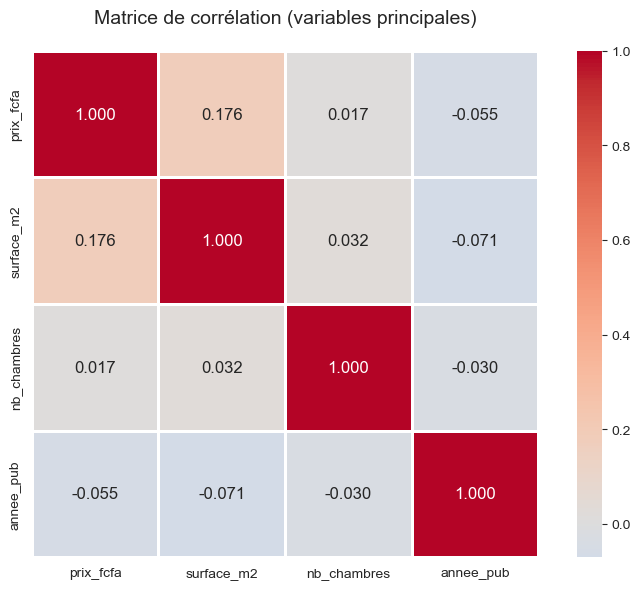

✅ Graphique sauvegardé : matrice_correlation_principale.png

📈 INTERPRÉTATION DES CORRÉLATIONS :
   - annee_pub ↔ mois_pub : -0.677 (modérée corrélation négative)
   - nb_chambres ↔ nb_sdb : 0.449 (modérée corrélation positive)

  Fin: 2026-03-13 02:31:57


In [59]:
# ============================================
# TÂCHE 2 — MATRICE DE CORRÉLATION
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

print("="*65)
print("  TÂCHE 2 — MATRICE DE CORRÉLATION")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# Conversion numérique des colonnes pertinentes
colonnes_numeriques = ['prix_fcfa', 'surface_m2', 'nb_chambres', 'nb_salons', 'nb_sdb', 'annee_pub', 'mois_pub']
for col in colonnes_numeriques:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
print("✅ Conversions numériques effectuées")

# Sélectionner les colonnes pour la matrice
colonnes_correlation = [col for col in colonnes_numeriques if col in df.columns]
df_corr = df[colonnes_correlation].dropna().copy()
print(f"📊 {len(df_corr)} annonces avec toutes les variables numériques")

# Calculer la matrice de corrélation
matrice_corr = df_corr.corr()

print(f"\n📊 MATRICE DE CORRÉLATION :")
print(matrice_corr.round(3).to_string())

# Sauvegarde en CSV
matrice_corr.to_csv('matrice_correlation.csv')
print(f"\n💾 Tableau sauvegardé : matrice_correlation.csv")

# Création de la heatmap
plt.figure(figsize=(12, 10))

# Masque pour la partie supérieure de la matrice
mask = np.triu(np.ones_like(matrice_corr, dtype=bool))

# Heatmap
sns.heatmap(matrice_corr, 
            mask=mask,
            annot=True, 
            fmt='.3f', 
            cmap='RdBu_r',
            center=0,
            square=True,
            linewidths=1,
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 10})

plt.title('Matrice de corrélation des variables numériques', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('matrice_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphique sauvegardé : matrice_correlation.png")

# Version avec seulement les colonnes les plus pertinentes (optionnel)
colonnes_principales = ['prix_fcfa', 'surface_m2', 'nb_chambres', 'annee_pub']
df_principales = df[colonnes_principales].dropna().copy()
matrice_principales = df_principales.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(matrice_principales, 
            annot=True, 
            fmt='.3f', 
            cmap='coolwarm',
            center=0,
            square=True,
            linewidths=1,
            annot_kws={"size": 12})
plt.title('Matrice de corrélation (variables principales)', fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('matrice_correlation_principale.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Graphique sauvegardé : matrice_correlation_principale.png")

# Interprétation des corrélations
print(f"\n📈 INTERPRÉTATION DES CORRÉLATIONS :")
corr_paires = []

for i in range(len(matrice_corr.columns)):
    for j in range(i+1, len(matrice_corr.columns)):
        col1 = matrice_corr.columns[i]
        col2 = matrice_corr.columns[j]
        val = matrice_corr.iloc[i, j]
        if abs(val) > 0.3:  # Corrélations significatives
            corr_paires.append((col1, col2, val))

corr_paires.sort(key=lambda x: abs(x[2]), reverse=True)

for col1, col2, val in corr_paires:
    intensite = "forte" if abs(val) > 0.7 else "modérée"
    signe = "positive" if val > 0 else "négative"
    print(f"   - {col1} ↔ {col2} : {val:.3f} ({intensite} corrélation {signe})")

print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# - TÂCHE 3 — Créer le notebook "01_import_nettoyage.ipynb"

# NOTEBOOK 01 — IMPORT ET NETTOYAGE DES DONNÉES

## Objectif
Ce notebook documente toutes les étapes d'importation et de nettoyage des données immobilières scrapées depuis Expat-Dakar.

## 1. Import des librairies
```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import json
import os
import re

# - 2. Chargement des données brutes

In [60]:
# Chargement du fichier brut produit par Gora Diallo
df_brut = pd.read_csv("expat_dakar_brut.csv", encoding='utf-8-sig')
print(f"Nombre d'annonces brutes : {len(df_brut)}")
print(f"Colonnes : {list(df_brut.columns)}")

Nombre d'annonces brutes : 4398
Colonnes : ['id', 'titre', 'categorie', 'type_operation', 'prix_xof', 'devise', 'description', 'date_pub_brute', 'url', 'image_url', 'page_source', 'date_scraping']


# - 3. Enrichissement des données (Dieynaba Ba)

In [62]:
# Extraction de la localisation, surface, pièces, dates
df_enrichi = pd.read_csv("expat_dakar_enrichi.csv", encoding='utf-8-sig')
print(f"Nombre d'annonces enrichies : {len(df_enrichi)}")
print(f"Nouvelles colonnes : quartier, ville, surface_m2, nb_chambres, nb_salons, nb_sdb")

Nombre d'annonces enrichies : 4398
Nouvelles colonnes : quartier, ville, surface_m2, nb_chambres, nb_salons, nb_sdb


# - 4. Nettoyage des prix (Fatou Fall - Tâche 1)

In [63]:
# Conversion et nettoyage des prix
df_prix = pd.read_csv("expat_dakar_prix_nettoyes.csv", encoding='utf-8-sig')
print(f"Prix valides : {df_prix['prix_fcfa'].notna().sum()} / {len(df_prix)}")
print(f"Prix manquants : {df_prix['prix_fcfa'].isna().sum()}")

Prix valides : 4313 / 4398
Prix manquants : 85


# - 5. Traitement des valeurs manquantes (Fatou Fall - Tâches 2-4)

In [64]:
# Suppression des prix manquants
df_clean = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"Total annonces final : {len(df_clean)}")
print(f"Taux de couverture - surface : {df_clean['surface_m2'].notna().mean():.1%}")
print(f"Taux de couverture - chambres : {df_clean['nb_chambres'].notna().mean():.1%}")

Total annonces final : 4313
Taux de couverture - surface : 32.0%
Taux de couverture - chambres : 59.8%


# - 6. Résumé du nettoyage
Étape	           Fichier	Nb                                annonces	                   Actions
Brut	           expat_dakar_brut.csv	                       4 398	                   Scraping initial
Enrichi	           expat_dakar_enrichi.csv	                   4 398	                   Ajout localisation, surface, pièces
Prix nettoyés	   expat_dakar_prix_nettoyes.csv	           4 398	                   Correction prix, tranches
Final	           expat_dakar_pieces_traite.csv	           4 313	                   Suppression 85 prix manquants

# - 7. Statistiques descriptives finales

In [65]:
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')

print("=== STATISTIQUES DESCRIPTIVES ===")
print(f"Prix moyen : {df['prix_fcfa'].mean():,.0f} FCFA")
print(f"Prix médian : {df['prix_fcfa'].median():,.0f} FCFA")
print(f"Surface moyenne : {df['surface_m2'].mean():.0f} m²")
print(f"Nombre moyen de chambres : {df['nb_chambres'].mean():.1f}")
print(f"Période couverte : {df['annee_pub'].min():.0f} - {df['annee_pub'].max():.0f}")

=== STATISTIQUES DESCRIPTIVES ===
Prix moyen : 77,451,639 FCFA
Prix médian : 1,000,000 FCFA
Surface moyenne : 525 m²
Nombre moyen de chambres : 3.0
Période couverte : 2021 - 2026



---

### **TÂCHE 4 — Créer le notebook "02_analyse_prix.ipynb"**

```markdown
# NOTEBOOK 02 — ANALYSE DES PRIX IMMOBILIERS

## Objectif
Ce notebook présente les analyses statistiques et graphiques des prix immobiliers à Dakar et au Sénégal.

## 1. Import des librairies
```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import scipy.stats as stats

# - 2. Chargement des données nettoyées

In [66]:
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"Nombre d'annonces : {len(df)}")

Nombre d'annonces : 4313


# - 3. Distribution des prix

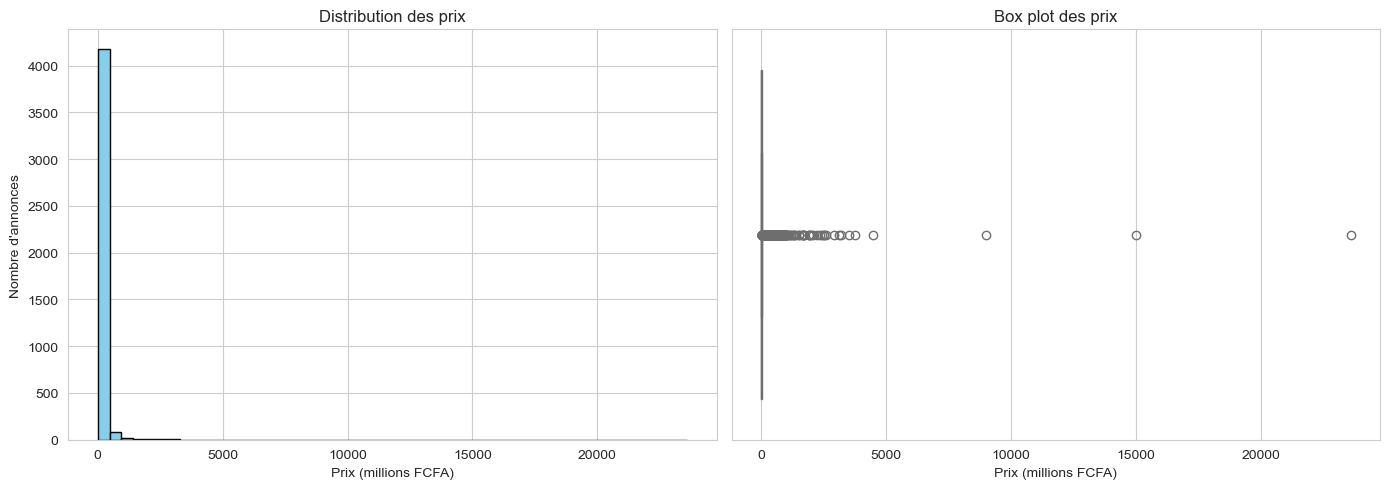

In [67]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(df['prix_fcfa'].dropna() / 1_000_000, bins=50, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Prix (millions FCFA)')
axes[0].set_ylabel("Nombre d'annonces")
axes[0].set_title('Distribution des prix')

# Box plot
sns.boxplot(x=df['prix_fcfa'] / 1_000_000, ax=axes[1], color='lightcoral')
axes[1].set_xlabel('Prix (millions FCFA)')
axes[1].set_title('Box plot des prix')

plt.tight_layout()
plt.savefig('distribution_prix_globale.png')
plt.show()

# - 4. Prix moyen par quartier (Top 20)

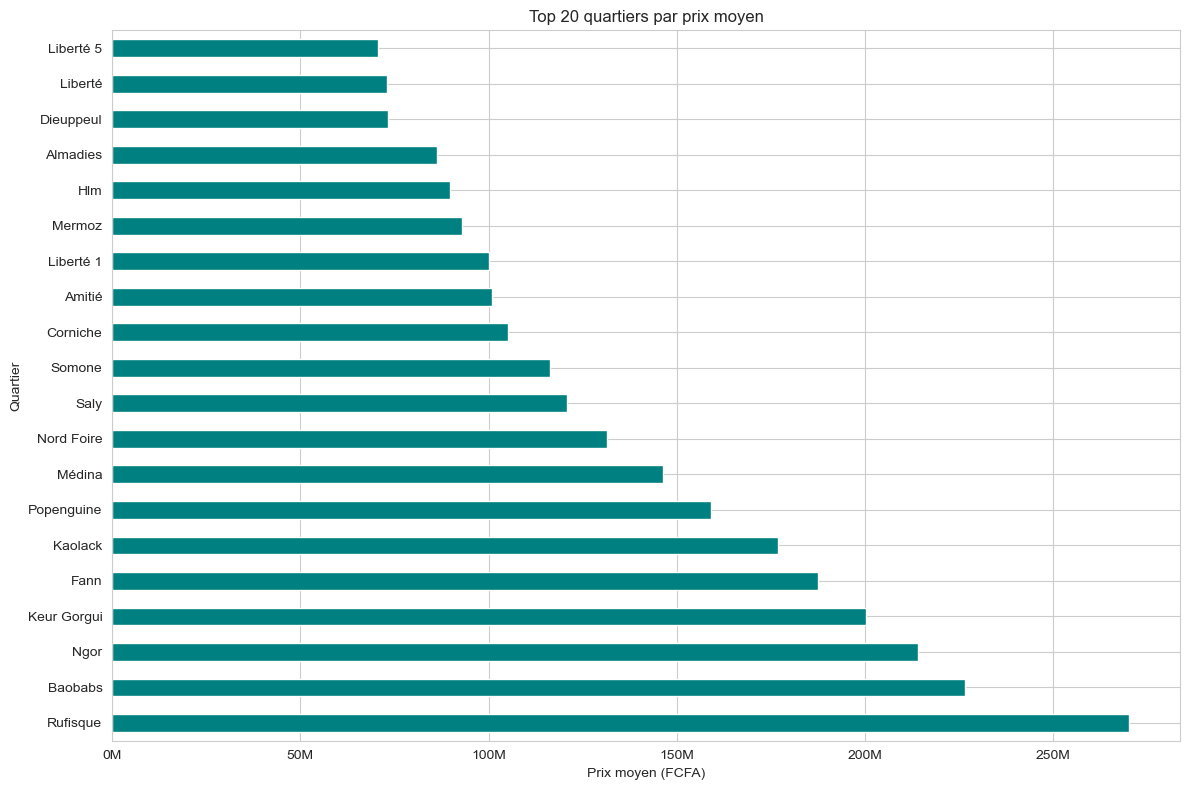

In [68]:
prix_quartier = df.groupby('quartier')['prix_fcfa'].mean().dropna().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 8))
prix_quartier.plot(kind='barh', color='teal')
plt.xlabel('Prix moyen (FCFA)')
plt.ylabel('Quartier')
plt.title('Top 20 quartiers par prix moyen')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1_000_000:.0f}M'))
plt.tight_layout()
plt.savefig('prix_moyen_quartier_top20.png')
plt.show()

# - 5. Évolution temporelle des prix

  ÉVOLUTION TEMPORELLE DES PRIX
  Démarrage: 2026-03-13 02:59:48

📂 4313 annonces chargées
📊 4310 annonces avec année et mois valides

📈 APERÇU DE L'ÉVOLUTION (derniers mois) :
date
2025-04-01    1.119974e+08
2025-05-01    4.775735e+07
2025-06-01    4.854525e+07
2025-07-01    8.518503e+07
2025-08-01    5.325094e+07
2025-09-01    5.408336e+07
2025-10-01    5.834098e+07
2025-11-01    1.452936e+08
2025-12-01    6.643523e+07
2026-01-01    8.047471e+07
2026-02-01    6.549374e+07
2026-03-01    5.436924e+07
Name: prix_fcfa, dtype: float64


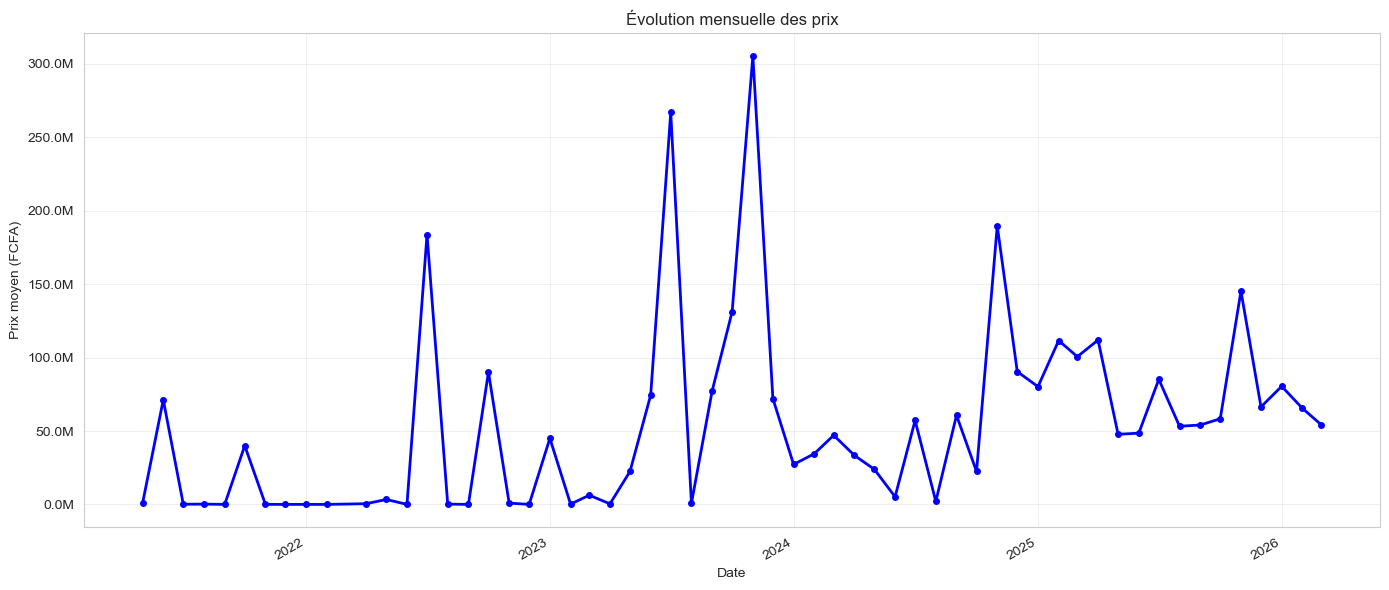


✅ Graphique sauvegardé : evolution_temporelle_prix.png

  Fin: 2026-03-13 02:59:49


In [71]:
# ============================================
# TÂCHE 4 — ÉVOLUTION TEMPORELLE DES PRIX (CORRIGÉ)
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

print("="*65)
print("  ÉVOLUTION TEMPORELLE DES PRIX")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# Solution : filtrer les NaN avant conversion
df_temp = df.dropna(subset=['annee_pub', 'mois_pub']).copy()
print(f"📊 {len(df_temp)} annonces avec année et mois valides")

# Conversion en entiers
df_temp['annee_pub'] = df_temp['annee_pub'].astype(int)
df_temp['mois_pub'] = df_temp['mois_pub'].astype(int)

# Création de la colonne date
df_temp['date'] = pd.to_datetime(
    df_temp['annee_pub'].astype(str) + '-' + 
    df_temp['mois_pub'].astype(str) + '-01'
)

# ✅ UTILISER df_temp pour le groupby (pas df)
evolution = df_temp.groupby('date')['prix_fcfa'].mean()

print(f"\n📈 APERÇU DE L'ÉVOLUTION (derniers mois) :")
print(evolution.tail(12))

# Création du graphique
plt.figure(figsize=(14, 6))
evolution.plot(marker='o', linestyle='-', color='blue', linewidth=2, markersize=4)
plt.xlabel('Date')
plt.ylabel('Prix moyen (FCFA)')
plt.title('Évolution mensuelle des prix')
plt.grid(True, alpha=0.3)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1_000_000:.1f}M'))
plt.tight_layout()
plt.savefig('evolution_temporelle_prix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Graphique sauvegardé : evolution_temporelle_prix.png")
print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# - notebook2 suite

  NOTEBOOK 02 — ANALYSE DES PRIX (SUITE)
  Démarrage: 2026-03-13 03:06:17

📂 4313 annonces chargées

  6. PRIX PAR TYPE DE BIEN

📊 STATISTIQUES PAR TYPE DE BIEN :
                    mean       median  count
type_simple                                 
Vente        245917779.0  110000000.0   1337
Location       2040875.0     727500.0   2216
Autre           966144.0      45000.0    760

💾 Tableau sauvegardé : statistiques_par_type_bien.csv


C:\Users\Dell\AppData\Local\Temp\ipykernel_9100\614847644.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='type_simple', y=df['prix_fcfa'] / 1_000_000, ax=axes[0], palette='Set2')


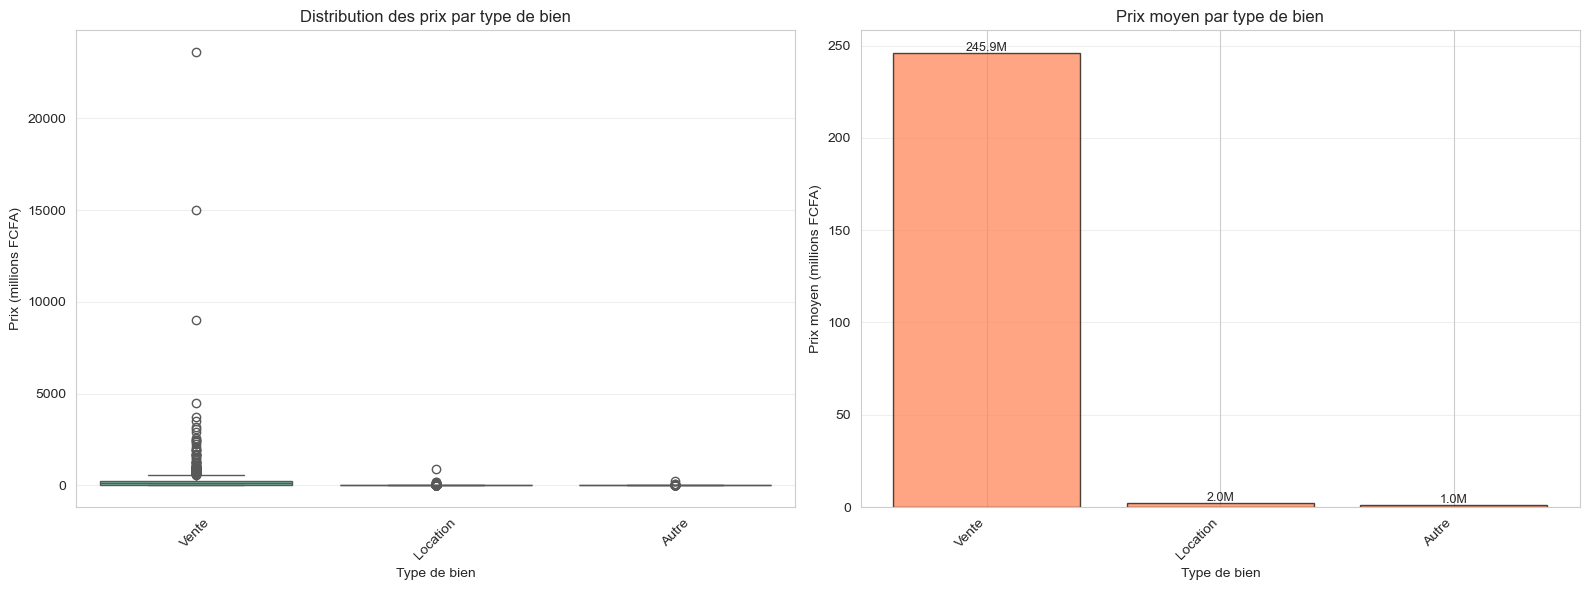


✅ Graphique sauvegardé : prix_par_type_bien.png

  7. CORRÉLATION PRIX / SURFACE
📊 1381 annonces avec surface et prix renseignés

📊 ANALYSE DE CORRÉLATION :
   Corrélation de Pearson    : r = 0.193 (p-value = 5.271e-13)
   Corrélation de Spearman   : ρ = 0.277 (p-value = 8.295e-26)


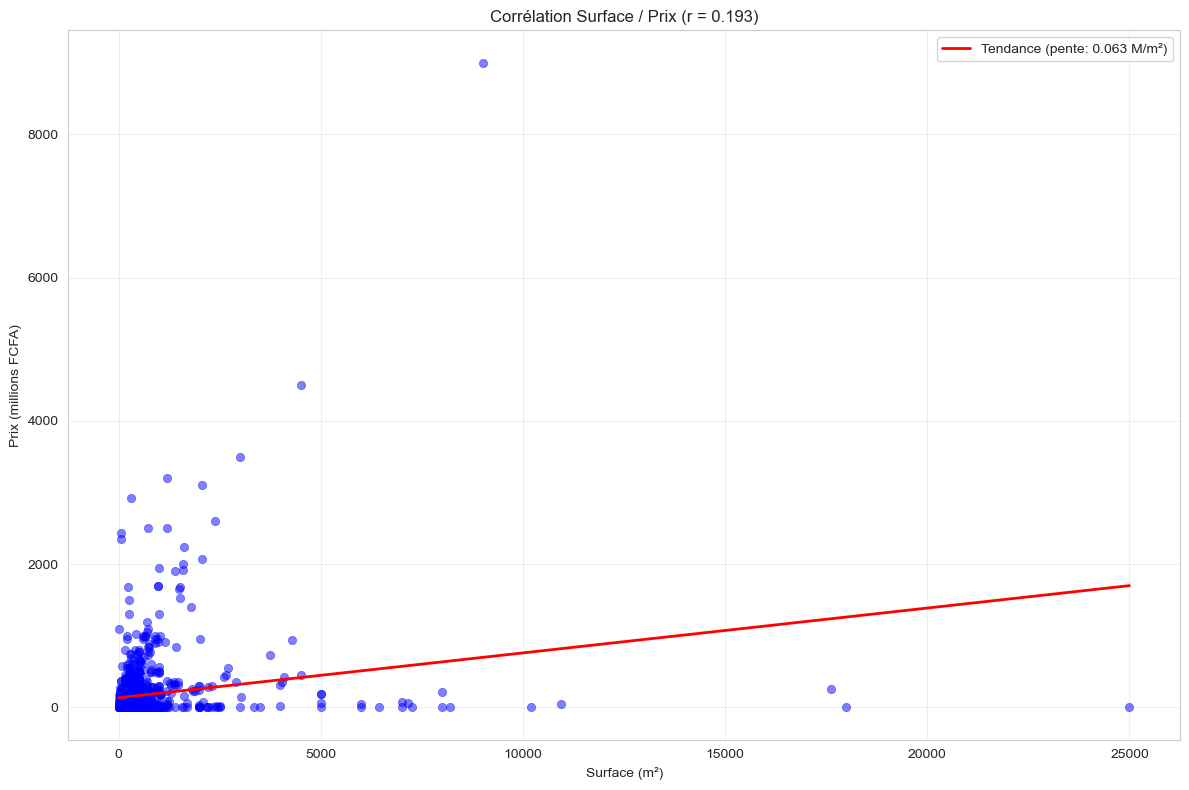


✅ Graphique sauvegardé : correlation_prix_surface.png

  8. RÉSUMÉ DES INDICATEURS CLÉS

=== INDICATEURS CLÉS ===
📊 PRIX :
   Prix moyen   : 77,451,639 FCFA
   Prix médian  : 1,000,000 FCFA
   Prix min     : 1 FCFA
   Prix max     : 23,600,000,000 FCFA

📍 QUARTIERS :
   Quartier le plus cher      : Rufisque (270,154,737 FCFA)
   Quartier le plus accessible : Tambacounda (27,500 FCFA)

📈 ÉVOLUTION :
   Évolution mensuelle moyenne : 24459.3%
   Plus forte hausse           : 714551.4%
   Plus forte baisse           : -99.9%

🏠 TYPES DE BIEN :
   Vente        : 1337 annonces, prix moyen 245.9M FCFA
   Location     : 2216 annonces, prix moyen 2.0M FCFA
   Autre        :  760 annonces, prix moyen 1.0M FCFA

  Fin: 2026-03-13 03:06:19


In [73]:
# ============================================
# NOTEBOOK 02 — ANALYSE DES PRIX (SUITE)
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from datetime import datetime

print("="*65)
print("  NOTEBOOK 02 — ANALYSE DES PRIX (SUITE)")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données (si pas déjà fait)
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# ============================================
# 6. PRIX PAR TYPE DE BIEN
# ============================================

print("\n" + "="*65)
print("  6. PRIX PAR TYPE DE BIEN")
print("="*65)

# Création de la colonne type_simple (si pas déjà fait)
def categoriser_type(x):
    x_str = str(x).lower() if pd.notna(x) else ''
    if 'louer' in x_str or 'location' in x_str:
        return 'Location'
    elif 'vendre' in x_str or 'vente' in x_str:
        return 'Vente'
    elif 'terrain' in x_str:
        return 'Terrain'
    elif 'commercial' in x_str:
        return 'Commercial'
    else:
        return 'Autre'

df['type_simple'] = df['categorie'].apply(categoriser_type)

# Statistiques par type
stats_type = df.groupby('type_simple')['prix_fcfa'].agg(['mean', 'median', 'count']).round(0)
stats_type = stats_type.sort_values('mean', ascending=False)
print(f"\n📊 STATISTIQUES PAR TYPE DE BIEN :")
print(stats_type.to_string())

# Sauvegarde en CSV
stats_type.to_csv('statistiques_par_type_bien.csv')
print(f"\n💾 Tableau sauvegardé : statistiques_par_type_bien.csv")

# Création du graphique
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot par type
sns.boxplot(data=df, x='type_simple', y=df['prix_fcfa'] / 1_000_000, ax=axes[0], palette='Set2')
axes[0].set_xlabel('Type de bien')
axes[0].set_ylabel('Prix (millions FCFA)')
axes[0].set_title('Distribution des prix par type de bien')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

# Prix moyen par type
prix_type = df.groupby('type_simple')['prix_fcfa'].mean().sort_values(ascending=False)
bars = axes[1].bar(range(len(prix_type)), prix_type.values / 1_000_000, 
                   color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xticks(range(len(prix_type)))
axes[1].set_xticklabels(prix_type.index, rotation=45, ha='right')
axes[1].set_xlabel('Type de bien')
axes[1].set_ylabel('Prix moyen (millions FCFA)')
axes[1].set_title('Prix moyen par type de bien')
axes[1].grid(True, alpha=0.3, axis='y')

# Ajouter les valeurs sur les barres
for i, (bar, val) in enumerate(zip(bars, prix_type.values)):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{val/1_000_000:.1f}M', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('prix_par_type_bien.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Graphique sauvegardé : prix_par_type_bien.png")

# ============================================
# 7. CORRÉLATION PRIX / SURFACE
# ============================================

print("\n" + "="*65)
print("  7. CORRÉLATION PRIX / SURFACE")
print("="*65)

# Filtrer les annonces avec surface et prix valides
df_corr = df.dropna(subset=['prix_fcfa', 'surface_m2']).copy()
print(f"📊 {len(df_corr)} annonces avec surface et prix renseignés")

# Calcul de la corrélation
corr, p_value = stats.pearsonr(df_corr['surface_m2'], df_corr['prix_fcfa'])
corr_spearman, p_value_spearman = stats.spearmanr(df_corr['surface_m2'], df_corr['prix_fcfa'])

print(f"\n📊 ANALYSE DE CORRÉLATION :")
print(f"   Corrélation de Pearson    : r = {corr:.3f} (p-value = {p_value:.3e})")
print(f"   Corrélation de Spearman   : ρ = {corr_spearman:.3f} (p-value = {p_value_spearman:.3e})")

# Création du graphique
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_corr, x='surface_m2', y=df_corr['prix_fcfa'] / 1_000_000, 
                alpha=0.5, color='blue', edgecolor=None)
plt.xlabel('Surface (m²)')
plt.ylabel('Prix (millions FCFA)')
plt.title(f'Corrélation Surface / Prix (r = {corr:.3f})')
plt.grid(True, alpha=0.3)

# Ajouter une ligne de régression
z = np.polyfit(df_corr['surface_m2'], df_corr['prix_fcfa'], 1)
p = np.poly1d(z)
x_sorted = np.sort(df_corr['surface_m2'])
plt.plot(x_sorted, p(x_sorted) / 1_000_000, 'r-', linewidth=2, 
         label=f'Tendance (pente: {z[0]/1_000_000:.3f} M/m²)')
plt.legend()

plt.tight_layout()
plt.savefig('correlation_prix_surface.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Graphique sauvegardé : correlation_prix_surface.png")

# ============================================
# 8. RÉSUMÉ DES INDICATEURS CLÉS
# ============================================

print("\n" + "="*65)
print("  8. RÉSUMÉ DES INDICATEURS CLÉS")
print("="*65)

# Prix moyen par quartier (calculé précédemment)
prix_quartier = df.groupby('quartier')['prix_fcfa'].mean().dropna().sort_values(ascending=False)

# Évolution mensuelle (calculée précédemment)
df_temp = df.dropna(subset=['annee_pub', 'mois_pub']).copy()
df_temp['annee_pub'] = df_temp['annee_pub'].astype(int)
df_temp['mois_pub'] = df_temp['mois_pub'].astype(int)
df_temp['date'] = pd.to_datetime(
    df_temp['annee_pub'].astype(str) + '-' + 
    df_temp['mois_pub'].astype(str) + '-01'
)
evolution = df_temp.groupby('date')['prix_fcfa'].mean()

print("\n=== INDICATEURS CLÉS ===")
print(f"📊 PRIX :")
print(f"   Prix moyen   : {df['prix_fcfa'].mean():,.0f} FCFA")
print(f"   Prix médian  : {df['prix_fcfa'].median():,.0f} FCFA")
print(f"   Prix min     : {df['prix_fcfa'].min():,.0f} FCFA")
print(f"   Prix max     : {df['prix_fcfa'].max():,.0f} FCFA")

print(f"\n📍 QUARTIERS :")
if len(prix_quartier) > 0:
    print(f"   Quartier le plus cher      : {prix_quartier.index[0]} ({prix_quartier.values[0]:,.0f} FCFA)")
    print(f"   Quartier le plus accessible : {prix_quartier.index[-1]} ({prix_quartier.values[-1]:,.0f} FCFA)")

print(f"\n📈 ÉVOLUTION :")
print(f"   Évolution mensuelle moyenne : {evolution.pct_change().mean():.1%}")
print(f"   Plus forte hausse           : {evolution.pct_change().max():.1%}")
print(f"   Plus forte baisse           : {evolution.pct_change().min():.1%}")

print(f"\n🏠 TYPES DE BIEN :")
for type_bien in stats_type.index:
    print(f"   {type_bien:<12} : {stats_type.loc[type_bien, 'count']:>4} annonces, "
          f"prix moyen {stats_type.loc[type_bien, 'mean']/1_000_000:.1f}M FCFA")

print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

## Tâches de NDEYE FATOU
# Créer le notebook "03_analyse_geographique.ipynb"
# Créer le notebook "04_kpis_globaux.ipynb" 
# Exporter tous les notebooks en HTML


# - TÂCHE 1 — Créer le notebook "03_analyse_geographique.ipynb"

  NOTEBOOK 03 — ANALYSE GÉOGRAPHIQUE
  Démarrage: 2026-03-13 03:54:01

📂 4313 annonces chargées

  1. STATISTIQUES PAR VILLE
📊 3272 annonces avec ville et prix renseignés

📊 STATISTIQUES PAR VILLE :
              prix_moyen  prix_median    prix_min      prix_max  nb_annonces  surface_moyenne  chambres_moyennes
ville                                                                                                           
Kaolack      176910500.0   38803500.0     15000.0  4.919130e+08            3            468.0                NaN
Rufisque     170109678.0    4000000.0         7.0  3.750000e+09           62            572.0                3.0
Mbour        114430444.0   48000000.0     15000.0  9.500000e+08          205            818.0                4.0
Dakar         73497547.0     950000.0         1.0  1.500000e+10         2799            389.0                3.0
Touba         68217789.0   20000000.0     20000.0  5.500000e+08           19            373.0                3.0
Pikine    

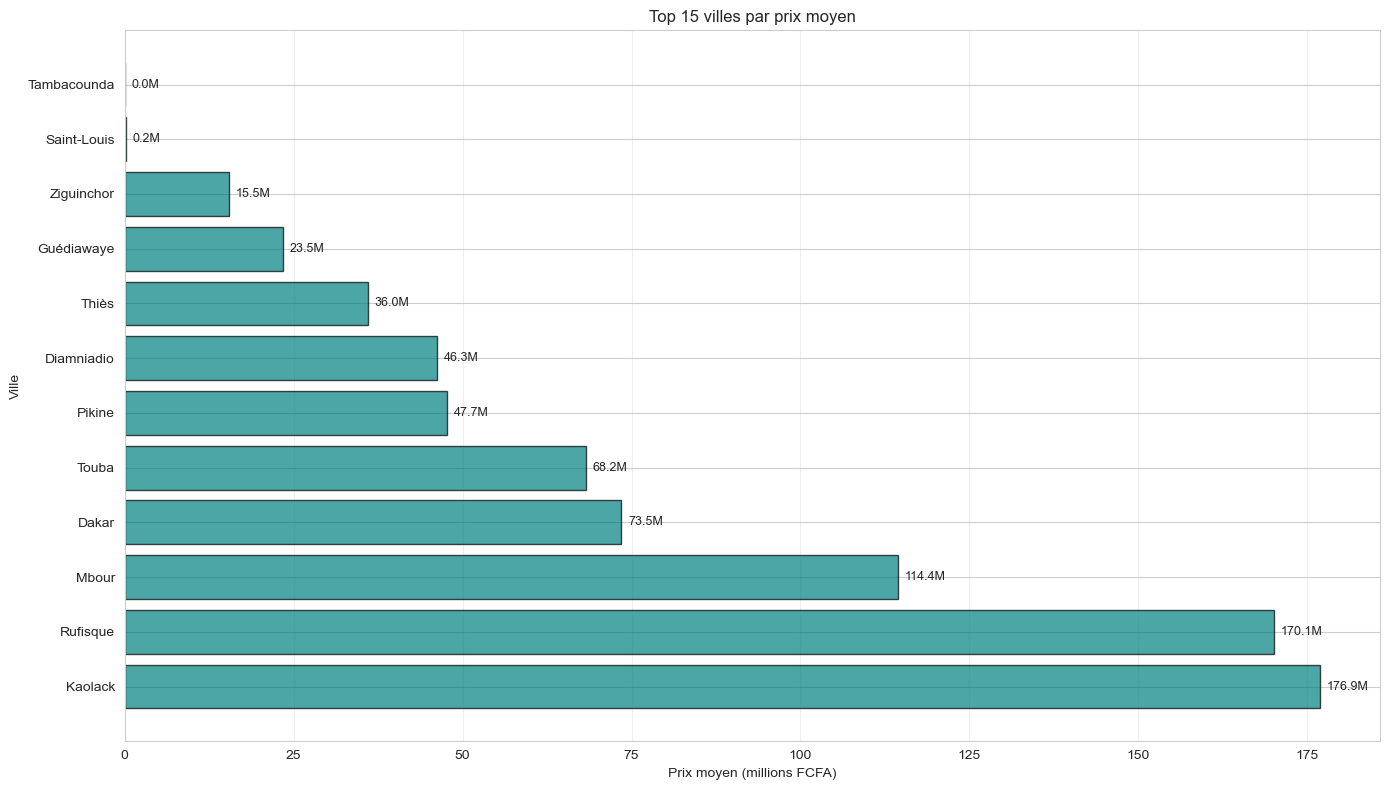


✅ Graphique sauvegardé : prix_moyen_par_ville.png

  2. STATISTIQUES PAR QUARTIER
📊 3272 annonces avec quartier et prix renseignés

📊 TOP 20 QUARTIERS PAR PRIX MOYEN :
              prix_moyen  prix_median  prix_min      prix_max  nb_annonces  surface_moyenne  chambres_moyennes  prix_m2_moyen
quartier                                                                                                                     
Rufisque     270154737.0    4000000.0       7.0  3.750000e+09           38            738.0                3.0       910270.0
Baobabs      226516667.0  329500000.0   50000.0  3.500000e+08            3           7136.0                4.0       259787.0
Ngor         214195391.0     800000.0   10000.0  9.000000e+09          120            842.0                3.0       630827.0
Keur Gorgui  200200000.0     375000.0   50000.0  8.000000e+08            4            150.0                3.0         3000.0
Fann         187455598.0    2000000.0   11000.0  3.200000e+09          110 

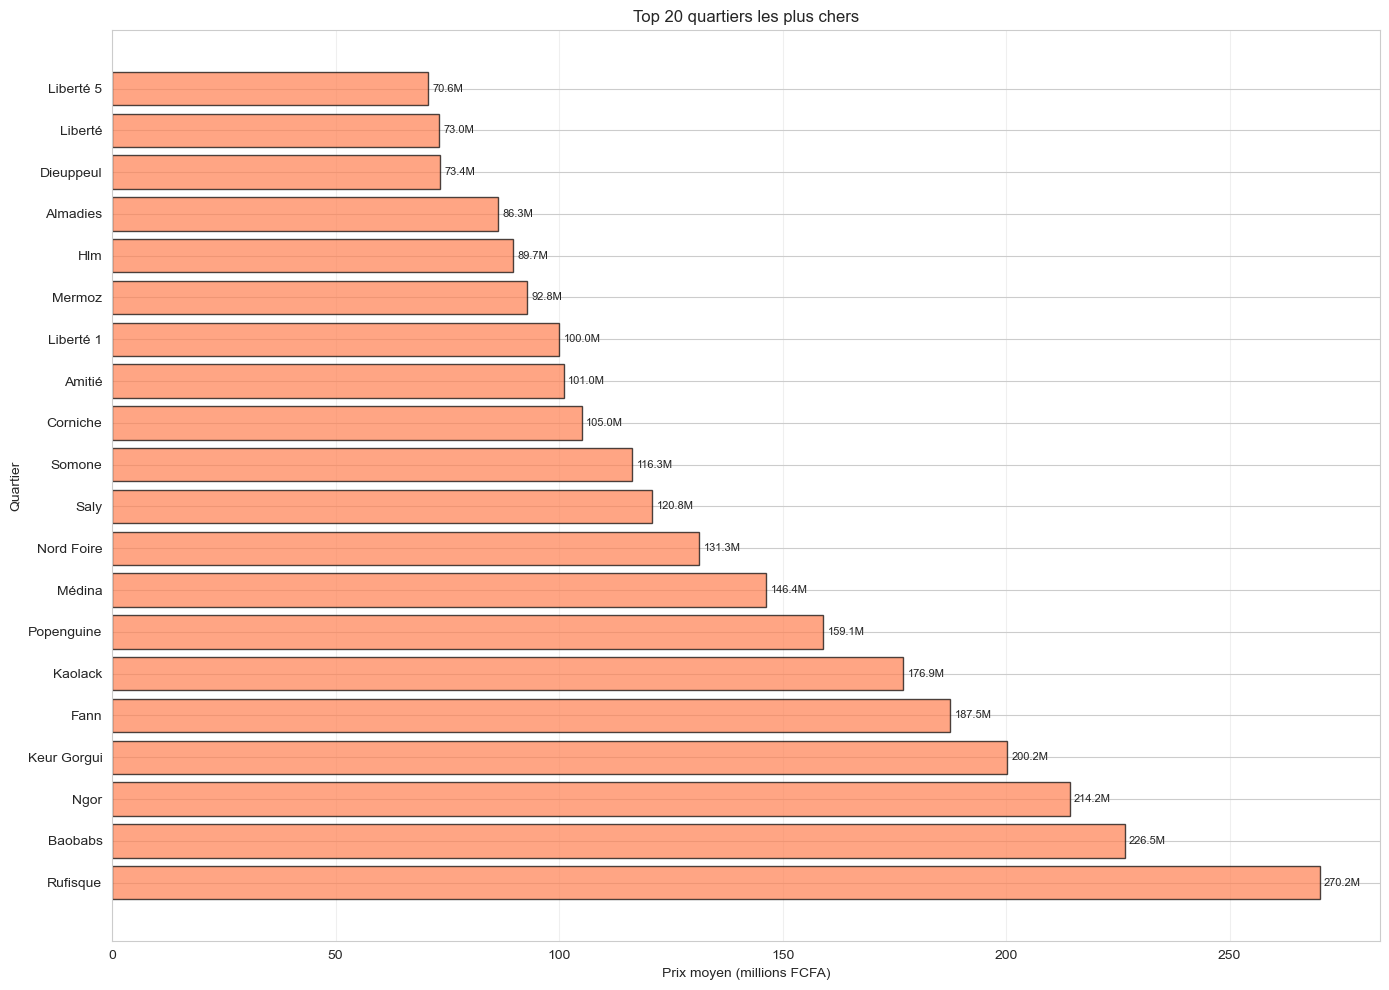


✅ Graphique sauvegardé : top_20_quartiers_chers.png


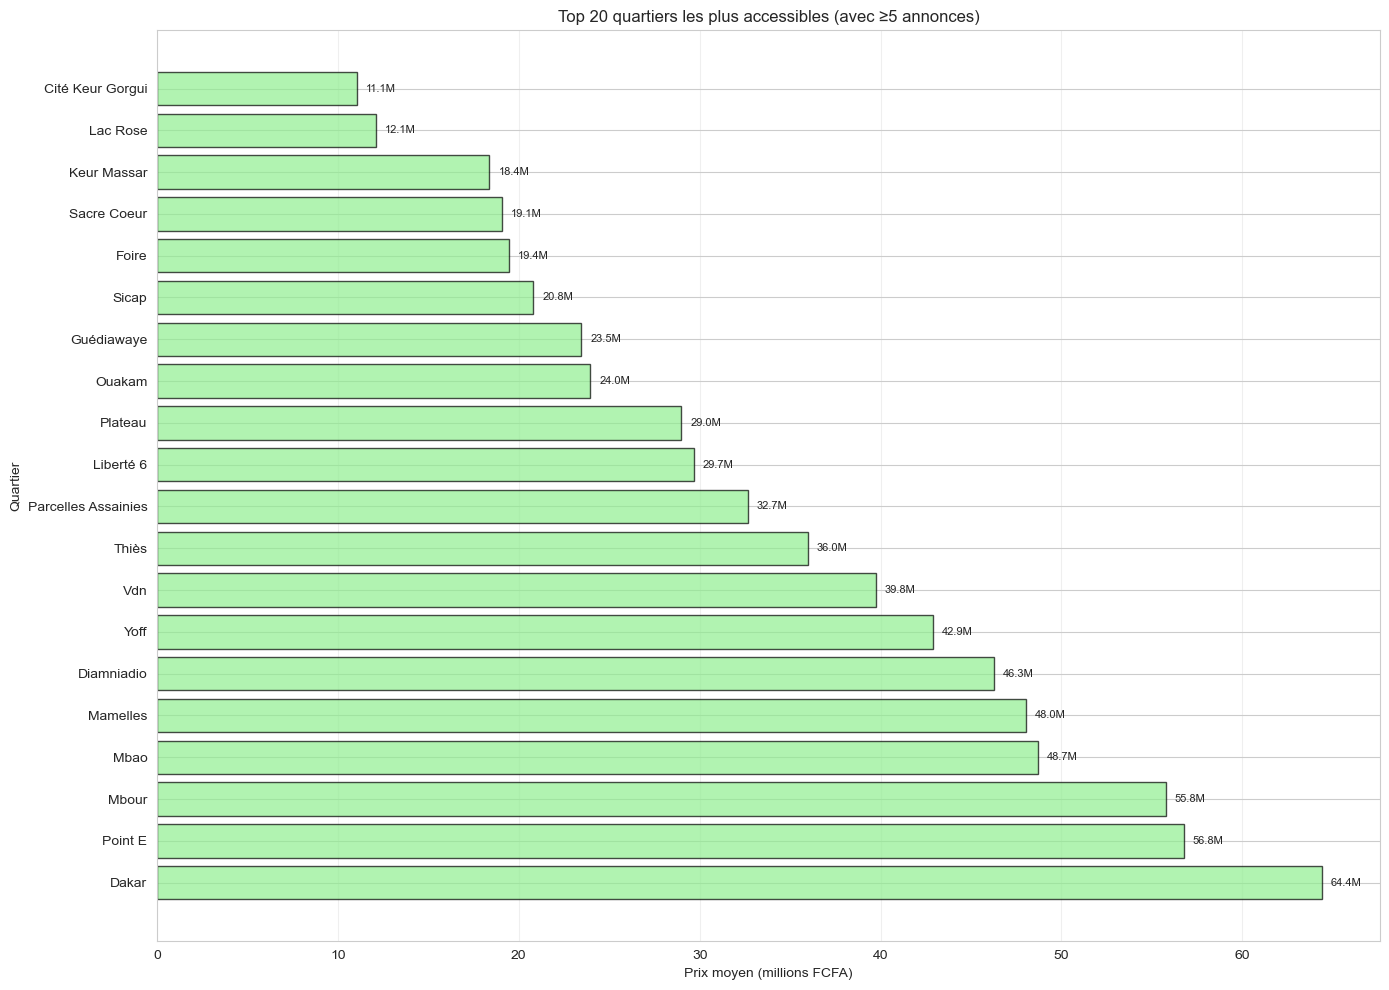


✅ Graphique sauvegardé : top_20_quartiers_accessibles.png

  3. CARTE STATIQUE DES PRIX PAR QUARTIER


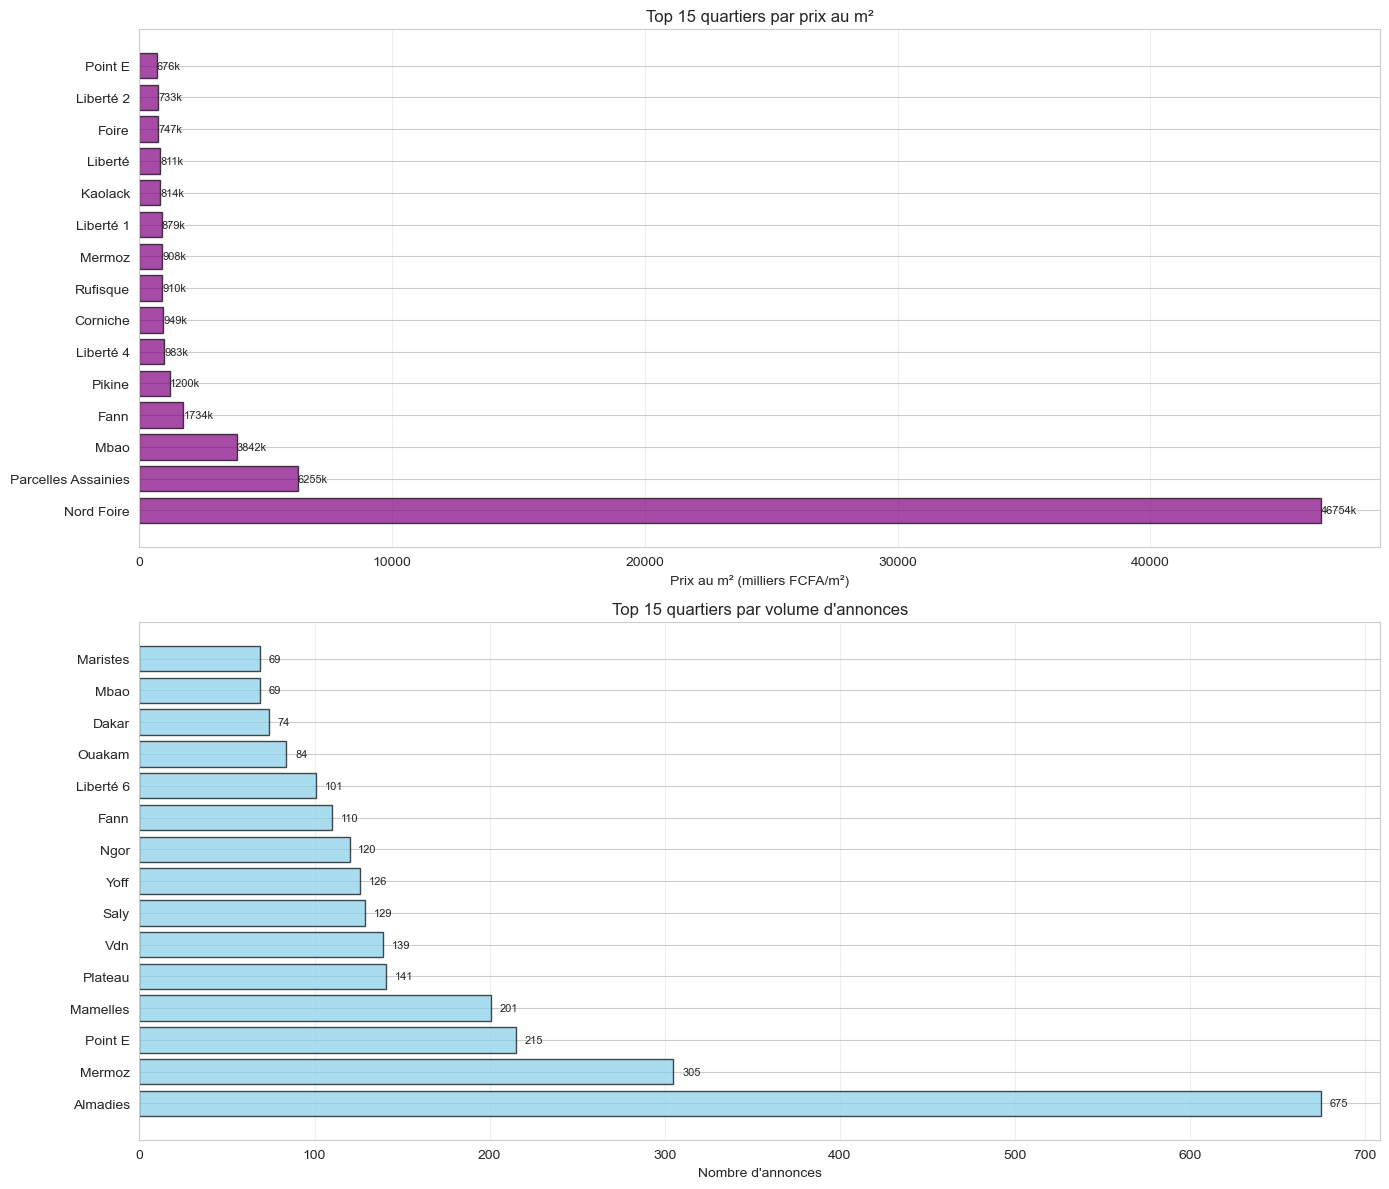


✅ Graphique sauvegardé : analyse_geographique_globale.png

  NOTEBOOK 03 TERMINÉ
  Fin: 2026-03-13 03:54:10


In [74]:
# ============================================
# NOTEBOOK 03 — ANALYSE GÉOGRAPHIQUE
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

print("="*65)
print("  NOTEBOOK 03 — ANALYSE GÉOGRAPHIQUE")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# ============================================
# 1. STATISTIQUES PAR VILLE
# ============================================

print("\n" + "="*65)
print("  1. STATISTIQUES PAR VILLE")
print("="*65)

# Filtrer les annonces avec ville et prix valides
df_ville = df.dropna(subset=['ville', 'prix_fcfa']).copy()
print(f"📊 {len(df_ville)} annonces avec ville et prix renseignés")

# Statistiques par ville
stats_ville = df_ville.groupby('ville').agg({
    'prix_fcfa': ['mean', 'median', 'min', 'max', 'count'],
    'surface_m2': 'mean',
    'nb_chambres': 'mean'
}).round(0)

# Aplatir les colonnes
stats_ville.columns = ['prix_moyen', 'prix_median', 'prix_min', 'prix_max', 
                       'nb_annonces', 'surface_moyenne', 'chambres_moyennes']
stats_ville = stats_ville.sort_values('prix_moyen', ascending=False)

print(f"\n📊 STATISTIQUES PAR VILLE :")
print(stats_ville.to_string())

# Sauvegarde en CSV
stats_ville.to_csv('statistiques_par_ville.csv')
print(f"\n💾 Tableau sauvegardé : statistiques_par_ville.csv")

# Graphique : Prix moyen par ville (Top 15)
top_15_villes = stats_ville.head(15)

plt.figure(figsize=(14, 8))
bars = plt.barh(range(len(top_15_villes)), top_15_villes['prix_moyen'] / 1_000_000, 
                color='teal', edgecolor='black', alpha=0.7)
plt.yticks(range(len(top_15_villes)), top_15_villes.index)
plt.xlabel('Prix moyen (millions FCFA)')
plt.ylabel('Ville')
plt.title('Top 15 villes par prix moyen')
plt.grid(True, alpha=0.3, axis='x')

# Ajouter les valeurs sur les barres
for i, (bar, val) in enumerate(zip(bars, top_15_villes['prix_moyen'])):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{val/1_000_000:.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('prix_moyen_par_ville.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Graphique sauvegardé : prix_moyen_par_ville.png")

# ============================================
# 2. STATISTIQUES PAR QUARTIER
# ============================================

print("\n" + "="*65)
print("  2. STATISTIQUES PAR QUARTIER")
print("="*65)

# Filtrer les annonces avec quartier et prix valides
df_quartier = df.dropna(subset=['quartier', 'prix_fcfa']).copy()
print(f"📊 {len(df_quartier)} annonces avec quartier et prix renseignés")

# Statistiques par quartier
stats_quartier = df_quartier.groupby('quartier').agg({
    'prix_fcfa': ['mean', 'median', 'min', 'max', 'count'],
    'surface_m2': 'mean',
    'nb_chambres': 'mean',
    'prix_m2_fcfa': 'mean'
}).round(0)

# Aplatir les colonnes
stats_quartier.columns = ['prix_moyen', 'prix_median', 'prix_min', 'prix_max', 
                          'nb_annonces', 'surface_moyenne', 'chambres_moyennes', 'prix_m2_moyen']
stats_quartier = stats_quartier.sort_values('prix_moyen', ascending=False)

print(f"\n📊 TOP 20 QUARTIERS PAR PRIX MOYEN :")
print(stats_quartier.head(20).to_string())

# Sauvegarde en CSV
stats_quartier.to_csv('statistiques_par_quartier.csv')
print(f"\n💾 Tableau sauvegardé : statistiques_par_quartier.csv")

# Graphique : Top 20 quartiers les plus chers
top_20_chers = stats_quartier.head(20)

plt.figure(figsize=(14, 10))
bars = plt.barh(range(len(top_20_chers)), top_20_chers['prix_moyen'] / 1_000_000, 
                color='coral', edgecolor='black', alpha=0.7)
plt.yticks(range(len(top_20_chers)), top_20_chers.index)
plt.xlabel('Prix moyen (millions FCFA)')
plt.ylabel('Quartier')
plt.title('Top 20 quartiers les plus chers')
plt.grid(True, alpha=0.3, axis='x')

# Ajouter les valeurs sur les barres
for i, (bar, val) in enumerate(zip(bars, top_20_chers['prix_moyen'])):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
             f'{val/1_000_000:.1f}M', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('top_20_quartiers_chers.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Graphique sauvegardé : top_20_quartiers_chers.png")

# Graphique : Top 20 quartiers les plus accessibles
top_20_accessibles = stats_quartier[stats_quartier['nb_annonces'] >= 5].tail(20)

plt.figure(figsize=(14, 10))
bars = plt.barh(range(len(top_20_accessibles)), top_20_accessibles['prix_moyen'] / 1_000_000, 
                color='lightgreen', edgecolor='black', alpha=0.7)
plt.yticks(range(len(top_20_accessibles)), top_20_accessibles.index)
plt.xlabel('Prix moyen (millions FCFA)')
plt.ylabel('Quartier')
plt.title('Top 20 quartiers les plus accessibles (avec ≥5 annonces)')
plt.grid(True, alpha=0.3, axis='x')

# Ajouter les valeurs sur les barres
for i, (bar, val) in enumerate(zip(bars, top_20_accessibles['prix_moyen'])):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{val/1_000_000:.1f}M', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('top_20_quartiers_accessibles.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Graphique sauvegardé : top_20_quartiers_accessibles.png")

# ============================================
# 3. CARTE DES PRIX PAR QUARTIER (version statique)
# ============================================

print("\n" + "="*65)
print("  3. CARTE STATIQUE DES PRIX PAR QUARTIER")
print("="*65)

# Créer un graphique en barres pour visualiser la répartition géographique
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Graphique 1: Prix au m² par quartier (Top 15)
top_15_m2 = stats_quartier.sort_values('prix_m2_moyen', ascending=False).head(15)

bars1 = axes[0].barh(range(len(top_15_m2)), top_15_m2['prix_m2_moyen'] / 1000, 
                     color='purple', edgecolor='black', alpha=0.7)
axes[0].set_yticks(range(len(top_15_m2)))
axes[0].set_yticklabels(top_15_m2.index)
axes[0].set_xlabel('Prix au m² (milliers FCFA/m²)')
axes[0].set_title('Top 15 quartiers par prix au m²')
axes[0].grid(True, alpha=0.3, axis='x')

# Ajouter les valeurs
for i, (bar, val) in enumerate(zip(bars1, top_15_m2['prix_m2_moyen'])):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, 
                 f'{val/1000:.0f}k', va='center', fontsize=8)

# Graphique 2: Nombre d'annonces par quartier (Top 15)
top_15_volume = stats_quartier.sort_values('nb_annonces', ascending=False).head(15)

bars2 = axes[1].barh(range(len(top_15_volume)), top_15_volume['nb_annonces'], 
                     color='skyblue', edgecolor='black', alpha=0.7)
axes[1].set_yticks(range(len(top_15_volume)))
axes[1].set_yticklabels(top_15_volume.index)
axes[1].set_xlabel("Nombre d'annonces")
axes[1].set_title('Top 15 quartiers par volume d\'annonces')
axes[1].grid(True, alpha=0.3, axis='x')

# Ajouter les valeurs
for i, (bar, val) in enumerate(zip(bars2, top_15_volume['nb_annonces'])):
    axes[1].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
                 f'{int(val)}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('analyse_geographique_globale.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Graphique sauvegardé : analyse_geographique_globale.png")

print("\n" + "="*65)
print("  NOTEBOOK 03 TERMINÉ")
print("="*65)
print(f"  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# - TÂCHE 2 — Créer le notebook "04_kpis_globaux.ipynb"

  NOTEBOOK 04 — KPIS GLOBAUX
  Démarrage: 2026-03-13 03:55:21

📂 4313 annonces chargées

  KPI 1 — PRIX MOYEN PAR VILLE

🏙️  PRIX MOYEN PAR VILLE :
   Kaolack         :     176,910,500 FCFA
   Rufisque        :     170,109,678 FCFA
   Mbour           :     114,430,444 FCFA
   Dakar           :      73,497,547 FCFA
   Touba           :      68,217,789 FCFA
   Pikine          :      47,703,878 FCFA
   Diamniadio      :      46,283,500 FCFA
   Thiès           :      35,983,375 FCFA
   Guédiawaye      :      23,464,286 FCFA
   Ziguinchor      :      15,500,000 FCFA

💾 KPI sauvegardé : kpi_prix_moyen_par_ville.csv

  KPI 2 — QUARTIER LE PLUS CHER

🏆 QUARTIER LE PLUS CHER :
   Rufisque
   Prix moyen : 270,154,737 FCFA
   Nombre d'annonces : 38

💾 KPI sauvegardé : kpi_quartier_plus_cher.csv

  KPI 3 — QUARTIER LE PLUS ACCESSIBLE

🔽 QUARTIER LE PLUS ACCESSIBLE :
   Cité Keur Gorgui
   Prix moyen : 11,070,114 FCFA
   Nombre d'annonces : 65

💾 KPI sauvegardé : kpi_quartier_plus_accessible.csv

 

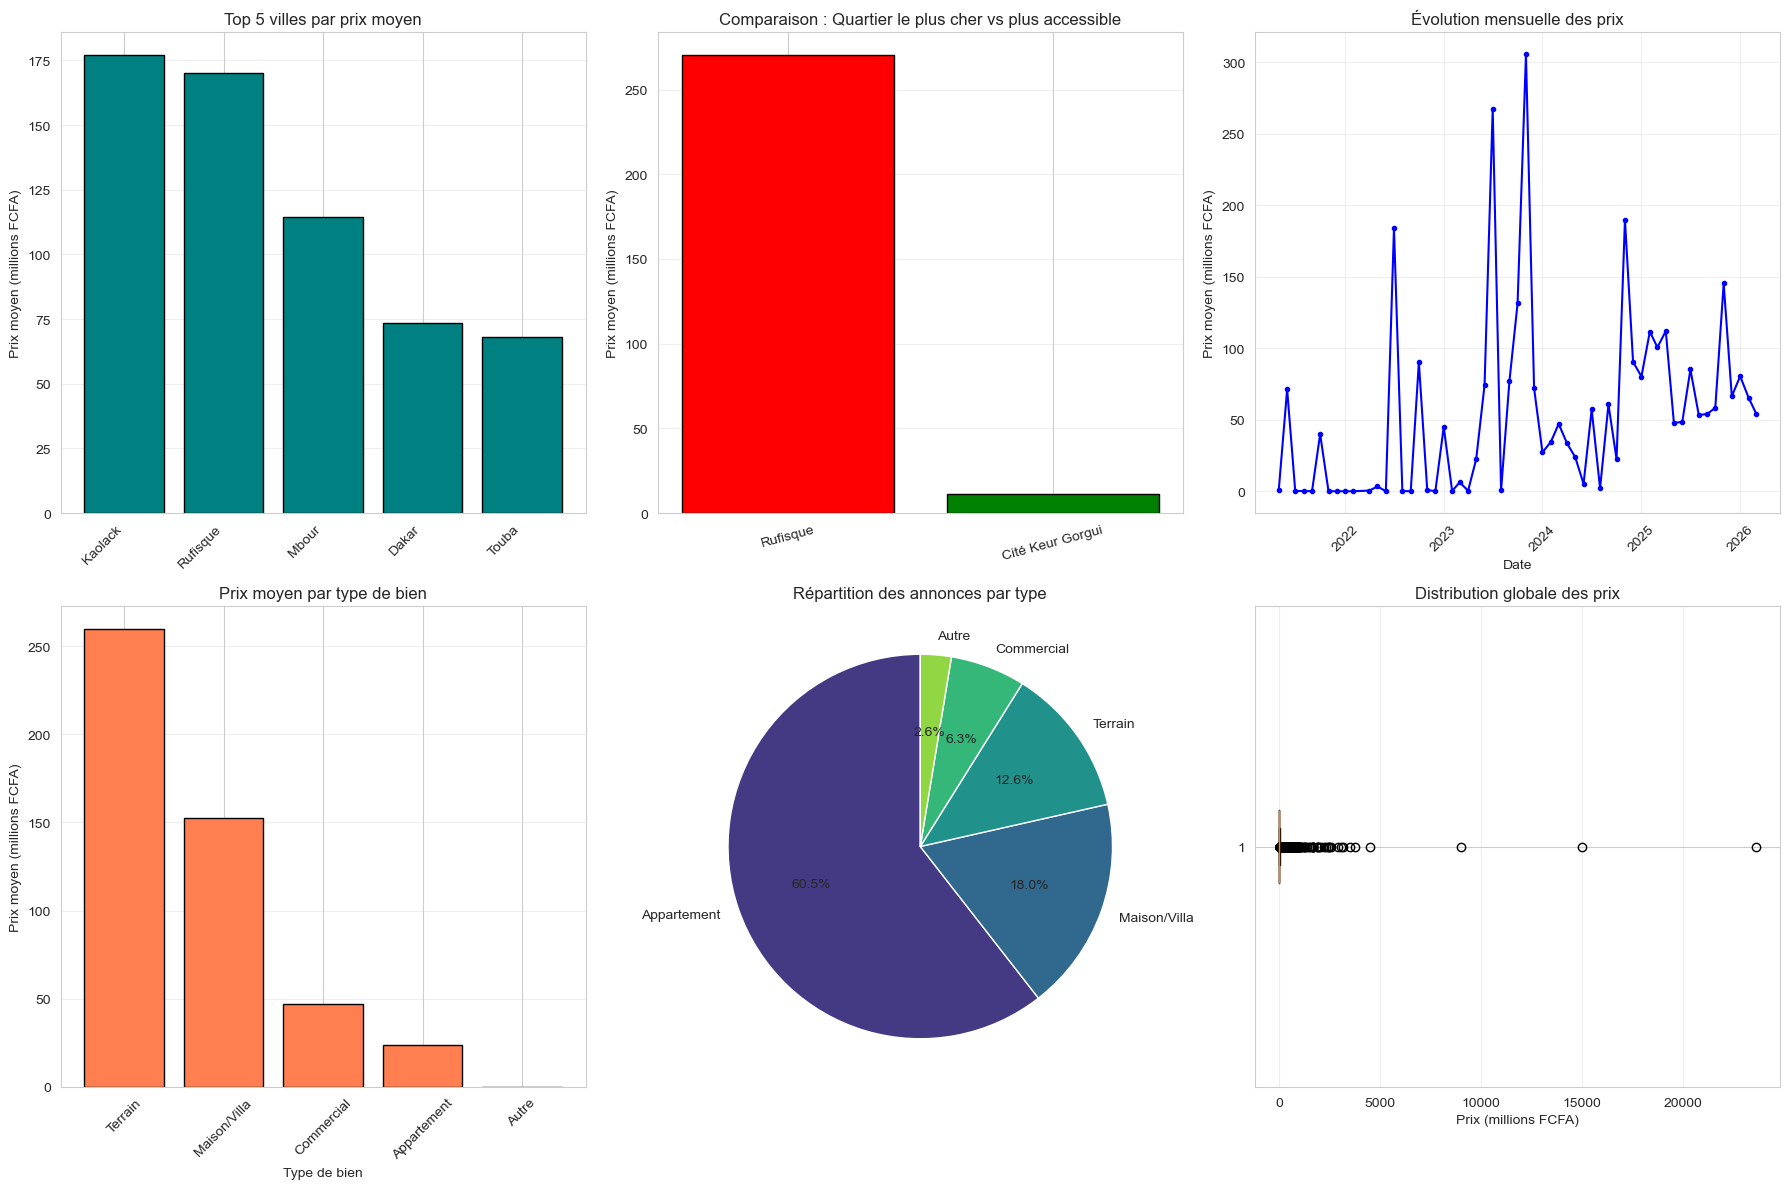


✅ Graphique sauvegardé : tableau_de_bord_kpis.png

  NOTEBOOK 04 TERMINÉ
  Fin: 2026-03-13 03:55:25


In [75]:
# ============================================
# NOTEBOOK 04 — KPIS GLOBAUX
# ============================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from datetime import datetime

print("="*65)
print("  NOTEBOOK 04 — KPIS GLOBAUX")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Chargement des données
df = pd.read_csv("expat_dakar_pieces_traite.csv", encoding='utf-8-sig')
print(f"\n📂 {len(df)} annonces chargées")

# ============================================
# 1. PRIX MOYEN PAR VILLE
# ============================================

print("\n" + "="*65)
print("  KPI 1 — PRIX MOYEN PAR VILLE")
print("="*65)

# Filtrer les annonces avec ville et prix valides
df_ville = df.dropna(subset=['ville', 'prix_fcfa']).copy()
prix_moyen_ville = df_ville.groupby('ville')['prix_fcfa'].mean().round(0).sort_values(ascending=False)

print(f"\n🏙️  PRIX MOYEN PAR VILLE :")
for ville, prix in prix_moyen_ville.head(10).items():
    print(f"   {ville:<15} : {prix:>15,.0f} FCFA")

# Sauvegarde
prix_moyen_ville.to_csv('kpi_prix_moyen_par_ville.csv')
print(f"\n💾 KPI sauvegardé : kpi_prix_moyen_par_ville.csv")

# ============================================
# 2. QUARTIER LE PLUS CHER
# ============================================

print("\n" + "="*65)
print("  KPI 2 — QUARTIER LE PLUS CHER")
print("="*65)

# Filtrer les annonces avec quartier et prix valides (min 5 annonces)
df_quartier = df.dropna(subset=['quartier', 'prix_fcfa']).copy()
quartier_stats = df_quartier.groupby('quartier').agg({
    'prix_fcfa': ['mean', 'count']
}).round(0)

quartier_stats.columns = ['prix_moyen', 'nb_annonces']
quartier_stats = quartier_stats[quartier_stats['nb_annonces'] >= 5].sort_values('prix_moyen', ascending=False)

quartier_plus_cher = quartier_stats.head(1)

print(f"\n🏆 QUARTIER LE PLUS CHER :")
print(f"   {quartier_plus_cher.index[0]}")
print(f"   Prix moyen : {quartier_plus_cher['prix_moyen'].values[0]:,.0f} FCFA")
print(f"   Nombre d'annonces : {int(quartier_plus_cher['nb_annonces'].values[0])}")

# Sauvegarde
quartier_plus_cher.to_csv('kpi_quartier_plus_cher.csv')
print(f"\n💾 KPI sauvegardé : kpi_quartier_plus_cher.csv")

# ============================================
# 3. QUARTIER LE PLUS ACCESSIBLE
# ============================================

print("\n" + "="*65)
print("  KPI 3 — QUARTIER LE PLUS ACCESSIBLE")
print("="*65)

quartier_moins_cher = quartier_stats.tail(1)

print(f"\n🔽 QUARTIER LE PLUS ACCESSIBLE :")
print(f"   {quartier_moins_cher.index[0]}")
print(f"   Prix moyen : {quartier_moins_cher['prix_moyen'].values[0]:,.0f} FCFA")
print(f"   Nombre d'annonces : {int(quartier_moins_cher['nb_annonces'].values[0])}")

# Sauvegarde
quartier_moins_cher.to_csv('kpi_quartier_plus_accessible.csv')
print(f"\n💾 KPI sauvegardé : kpi_quartier_plus_accessible.csv")

# ============================================
# 4. ÉVOLUTION MENSUELLE DES PRIX
# ============================================

print("\n" + "="*65)
print("  KPI 4 — ÉVOLUTION MENSUELLE DES PRIX")
print("="*65)

# Filtrer les annonces avec date et prix valides
df_temp = df.dropna(subset=['annee_pub', 'mois_pub', 'prix_fcfa']).copy()
df_temp['annee_pub'] = df_temp['annee_pub'].astype(int)
df_temp['mois_pub'] = df_temp['mois_pub'].astype(int)
df_temp['date'] = pd.to_datetime(
    df_temp['annee_pub'].astype(str) + '-' + 
    df_temp['mois_pub'].astype(str) + '-01'
)

evolution = df_temp.groupby('date')['prix_fcfa'].mean()

# Calculer la variation mensuelle
variation = evolution.pct_change() * 100

print(f"\n📈 ÉVOLUTION MENSUELLE :")
print(f"   Prix moyen sur la période : {evolution.mean():,.0f} FCFA")
print(f"   Variation mensuelle moyenne : {variation.mean():.1f}%")
print(f"   Plus forte hausse : {variation.max():.1f}%")
print(f"   Plus forte baisse : {variation.min():.1f}%")

# Sauvegarde
evolution_df = pd.DataFrame({
    'date': evolution.index,
    'prix_moyen': evolution.values,
    'variation_pourcentage': variation.values
})
evolution_df.to_csv('kpi_evolution_mensuelle.csv', index=False)
print(f"\n💾 KPI sauvegardé : kpi_evolution_mensuelle.csv")

# ============================================
# 5. PRIX MOYEN PAR TYPE DE BIEN
# ============================================

print("\n" + "="*65)
print("  KPI 5 — PRIX MOYEN PAR TYPE DE BIEN")
print("="*65)

# Créer une catégorie simplifiée
def categoriser_type(x):
    x_str = str(x).lower() if pd.notna(x) else ''
    if 'appartement' in x_str:
        return 'Appartement'
    elif 'maison' in x_str or 'villa' in x_str:
        return 'Maison/Villa'
    elif 'terrain' in x_str:
        return 'Terrain'
    elif 'commercial' in x_str:
        return 'Commercial'
    else:
        return 'Autre'

df['type_simplifie'] = df['categorie'].apply(categoriser_type)

# Statistiques par type
prix_par_type = df.groupby('type_simplifie').agg({
    'prix_fcfa': ['mean', 'median', 'count']
}).round(0)

prix_par_type.columns = ['prix_moyen', 'prix_median', 'nb_annonces']
prix_par_type = prix_par_type.sort_values('prix_moyen', ascending=False)

print(f"\n🏠 PRIX MOYEN PAR TYPE DE BIEN :")
print(prix_par_type.to_string())

# Sauvegarde
prix_par_type.to_csv('kpi_prix_par_type.csv')
print(f"\n💾 KPI sauvegardé : kpi_prix_par_type.csv")

# ============================================
# 6. TABLEAU DE BORD DES KPIS
# ============================================

print("\n" + "="*65)
print("  📊 TABLEAU DE BORD DES KPIS")
print("="*65)

# Créer un résumé global
kpis = {
    'Total annonces': len(df),
    'Prix moyen global': f"{df['prix_fcfa'].mean():,.0f} FCFA",
    'Prix médian global': f"{df['prix_fcfa'].median():,.0f} FCFA",
    'Surface moyenne': f"{df['surface_m2'].mean():.0f} m²",
    'Nombre moyen de chambres': f"{df['nb_chambres'].mean():.1f}",
    'Période couverte': f"{df['annee_pub'].min():.0f} - {df['annee_pub'].max():.0f}",
    'Ville avec prix moyen le plus élevé': f"{prix_moyen_ville.index[0]} ({prix_moyen_ville.values[0]:,.0f} FCFA)",
    'Quartier le plus cher': f"{quartier_plus_cher.index[0]} ({quartier_plus_cher['prix_moyen'].values[0]:,.0f} FCFA)",
    'Quartier le plus accessible': f"{quartier_moins_cher.index[0]} ({quartier_moins_cher['prix_moyen'].values[0]:,.0f} FCFA)",
    'Type de bien le plus cher': f"{prix_par_type.index[0]} ({prix_par_type['prix_moyen'].values[0]:,.0f} FCFA)",
    'Variation mensuelle moyenne': f"{variation.mean():.1f}%"
}

print("\n📋 RÉSUMÉ DES INDICATEURS CLÉS :")
for k, v in kpis.items():
    print(f"   {k:<35} : {v}")

# Sauvegarde du résumé
with open('kpis_globaux.txt', 'w', encoding='utf-8') as f:
    f.write("=== INDICATEURS CLÉS DU MARCHÉ IMMOBILIER ===\n\n")
    for k, v in kpis.items():
        f.write(f"{k}: {v}\n")

print(f"\n💾 Résumé sauvegardé : kpis_globaux.txt")

# ============================================
# 7. VISUALISATION DES KPIS
# ============================================

print("\n" + "="*65)
print("  7. VISUALISATION DES KPIS")
print("="*65)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Prix moyen par ville (Top 5)
top_5_villes = prix_moyen_ville.head(5)
axes[0, 0].bar(range(len(top_5_villes)), top_5_villes.values / 1_000_000, color='teal', edgecolor='black')
axes[0, 0].set_xticks(range(len(top_5_villes)))
axes[0, 0].set_xticklabels(top_5_villes.index, rotation=45, ha='right')
axes[0, 0].set_ylabel('Prix moyen (millions FCFA)')
axes[0, 0].set_title('Top 5 villes par prix moyen')
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Quartier le plus cher vs plus accessible
quartiers_compare = pd.DataFrame({
    'Quartier': [quartier_plus_cher.index[0], quartier_moins_cher.index[0]],
    'Prix moyen': [quartier_plus_cher['prix_moyen'].values[0] / 1_000_000, 
                   quartier_moins_cher['prix_moyen'].values[0] / 1_000_000]
})
axes[0, 1].bar(quartiers_compare['Quartier'], quartiers_compare['Prix moyen'], 
               color=['red', 'green'], edgecolor='black')
axes[0, 1].set_ylabel('Prix moyen (millions FCFA)')
axes[0, 1].set_title('Comparaison : Quartier le plus cher vs plus accessible')
axes[0, 1].grid(True, alpha=0.3, axis='y')
axes[0, 1].tick_params(axis='x', rotation=15)

# 3. Évolution mensuelle
axes[0, 2].plot(evolution.index, evolution.values / 1_000_000, marker='o', linestyle='-', color='blue', markersize=3)
axes[0, 2].set_xlabel('Date')
axes[0, 2].set_ylabel('Prix moyen (millions FCFA)')
axes[0, 2].set_title('Évolution mensuelle des prix')
axes[0, 2].grid(True, alpha=0.3)
axes[0, 2].tick_params(axis='x', rotation=45)

# 4. Prix par type de bien
axes[1, 0].bar(prix_par_type.index, prix_par_type['prix_moyen'] / 1_000_000, 
               color='coral', edgecolor='black')
axes[1, 0].set_xlabel('Type de bien')
axes[1, 0].set_ylabel('Prix moyen (millions FCFA)')
axes[1, 0].set_title('Prix moyen par type de bien')
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Répartition des annonces par type
type_counts = df['type_simplifie'].value_counts()
axes[1, 1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
               startangle=90, colors=sns.color_palette('viridis', len(type_counts)))
axes[1, 1].set_title('Répartition des annonces par type')

# 6. Distribution des prix (box plot)
axes[1, 2].boxplot(df['prix_fcfa'].dropna() / 1_000_000, vert=False)
axes[1, 2].set_xlabel('Prix (millions FCFA)')
axes[1, 2].set_title('Distribution globale des prix')
axes[1, 2].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('tableau_de_bord_kpis.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ Graphique sauvegardé : tableau_de_bord_kpis.png")

print("\n" + "="*65)
print("  NOTEBOOK 04 TERMINÉ")
print("="*65)
print(f"  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# - TÂCHE 3 — Exporter tous les notebooks en HTML

In [78]:
# ============================================
# EXPORT DES NOTEBOOKS EN HTML
# ============================================

import os
import subprocess
from datetime import datetime

print("="*65)
print("  EXPORT DES NOTEBOOKS EN HTML")
print("="*65)
print(f"  Démarrage: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

# Liste des notebooks à exporter
notebooks = [
    "01_import_nettoyage.ipynb",
    "02_analyse_prix.ipynb", 
    "03_analyse_geographique.ipynb",
    "04_kpis_globaux.ipynb"
]

print(f"\n📋 {len(notebooks)} notebooks à exporter")

# Créer un dossier pour les exports HTML
os.makedirs("exports_html", exist_ok=True)

# Exporter chaque notebook
for notebook in notebooks:
    if os.path.exists(notebook):
        print(f"\n📄 Export de {notebook}...")
        
        # Commande d'export
        cmd = f"jupyter nbconvert --to html --output-dir=exports_html {notebook}"
        
        try:
            result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
            
            if result.returncode == 0:
                print(f"   ✅ {notebook} → exports_html/{notebook.replace('.ipynb', '.html')}")
            else:
                print(f"   ❌ Erreur : {result.stderr}")
        except Exception as e:
            print(f"   ❌ Exception : {e}")
    else:
        print(f"\n⚠️  {notebook} non trouvé - ignoré")

# Vérification des fichiers exportés
print(f"\n📊 FICHIERS HTML CRÉÉS :")
html_files = os.listdir("exports_html") if os.path.exists("exports_html") else []
for html_file in html_files:
    size = os.path.getsize(os.path.join("exports_html", html_file)) / 1024
    print(f"   📄 {html_file:<40} {size:>8.1f} Ko")

print(f"\n  Fin: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*65)

  EXPORT DES NOTEBOOKS EN HTML
  Démarrage: 2026-03-13 04:05:04

📋 4 notebooks à exporter

📄 Export de 01_import_nettoyage.ipynb...
   ✅ 01_import_nettoyage.ipynb → exports_html/01_import_nettoyage.html

📄 Export de 02_analyse_prix.ipynb...
   ✅ 02_analyse_prix.ipynb → exports_html/02_analyse_prix.html

📄 Export de 03_analyse_geographique.ipynb...
   ✅ 03_analyse_geographique.ipynb → exports_html/03_analyse_geographique.html

📄 Export de 04_kpis_globaux.ipynb...
   ✅ 04_kpis_globaux.ipynb → exports_html/04_kpis_globaux.html

📊 FICHIERS HTML CRÉÉS :
   📄 01_import_nettoyage.html                    289.9 Ko
   📄 02_analyse_prix.html                        613.1 Ko
   📄 03_analyse_geographique.html                664.0 Ko
   📄 04_kpis_globaux.html                        526.5 Ko

  Fin: 2026-03-13 04:05:58
